# OptionMetrics — European SPX Pathway


## Setup
_Run this cell first. It pulls the shared repo code and imports it._


In [ ]:
# === Setup: pull shared code and import (run first) ===
from google.colab import drive; drive.mount('/content/drive')
import os
REPO_URL = 'https://github.com/JosephOuyang/machine_learning_for_implied_volatility_forecasting.git'
REPO_DIR = '/content/repo'
if os.path.isdir(REPO_DIR):
    os.system(f'cd {REPO_DIR} && git pull -q')
else:
    os.system(f'git clone -q {REPO_URL} {REPO_DIR}')
import sys; sys.path.insert(0, REPO_DIR)
from shared.setup import *   # imports, seeds, logger, Drive mount


# OptionMetrics — European SPX Pathway


## European SPX Pathway

In [ ]:
# =========================
# CELL 9.0 — Week 9 START (MLP Training on SPX European Options, Real Data)
# =========================
run_dir_w9, fig_dir_w9 = start_run("week9_mlp_spx_european_2024")
print("run_dir_w9:", run_dir_w9)
print("fig_dir_w9:", fig_dir_w9)

save_json(run_dir_w9, "params", {
    "week": 9,
    "goal": "Train PaperMLP on real SPX European options data (Week 8b dataset), produce smile recovery, bucket MSE, and temporal split analysis",
    "dataset": "options_spx_european_2024.csv",
    "features": ["moneyness", "tau", "r", "impl_volatility"],
    "label": "mid_price",
    "hyperparams": {
        "lr": 1e-5,
        "batch_size": 64,
        "epochs": 200,
        "adam_epsilon": 1e-7,
        "activation": "ReLU",
        "loss": "MSE"
    },
    "split_structure": {
        "description": "Mirrors Weeks 6-7: 80/20 train/val + separate held-out test set",
        "step1": "Hold out 10% as completely separate test set",
        "step2": "From remaining 90%, split 80/20 into train and validation",
        "result": "~231k train / ~58k val / ~32k separate test"
    },
    "architectures": [
        {"layers": 2, "nodes": 50,  "role": "baseline — simplest model, establishes floor"},
        {"layers": 2, "nodes": 500, "role": "wide — isolates effect of width vs baseline"},
        {"layers": 3, "nodes": 250, "role": "medium depth+width — middle of capacity range"},
        {"layers": 3, "nodes": 500, "role": "maximum capacity — tests saturation"},
    ],
    "architecture_design_rationale": (
        "2L50N vs 2L500N: isolates width effect. "
        "2L500N vs 3L500N: isolates depth effect at max width. "
        "3L250N vs 3L500N: tests diminishing returns at high capacity."
    ),
    "dataset_size": 321368,
    "quant_additions": [
        "Addition 1: Smile recovery plot (MLP vs BS vs actual across moneyness)",
        "Addition 2: Moneyness bucket RMSE in dollar terms (OTM / ATM / ITM)",
        "Addition 3: Temporal split MSE (Jan-Sep train, Oct-Dec test) vs random split MSE"
    ],
    "eda_insights": {
        "moneyness": "Peaked sharply below 1.0 — most options near ATM or slightly OTM",
        "tau": "Heavily right-skewed, bulk below 0.2 years — short-dated dominated",
        "r": "Bimodal in percent space: ~5.2-5.4 (Jan-Sep) and ~4.8-4.9 (Oct-Dec post-Fed-cut). Stored as decimal after Week 8b fix.",
        "impl_volatility": "Peaked at 0.10-0.15, long right tail from Aug 2024 vol spike",
        "mid_price": "Extremely right-skewed, most options below $100, tail to $1200"
    }
})

save_notes(run_dir_w9, """
Week 9 deliverable:
- Load Week 8b SPX European dataset (321,368 rows). r is now in decimal form.
- Split: hold out 10% as separate test set, then 80/20 train/val from remainder.
  Mirrors Week 6-7 structure exactly.
- Normalize with StandardScaler fit on training set only.
- Train 4 architectures chosen to span the capacity spectrum:
    2L 50N  — baseline (simplest)
    2L 500N — wide (isolates width effect)
    3L 250N — medium capacity
    3L 500N — maximum capacity
- Same hyperparams as Weeks 6-7: lr=1e-5, batch=64, epochs=200, Adam eps=1e-7.
- Addition 1: Smile recovery plot.
- Addition 2: Bucket RMSE table and bar chart in dollar terms (OTM/ATM/ITM).
- Addition 3: Temporal split — train Jan-Sep, test Oct-Dec.
""")

print("Week 9 logger ready ✅")

run_dir_w9: runs/week9_mlp_spx_european_2024/20260416-232617
fig_dir_w9: runs/week9_mlp_spx_european_2024/20260416-232617/figures
Week 9 logger ready ✅


In [ ]:
# =========================
# CELL 9.1 — Imports and Load Dataset
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import time
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

# Load the Week 8b SPX dataset (r is now in decimal form after the fix)
csv_path_w8b = "runs/week8b_optionmetrics_spx_european_2024/20260416-223405/options_spx_european_2024.csv"

df_w9 = pd.read_csv(csv_path_w8b)
df_w9['date'] = pd.to_datetime(df_w9['date'])

print(f"Dataset loaded: {df_w9.shape}")
print(f"Date range: {df_w9['date'].min()} to {df_w9['date'].max()}")
print(f"\nFeature summary:")
print(df_w9[['moneyness', 'tau', 'r', 'impl_volatility', 'mid_price']].describe())

# Sanity check: r should now be in decimal form (~0.045 to ~0.056)
print(f"\nr sanity check:")
print(f"  r mean: {df_w9['r'].mean():.6f} (expected ~0.052, not ~5.2)")
if df_w9['r'].mean() > 1.0:
    print("  WARNING: r appears to still be in percent — check Week 8b fix ❌")
else:
    print("  r is in decimal form ✅")

Dataset loaded: (321368, 14)
Date range: 2024-01-02 00:00:00 to 2024-12-31 00:00:00

Feature summary:
           moneyness            tau              r  impl_volatility  \
count  321368.000000  321368.000000  321368.000000    321368.000000   
mean        0.980663       0.208416       0.052118         0.129609   
std         0.051634       0.231354       0.002168         0.033564   
min         0.800010       0.019178       0.044953         0.037905   
25%         0.955025       0.049315       0.051050         0.108912   
50%         0.983176       0.109589       0.052851         0.122146   
75%         1.006810       0.260274       0.053475         0.142269   
max         1.199991       1.000000       0.056125         0.686709   

           mid_price  
count  321368.000000  
mean      120.538854  
std       157.346897  
min         0.050000  
25%        15.600000  
50%        63.150000  
75%       158.400000  
max      1261.950000  

r sanity check:
  r mean: 0.052118 (expected ~0.05

In [ ]:
# =========================
# CELL 9.2 — Dataset Split and Normalization
# =========================

# Split structure mirrors Weeks 6-7:
# Step 1: carve out 10% as completely separate test set
# Step 2: from remaining 90%, split 80/20 into train and validation

FEATURE_COLS = ['moneyness', 'tau', 'r', 'impl_volatility']
LABEL_COL    = 'mid_price'

X_raw = df_w9[FEATURE_COLS].values.astype(np.float32)
y_raw = df_w9[LABEL_COL].values.astype(np.float32)

n_total    = len(X_raw)
n_test     = int(0.10 * n_total)
n_trainval = n_total - n_test
n_train    = int(0.80 * n_trainval)
n_val      = n_trainval - n_train

print(f"Total rows:     {n_total:,}")
print(f"Separate test:  {n_test:,}   (10% of total, held out entirely)")
print(f"Train+Val pool: {n_trainval:,}")
print(f"  Train:        {n_train:,}  (80% of pool)")
print(f"  Validation:   {n_val:,}   (20% of pool)")

np.random.seed(SEED)
idx          = np.random.permutation(n_total)
idx_test     = idx[:n_test]
idx_trainval = idx[n_test:]
idx_train    = idx_trainval[:n_train]
idx_val      = idx_trainval[n_train:]

# Fit scaler on training data ONLY
scaler_X = StandardScaler()
scaler_X.fit(X_raw[idx_train])

scaler_y = StandardScaler()
scaler_y.fit(y_raw[idx_train].reshape(-1, 1))

X_scaled = scaler_X.transform(X_raw).astype(np.float32)
y_scaled = scaler_y.transform(y_raw.reshape(-1, 1)).squeeze().astype(np.float32)

scaler_path = os.path.join(run_dir_w9, "scalers.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump({'scaler_X': scaler_X, 'scaler_y': scaler_y}, f)
print("\nScalers saved ✅")

X_tensor = torch.tensor(X_scaled)
y_tensor = torch.tensor(y_scaled)

train_ds_w9 = TensorDataset(X_tensor[idx_train], y_tensor[idx_train])
val_ds_w9   = TensorDataset(X_tensor[idx_val],   y_tensor[idx_val])
test_ds_w9  = TensorDataset(X_tensor[idx_test],  y_tensor[idx_test])

train_loader_w9 = DataLoader(train_ds_w9, batch_size=64, shuffle=True,  drop_last=True)
val_loader_w9   = DataLoader(val_ds_w9,   batch_size=64, shuffle=False)
test_loader_w9  = DataLoader(test_ds_w9,  batch_size=64, shuffle=False)

X_test_raw = X_raw[idx_test]
y_test_raw = y_raw[idx_test]
df_test    = df_w9.iloc[idx_test].reset_index(drop=True)

print(f"\nDataLoaders ready ✅")
print(f"Train batches: {len(train_loader_w9):,}")
print(f"Val batches:   {len(val_loader_w9):,}")
print(f"Test batches:  {len(test_loader_w9):,}")

save_json(run_dir_w9, "split_summary", {
    "total_rows":   int(n_total),
    "n_train":      int(n_train),
    "n_val":        int(n_val),
    "n_test":       int(n_test),
    "split_method": "10% separate test first, then 80/20 train/val from remainder",
    "mirrors":      "Week 6-7: 800k/200k train/val + separate 100k test"
})

Total rows:     321,368
Separate test:  32,136   (10% of total, held out entirely)
Train+Val pool: 289,232
  Train:        231,385  (80% of pool)
  Validation:   57,847   (20% of pool)

Scalers saved ✅

DataLoaders ready ✅
Train batches: 3,615
Val batches:   904
Test batches:  503


In [ ]:
# =========================
# CELL 9.3 — Training Function
# =========================

def train_week9(
    model,
    train_loader,
    val_loader,
    test_loader,
    tag,
    run_dir,
    fig_dir,
    epochs=200,
    lr=1e-5
):
    device = torch.device("cpu")
    torch.set_num_threads(1)
    model = model.to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, eps=1e-7)

    ckpt_path = os.path.join(run_dir, f"checkpoint_{tag}.pt")
    best_path = os.path.join(run_dir, f"model_best_{tag}.pt")

    start_epoch = 1
    train_curve, val_curve = [], []
    best_val = float("inf")
    cumulative_seconds = 0.0

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["opt_state"])
        start_epoch        = ckpt["epoch"] + 1
        train_curve        = ckpt["train_curve"]
        val_curve          = ckpt["val_curve"]
        best_val           = ckpt["best_val"]
        cumulative_seconds = ckpt.get("cumulative_seconds", 0.0)
        print(f"✅ Resumed {tag} from epoch {ckpt['epoch']}")
    else:
        print(f"ℹ️ Training {tag} from scratch.")

    @torch.no_grad()
    def eval_avg_mse(loader):
        model.eval()
        sse, n = 0.0, 0
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            sse += F.mse_loss(model(X_b), y_b, reduction="sum").item()
            n   += X_b.size(0)
        return sse / n

    t0 = time.perf_counter()

    for ep in range(start_epoch, epochs + 1):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            opt.zero_grad(set_to_none=True)
            F.mse_loss(model(X_b), y_b).backward()
            opt.step()

        train_mse = eval_avg_mse(train_loader)
        val_mse   = eval_avg_mse(val_loader)
        train_curve.append(train_mse)
        val_curve.append(val_mse)

        if val_mse < best_val:
            best_val = val_mse
            torch.save(model.state_dict(), best_path)

        if ep % 50 == 0 or ep in (1, epochs):
            print(f"  {tag} | epoch {ep:3d}/{epochs} | train={train_mse:.3e} | val={val_mse:.3e}")

        elapsed = time.perf_counter() - t0
        torch.save({
            "epoch":              ep,
            "model_state":        model.state_dict(),
            "opt_state":          opt.state_dict(),
            "train_curve":        train_curve,
            "val_curve":          val_curve,
            "best_val":           best_val,
            "cumulative_seconds": cumulative_seconds + elapsed,
        }, ckpt_path)

    total_seconds = cumulative_seconds + (time.perf_counter() - t0)

    model.load_state_dict(torch.load(best_path, map_location="cpu"))
    test_mse = eval_avg_mse(test_loader)

    print(f"✅ {tag} | test_mse={test_mse:.3e} | hours={total_seconds/3600:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(train_curve, label="Train MSE")
    plt.plot(val_curve,   label="Validation MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (scaled)")
    plt.yscale("log")
    plt.title(f"Week 9 — {tag}: Train/Val MSE vs Epoch")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    curve_path = os.path.join(fig_dir, f"week9_{tag}_epoch_vs_mse.png")
    plt.savefig(curve_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", curve_path)

    out = {
        "tag":            tag,
        "test_mse":       float(test_mse),
        "best_val_mse":   float(best_val),
        "training_hours": float(total_seconds / 3600.0),
        "train_curve":    [float(x) for x in train_curve],
        "val_curve":      [float(x) for x in val_curve],
        "curve_path":     curve_path,
        "best_path":      best_path,
    }
    save_json(run_dir, f"results_{tag}", out)
    return out, model

print("train_week9 defined ✅")

train_week9 defined ✅



Training: 2 layers, 50 nodes | tag: 2L_50N_spx
Parameters: 2,851
ℹ️ Training 2L_50N_spx from scratch.
  2L_50N_spx | epoch   1/200 | train=2.835e-01 | val=2.786e-01
  2L_50N_spx | epoch  50/200 | train=2.105e-03 | val=2.106e-03
  2L_50N_spx | epoch 100/200 | train=1.910e-03 | val=1.919e-03
  2L_50N_spx | epoch 150/200 | train=1.834e-03 | val=1.856e-03
  2L_50N_spx | epoch 200/200 | train=1.784e-03 | val=1.807e-03
✅ 2L_50N_spx | test_mse=1.820e-03 | hours=0.1316


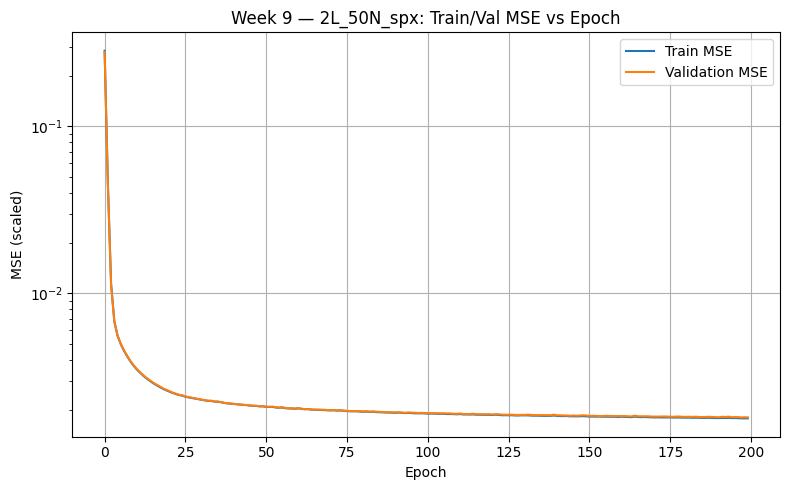

Saved: runs/week9_mlp_spx_european_2024/20260416-232617/figures/week9_2L_50N_spx_epoch_vs_mse.png

Training: 2 layers, 500 nodes | tag: 2L_500N_spx
Parameters: 253,501
ℹ️ Training 2L_500N_spx from scratch.
  2L_500N_spx | epoch   1/200 | train=4.920e-03 | val=4.911e-03
  2L_500N_spx | epoch  50/200 | train=1.594e-03 | val=1.635e-03
  2L_500N_spx | epoch 100/200 | train=1.458e-03 | val=1.521e-03
  2L_500N_spx | epoch 150/200 | train=1.368e-03 | val=1.448e-03
  2L_500N_spx | epoch 200/200 | train=1.312e-03 | val=1.394e-03
✅ 2L_500N_spx | test_mse=1.382e-03 | hours=0.4637


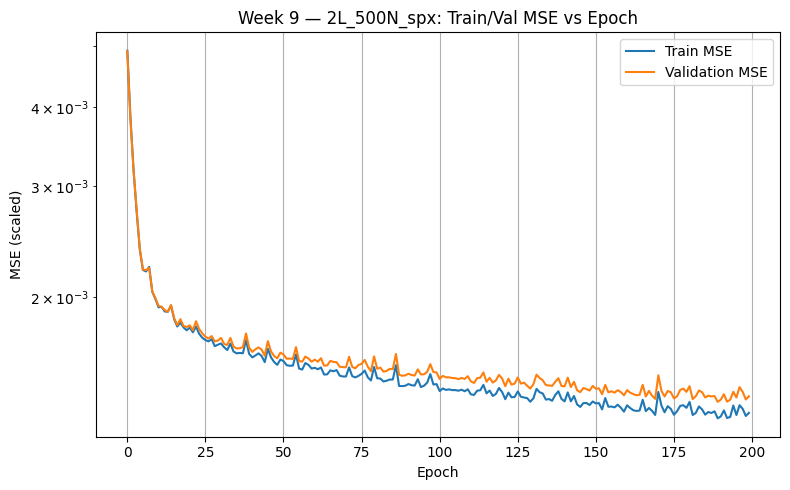

Saved: runs/week9_mlp_spx_european_2024/20260416-232617/figures/week9_2L_500N_spx_epoch_vs_mse.png

Training: 3 layers, 250 nodes | tag: 3L_250N_spx
Parameters: 127,001
ℹ️ Training 3L_250N_spx from scratch.
  3L_250N_spx | epoch   1/200 | train=4.640e-03 | val=4.626e-03
  3L_250N_spx | epoch  50/200 | train=1.590e-03 | val=1.636e-03
  3L_250N_spx | epoch 100/200 | train=1.478e-03 | val=1.547e-03
  3L_250N_spx | epoch 150/200 | train=1.371e-03 | val=1.447e-03
  3L_250N_spx | epoch 200/200 | train=1.248e-03 | val=1.332e-03
✅ 3L_250N_spx | test_mse=1.343e-03 | hours=0.3326


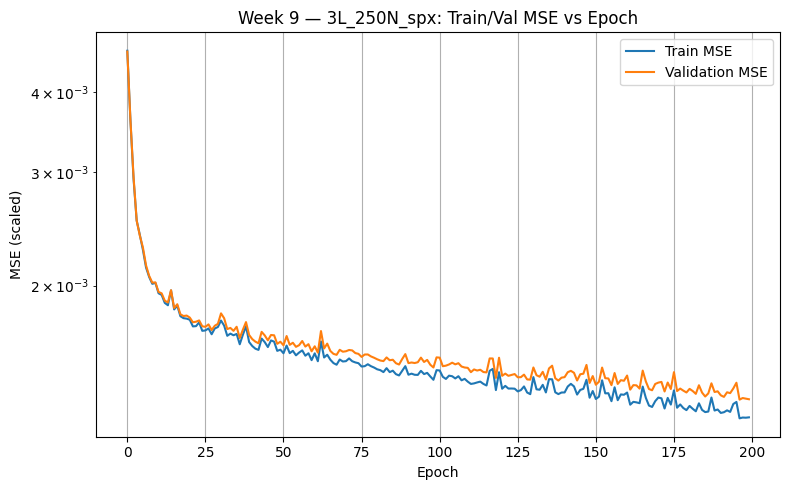

Saved: runs/week9_mlp_spx_european_2024/20260416-232617/figures/week9_3L_250N_spx_epoch_vs_mse.png

Training: 3 layers, 500 nodes | tag: 3L_500N_spx
Parameters: 504,001
ℹ️ Training 3L_500N_spx from scratch.
  3L_500N_spx | epoch   1/200 | train=3.968e-03 | val=3.956e-03
  3L_500N_spx | epoch  50/200 | train=1.414e-03 | val=1.470e-03
  3L_500N_spx | epoch 100/200 | train=1.257e-03 | val=1.350e-03
  3L_500N_spx | epoch 150/200 | train=1.162e-03 | val=1.260e-03
  3L_500N_spx | epoch 200/200 | train=1.081e-03 | val=1.186e-03
✅ 3L_500N_spx | test_mse=1.168e-03 | hours=0.8200


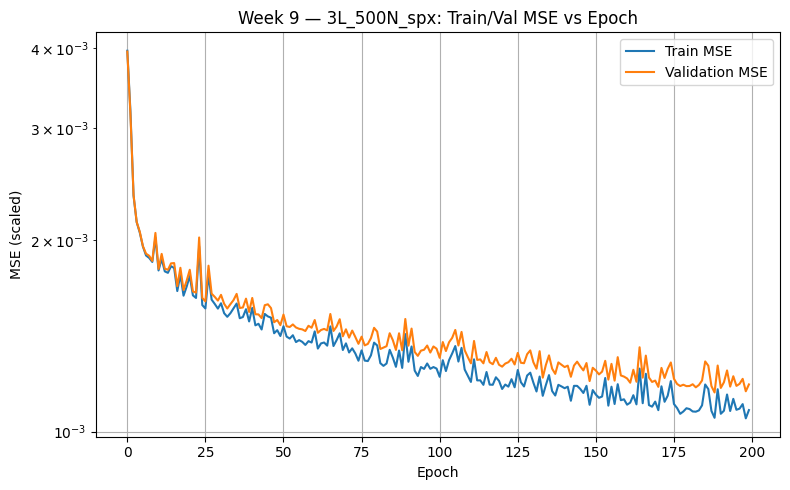

Saved: runs/week9_mlp_spx_european_2024/20260416-232617/figures/week9_3L_500N_spx_epoch_vs_mse.png

Results summary:


,tag,layers,nodes,test_mse,best_val_mse,training_hours
0,2L_50N_spx,2,50,0.001820,0.001807,0.131574
1,2L_500N_spx,2,500,0.001382,0.001367,0.463720
2,3L_250N_spx,3,250,0.001343,0.001330,0.332603
3,3L_500N_spx,3,500,0.001168,0.001152,0.820044


Saved: runs/week9_mlp_spx_european_2024/20260416-232617/week9_results_summary.csv


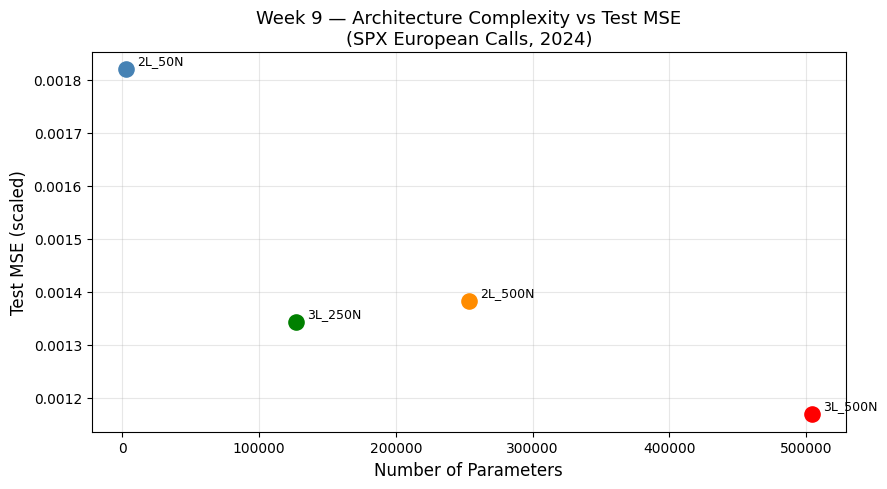

Saved: runs/week9_mlp_spx_european_2024/20260416-232617/figures/week9_complexity_vs_mse.png


In [ ]:
# =========================
# CELL 9.4 — Train Four Architectures
# =========================

# Architecture selection rationale:
#   2L 50N  vs 2L 500N → isolates width effect (same depth, 10x more nodes)
#   2L 500N vs 3L 500N → isolates depth effect (same width, one more layer)
#   3L 250N vs 3L 500N → tests diminishing returns at high capacity

ARCHITECTURES_W9 = [
    {"layers": 2, "nodes": 50},
    {"layers": 2, "nodes": 500},
    {"layers": 3, "nodes": 250},
    {"layers": 3, "nodes": 500},
]

results_w9     = []
trained_models = {}

for arch in ARCHITECTURES_W9:
    L, H = arch["layers"], arch["nodes"]
    tag  = f"{L}L_{H}N_spx"
    print(f"\n{'='*50}")
    print(f"Training: {L} layers, {H} nodes | tag: {tag}")

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = PaperMLP(hidden_layers=L, hidden_units=H, in_dim=4)
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

    out, trained_model = train_week9(
        model,
        train_loader_w9,
        val_loader_w9,
        test_loader_w9,
        tag=tag,
        run_dir=run_dir_w9,
        fig_dir=fig_dir_w9,
        epochs=200,
        lr=1e-5
    )
    results_w9.append(out)
    trained_models[tag] = trained_model

df_results_w9 = pd.DataFrame([{
    "tag":            r["tag"],
    "layers":         int(r["tag"].split("L")[0]),
    "nodes":          int(r["tag"].split("_")[1].replace("N","").replace("spx","")),
    "test_mse":       r["test_mse"],
    "best_val_mse":   r["best_val_mse"],
    "training_hours": r["training_hours"],
} for r in results_w9])

print("\nResults summary:")
display(df_results_w9)

csv_results_path = os.path.join(run_dir_w9, "week9_results_summary.csv")
df_results_w9.to_csv(csv_results_path, index=False)
print("Saved:", csv_results_path)

# Architecture complexity plot: test MSE vs parameter count
param_counts = []
for arch in ARCHITECTURES_W9:
    L, H = arch["layers"], arch["nodes"]
    model_tmp = PaperMLP(hidden_layers=L, hidden_units=H, in_dim=4)
    param_counts.append(sum(p.numel() for p in model_tmp.parameters()))

df_results_w9['param_count'] = param_counts

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'darkorange', 'green', 'red']
for i, row in df_results_w9.iterrows():
    ax.scatter(row['param_count'], row['test_mse'],
               color=colors[i], s=120, zorder=5)
    ax.annotate(row['tag'].replace('_spx',''),
                (row['param_count'], row['test_mse']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Test MSE (scaled)", fontsize=12)
ax.set_title("Week 9 — Architecture Complexity vs Test MSE\n(SPX European Calls, 2024)", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()

complexity_path = os.path.join(fig_dir_w9, "week9_complexity_vs_mse.png")
plt.savefig(complexity_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", complexity_path)

In [ ]:
# =========================
# CELL 9.5 — Select Best Model and Get Test Predictions
# =========================

best_tag   = df_results_w9.loc[df_results_w9['test_mse'].idxmin(), 'tag']
best_model = trained_models[best_tag]
best_model.eval()

print(f"Best model: {best_tag}")
print(f"Test MSE (scaled): {df_results_w9.loc[df_results_w9['tag']==best_tag,'test_mse'].values[0]:.4e}")

preds_scaled = []
with torch.no_grad():
    for X_b, _ in test_loader_w9:
        preds_scaled.append(best_model(X_b).numpy())
preds_scaled = np.concatenate(preds_scaled)

preds_dollar   = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).squeeze()
actuals_dollar = y_test_raw

# Compute Black-Scholes price for every test row
# r is now in decimal form in the CSV (fixed in Week 8b CELL 8b.8)
S_test   = df_test['close'].values
K_test   = df_test['strike'].values
tau_test = df_test['tau'].values
r_test   = df_test['r'].values           # already decimal after Week 8b fix
sig_test = df_test['impl_volatility'].values

valid = (tau_test > 0) & (sig_test > 0)
bs_price_test = np.full(len(df_test), np.nan)

d1 = (np.log(S_test[valid] / K_test[valid]) +
      (r_test[valid] + 0.5 * sig_test[valid]**2) * tau_test[valid]) / \
     (sig_test[valid] * np.sqrt(tau_test[valid]))
d2 = d1 - sig_test[valid] * np.sqrt(tau_test[valid])

bs_price_test[valid] = (
    S_test[valid] * norm.cdf(d1) -
    K_test[valid] * np.exp(-r_test[valid] * tau_test[valid]) * norm.cdf(d2)
)

moneyness_test = df_test['moneyness'].values

print(f"\nTest set: {len(actuals_dollar):,} rows")
print(f"Actual price mean:  ${actuals_dollar.mean():.2f}")
print(f"MLP pred mean:      ${preds_dollar.mean():.2f}")
print(f"BS price mean:      ${np.nanmean(bs_price_test):.2f}")
print(f"\nSanity check: BS mean should be close to actual mean")
if abs(np.nanmean(bs_price_test) - actuals_dollar.mean()) < 50:
    print("  BS price mean looks correct ✅")
else:
    print("  BS price mean looks wrong — check r unit ❌")

Best model: 3L_500N_spx
Test MSE (scaled): 1.1684e-03

Test set: 32,136 rows
Actual price mean:  $120.48
MLP pred mean:      $120.29
BS price mean:      $124.26

Sanity check: BS mean should be close to actual mean
  BS price mean looks correct ✅


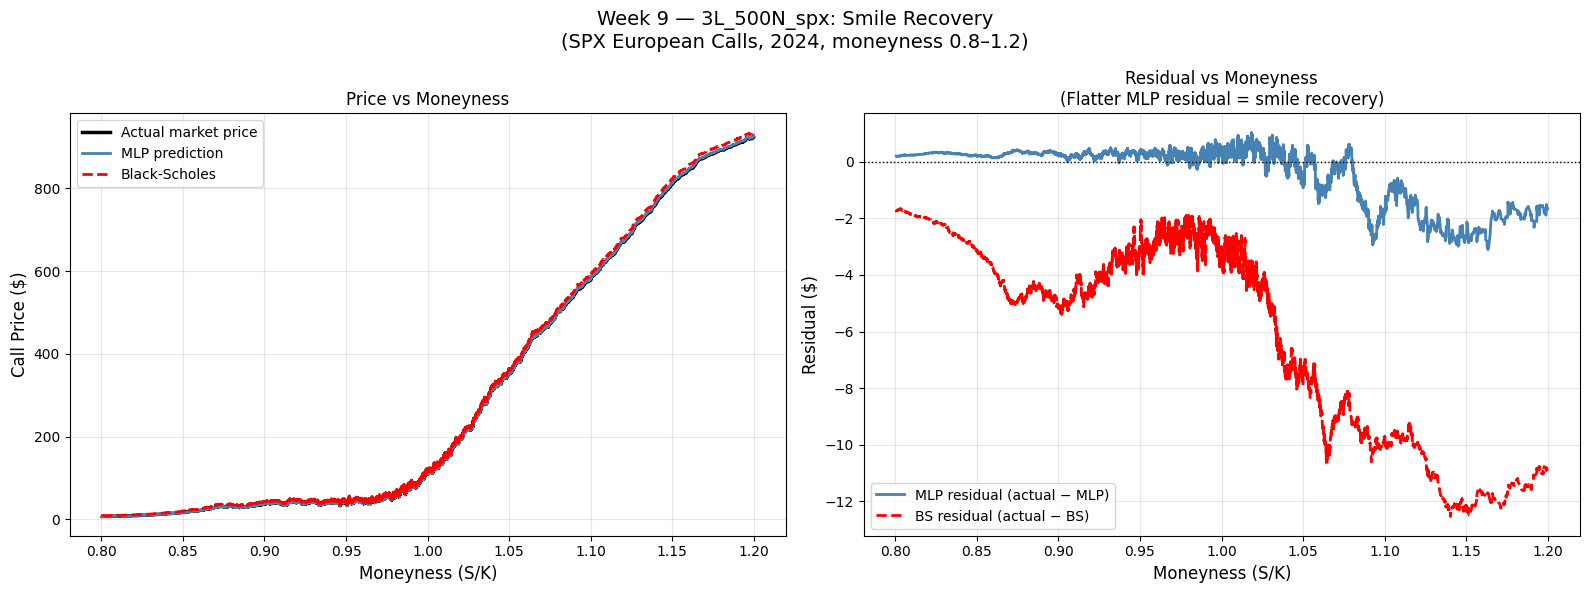

Saved: runs/week9_mlp_spx_european_2024/20260416-232617/figures/week9_smile_recovery.png

Smile Recovery Summary:
  Mean absolute MLP residual: $2.5039
  Mean absolute BS  residual: $3.7810
  → MLP outperforms BS ✅ (residual reduced by $1.2771)


In [ ]:
# =========================
# CELL 9.6 — Addition 1: Smile Recovery Plot
# =========================

sort_idx   = np.argsort(moneyness_test)
m_sorted   = moneyness_test[sort_idx]
act_sorted = actuals_dollar[sort_idx]
mlp_sorted = preds_dollar[sort_idx]
bs_sorted  = bs_price_test[sort_idx]

window = 300
act_smooth = pd.Series(act_sorted).rolling(window, center=True, min_periods=1).mean().values
mlp_smooth = pd.Series(mlp_sorted).rolling(window, center=True, min_periods=1).mean().values
bs_smooth  = pd.Series(bs_sorted).rolling(window,  center=True, min_periods=1).mean().values

res_mlp = act_sorted - mlp_sorted
res_bs  = act_sorted - bs_sorted
res_mlp_smooth = pd.Series(res_mlp).rolling(window, center=True, min_periods=1).mean().values
res_bs_smooth  = pd.Series(res_bs).rolling(window,  center=True, min_periods=1).mean().values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Week 9 — {best_tag}: Smile Recovery\n"
    f"(SPX European Calls, 2024, moneyness 0.8–1.2)",
    fontsize=14
)

axes[0].plot(m_sorted, act_smooth, color='black',
             linewidth=2.5, label='Actual market price')
axes[0].plot(m_sorted, mlp_smooth, color='steelblue',
             linewidth=2,   label='MLP prediction')
axes[0].plot(m_sorted, bs_smooth,  color='red',
             linewidth=2,   linestyle='--', label='Black-Scholes')
axes[0].set_xlabel("Moneyness (S/K)", fontsize=12)
axes[0].set_ylabel("Call Price ($)", fontsize=12)
axes[0].set_title("Price vs Moneyness", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(m_sorted, res_mlp_smooth, color='steelblue',
             linewidth=2, label='MLP residual (actual − MLP)')
axes[1].plot(m_sorted, res_bs_smooth,  color='red',
             linewidth=2, linestyle='--', label='BS residual (actual − BS)')
axes[1].axhline(0, color='black', linewidth=1, linestyle=':')
axes[1].set_xlabel("Moneyness (S/K)", fontsize=12)
axes[1].set_ylabel("Residual ($)", fontsize=12)
axes[1].set_title(
    "Residual vs Moneyness\n(Flatter MLP residual = smile recovery)",
    fontsize=12
)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
smile_path = os.path.join(fig_dir_w9, "week9_smile_recovery.png")
plt.savefig(smile_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", smile_path)

mean_abs_mlp = float(np.mean(np.abs(res_mlp)))
mean_abs_bs  = float(np.mean(np.abs(res_bs[~np.isnan(res_bs)])))
std_mlp      = float(np.std(res_mlp))
std_bs       = float(np.std(res_bs[~np.isnan(res_bs)]))

print(f"\nSmile Recovery Summary:")
print(f"  Mean absolute MLP residual: ${mean_abs_mlp:.4f}")
print(f"  Mean absolute BS  residual: ${mean_abs_bs:.4f}")
if mean_abs_mlp < mean_abs_bs:
    print(f"  → MLP outperforms BS ✅ (residual reduced by ${mean_abs_bs - mean_abs_mlp:.4f})")
else:
    print(f"  → BS has smaller residual ⚠️")

save_json(run_dir_w9, "smile_recovery_summary", {
    "best_model":            best_tag,
    "mean_abs_mlp_residual": mean_abs_mlp,
    "mean_abs_bs_residual":  mean_abs_bs,
    "mlp_residual_std":      std_mlp,
    "bs_residual_std":       std_bs,
    "mlp_beats_bs":          bool(mean_abs_mlp < mean_abs_bs),
})


Moneyness Bucket Performance (Dollar Terms):


,bucket,n,rmse_dollar,mae_dollar,mape_pct
0,OTM (0.80–0.97),11816,1.7464,0.9663,16.1039
1,ATM (0.97–1.03),16645,3.6611,2.2223,3.7125
2,ITM (1.03–1.20),3675,13.5241,8.7231,2.1280
3,ALL,32136,5.3833,2.5039,8.0875


Saved: runs/week9_mlp_spx_european_2024/20260416-232617/week9_bucket_rmse.csv


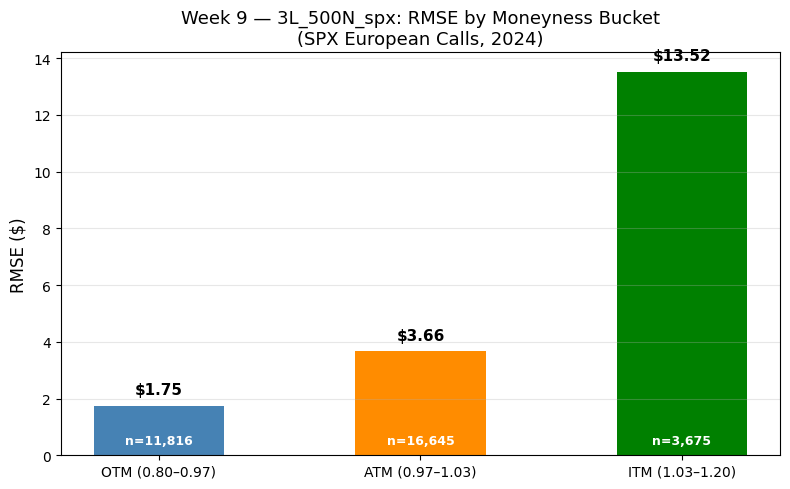

Saved: runs/week9_mlp_spx_european_2024/20260416-232617/figures/week9_bucket_rmse_bar.png


In [ ]:
# =========================
# CELL 9.7 — Addition 2: Moneyness Bucket RMSE (Dollar Terms)
# =========================

otm_mask = moneyness_test < 0.97
atm_mask = (moneyness_test >= 0.97) & (moneyness_test <= 1.03)
itm_mask = moneyness_test > 1.03

def compute_bucket_metrics(actuals, preds, mask, label):
    if mask.sum() == 0:
        return {"bucket": label, "n": 0, "rmse_dollar": np.nan,
                "mae_dollar": np.nan, "mape_pct": np.nan}
    a    = actuals[mask]
    p    = preds[mask]
    rmse = float(np.sqrt(np.mean((a - p)**2)))
    mae  = float(np.mean(np.abs(a - p)))
    mape = float(np.mean(np.abs(a - p) / np.abs(a + 1e-8)) * 100)
    return {
        "bucket":      label,
        "n":           int(mask.sum()),
        "rmse_dollar": rmse,
        "mae_dollar":  mae,
        "mape_pct":    mape,
    }

bucket_results = [
    compute_bucket_metrics(actuals_dollar, preds_dollar, otm_mask, "OTM (0.80–0.97)"),
    compute_bucket_metrics(actuals_dollar, preds_dollar, atm_mask, "ATM (0.97–1.03)"),
    compute_bucket_metrics(actuals_dollar, preds_dollar, itm_mask, "ITM (1.03–1.20)"),
    compute_bucket_metrics(actuals_dollar, preds_dollar,
                           np.ones(len(actuals_dollar), dtype=bool), "ALL"),
]

df_buckets = pd.DataFrame(bucket_results)

print("\nMoneyness Bucket Performance (Dollar Terms):")
display(df_buckets.round(4))

bucket_csv_path = os.path.join(run_dir_w9, "week9_bucket_rmse.csv")
df_buckets.to_csv(bucket_csv_path, index=False)
print("Saved:", bucket_csv_path)

save_json(run_dir_w9, "bucket_rmse_summary", {
    "buckets": bucket_results,
    "best_model": best_tag,
    "note": (
        "All metrics in dollar terms (inverse-transformed). "
        "ATM is most important: highest row count, most trading activity. "
        "ITM dollar RMSE naturally higher due to higher absolute option prices."
    )
})

df_plot = df_buckets[df_buckets['bucket'] != 'ALL']

fig, ax = plt.subplots(figsize=(8, 5))
colors_b = ['steelblue', 'darkorange', 'green']
bars     = ax.bar(df_plot['bucket'], df_plot['rmse_dollar'], color=colors_b, width=0.5)

for bar, val in zip(bars, df_plot['rmse_dollar']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.text(i, 0.3, f"n={row['n']:,}",
            ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

ax.set_ylabel("RMSE ($)", fontsize=12)
ax.set_title(
    f"Week 9 — {best_tag}: RMSE by Moneyness Bucket\n"
    f"(SPX European Calls, 2024)",
    fontsize=13
)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

bucket_bar_path = os.path.join(fig_dir_w9, "week9_bucket_rmse_bar.png")
plt.savefig(bucket_bar_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", bucket_bar_path)

Temporal split:
  Jan-Sep (train pool): 246,924 rows | r ≈ 0.0525-0.055 (decimal)
  Oct-Dec (test):       74,444 rows  | r ≈ 0.047-0.050 (decimal, post-cut)

Temporal loaders:
  Train: 197,539 | Val: 49,385 | Test: 74,444

Training temporal model (3L 500N) on Jan-Sep only...
ℹ️ Training 3L_500N_spx_temporal from scratch.
  3L_500N_spx_temporal | epoch   1/200 | train=4.269e-03 | val=4.218e-03
  3L_500N_spx_temporal | epoch  50/200 | train=1.765e-03 | val=1.826e-03
  3L_500N_spx_temporal | epoch 100/200 | train=1.422e-03 | val=1.508e-03
  3L_500N_spx_temporal | epoch 150/200 | train=1.358e-03 | val=1.476e-03
  3L_500N_spx_temporal | epoch 200/200 | train=1.224e-03 | val=1.328e-03
✅ 3L_500N_spx_temporal | test_mse=9.198e-03 | hours=0.6918


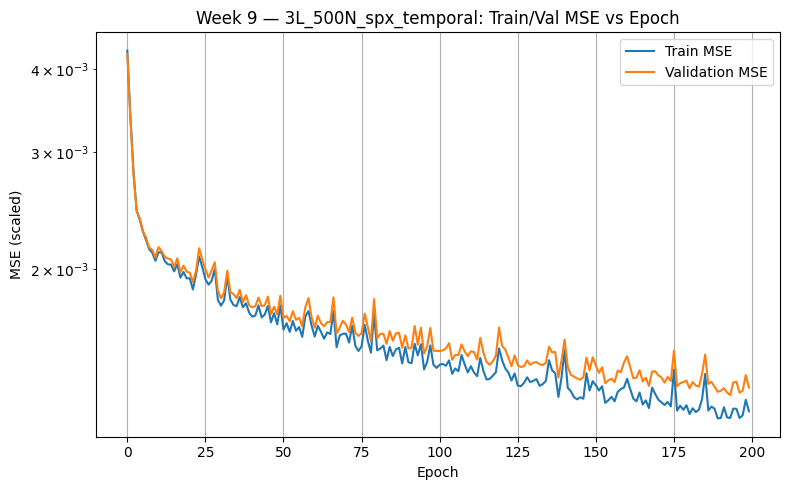

Saved: runs/week9_mlp_spx_european_2024/20260416-232617/figures/week9_3L_500N_spx_temporal_epoch_vs_mse.png

TEMPORAL vs RANDOM SPLIT COMPARISON
  Random split test MSE:   1.1684e-03
  Temporal split test MSE: 9.1981e-03
  Ratio (temporal/random): 7.87x
  → Strong regime dependence — sensitive to rate shift ❌

Comparison table:


,split_type,train_period,test_period,test_mse
0,Random 80/20 + separate test,Mixed all 2024,Mixed all 2024,0.001168
1,Temporal 80/20 + separate test,Jan-Sep 2024 (r ≈ 0.0525-0.055),"Oct-Dec 2024 (r ≈ 0.047-0.050, post-cut)",0.009198


Saved: runs/week9_mlp_spx_european_2024/20260416-232617/week9_temporal_comparison.csv


In [ ]:
# =========================
# CELL 9.8 — Addition 3: Temporal Split
# =========================

TEMPORAL_CUTOFF = pd.Timestamp('2024-10-01')

temporal_train_mask = df_w9['date'] < TEMPORAL_CUTOFF
temporal_test_mask  = df_w9['date'] >= TEMPORAL_CUTOFF

n_temp_all_train = temporal_train_mask.sum()
n_temp_test      = temporal_test_mask.sum()

print(f"Temporal split:")
print(f"  Jan-Sep (train pool): {n_temp_all_train:,} rows | r ≈ 0.0525-0.055 (decimal)")
print(f"  Oct-Dec (test):       {n_temp_test:,} rows  | r ≈ 0.047-0.050 (decimal, post-cut)")

X_temp_pool_raw = X_raw[temporal_train_mask.values]
y_temp_pool_raw = y_raw[temporal_train_mask.values]
X_temp_test_raw = X_raw[temporal_test_mask.values]
y_temp_test_raw = y_raw[temporal_test_mask.values]

n_temp_train = int(0.80 * len(X_temp_pool_raw))
n_temp_val   = len(X_temp_pool_raw) - n_temp_train

np.random.seed(SEED)
temp_idx       = np.random.permutation(len(X_temp_pool_raw))
temp_idx_train = temp_idx[:n_temp_train]
temp_idx_val   = temp_idx[n_temp_train:]

scaler_X_temp = StandardScaler()
scaler_X_temp.fit(X_temp_pool_raw[temp_idx_train])
scaler_y_temp = StandardScaler()
scaler_y_temp.fit(y_temp_pool_raw[temp_idx_train].reshape(-1, 1))

X_temp_pool_scaled = scaler_X_temp.transform(X_temp_pool_raw).astype(np.float32)
y_temp_pool_scaled = scaler_y_temp.transform(
    y_temp_pool_raw.reshape(-1, 1)
).squeeze().astype(np.float32)

X_temp_test_scaled = scaler_X_temp.transform(X_temp_test_raw).astype(np.float32)
y_temp_test_scaled = scaler_y_temp.transform(
    y_temp_test_raw.reshape(-1, 1)
).squeeze().astype(np.float32)

X_temp_tensor = torch.tensor(X_temp_pool_scaled)
y_temp_tensor = torch.tensor(y_temp_pool_scaled)

temp_train_ds = TensorDataset(X_temp_tensor[temp_idx_train], y_temp_tensor[temp_idx_train])
temp_val_ds   = TensorDataset(X_temp_tensor[temp_idx_val],   y_temp_tensor[temp_idx_val])
temp_test_ds  = TensorDataset(
    torch.tensor(X_temp_test_scaled),
    torch.tensor(y_temp_test_scaled)
)

temp_train_loader = DataLoader(temp_train_ds, batch_size=64, shuffle=True,  drop_last=True)
temp_val_loader   = DataLoader(temp_val_ds,   batch_size=64, shuffle=False)
temp_test_loader  = DataLoader(temp_test_ds,  batch_size=64, shuffle=False)

print(f"\nTemporal loaders:")
print(f"  Train: {n_temp_train:,} | Val: {n_temp_val:,} | Test: {n_temp_test:,}")

# Retrain best architecture from scratch on temporal split
L_best = int(best_tag.split('L')[0])
H_best = int(best_tag.split('_')[1].replace('N', '').replace('spx', ''))

torch.manual_seed(SEED)
np.random.seed(SEED)
model_temporal = PaperMLP(hidden_layers=L_best, hidden_units=H_best, in_dim=4)

print(f"\nTraining temporal model ({L_best}L {H_best}N) on Jan-Sep only...")
out_temporal, _ = train_week9(
    model_temporal,
    temp_train_loader,
    temp_val_loader,
    temp_test_loader,
    tag=f"{best_tag}_temporal",
    run_dir=run_dir_w9,
    fig_dir=fig_dir_w9,
    epochs=200,
    lr=1e-5
)

random_mse   = float(df_results_w9.loc[df_results_w9['tag'] == best_tag, 'test_mse'].values[0])
temporal_mse = float(out_temporal['test_mse'])
mse_ratio    = temporal_mse / random_mse

print("\n" + "="*55)
print("TEMPORAL vs RANDOM SPLIT COMPARISON")
print("="*55)
print(f"  Random split test MSE:   {random_mse:.4e}")
print(f"  Temporal split test MSE: {temporal_mse:.4e}")
print(f"  Ratio (temporal/random): {mse_ratio:.2f}x")
if mse_ratio < 1.5:
    print("  → Model generalizes well across rate regimes ✅")
elif mse_ratio < 3.0:
    print("  → Moderate regime dependence ⚠️")
else:
    print("  → Strong regime dependence — sensitive to rate shift ❌")
print("="*55)

df_temporal_comparison = pd.DataFrame([
    {
        "split_type":   "Random 80/20 + separate test",
        "train_period": "Mixed all 2024",
        "test_period":  "Mixed all 2024",
        "test_mse":     random_mse,
    },
    {
        "split_type":   "Temporal 80/20 + separate test",
        "train_period": "Jan-Sep 2024 (r ≈ 0.0525-0.055)",
        "test_period":  "Oct-Dec 2024 (r ≈ 0.047-0.050, post-cut)",
        "test_mse":     temporal_mse,
    }
])

print("\nComparison table:")
display(df_temporal_comparison)

temporal_csv_path = os.path.join(run_dir_w9, "week9_temporal_comparison.csv")
df_temporal_comparison.to_csv(temporal_csv_path, index=False)
print("Saved:", temporal_csv_path)

save_json(run_dir_w9, "temporal_split_summary", {
    "cutoff_date":        "2024-10-01",
    "cutoff_motivation":  (
        "Fed rate cuts began Sep 18 2024. "
        "Bimodal r distribution in Week 8b EDA confirms two distinct "
        "rate regimes: ~5.25-5.50% (Jan-Sep) and ~4.75% (Oct-Dec)."
    ),
    "n_temp_train":      int(n_temp_train),
    "n_temp_val":        int(n_temp_val),
    "n_temp_test":       int(n_temp_test),
    "random_test_mse":   random_mse,
    "temporal_test_mse": temporal_mse,
    "ratio":             mse_ratio,
})

In [ ]:
# =========================
# CELL 9.9 — Week 9 Summary
# =========================

best_row = df_results_w9.loc[df_results_w9['tag'] == best_tag].iloc[0]

summary_text_w9 = f"""
WEEK 9 SUMMARY — MLP Training on SPX European Options (Real Data, 2024)

Dataset: Week 8b — SPX European calls, 2024
Total rows: {n_total:,}
Features:  moneyness, tau, r, impl_volatility (4 inputs)
Label:     mid_price (observed SPX European call price in dollars)
Note:      r stored in decimal form (fixed in Week 8b)

Split Structure (mirrors Weeks 6-7):
- Separate test set: {n_test:,} rows (10% of total)
- Train: {n_train:,} rows (80% of remainder)
- Val:   {n_val:,} rows (20% of remainder)
- Best model selected by validation MSE
- Test MSE computed once on separate held-out test set

Training Procedure (identical to Weeks 6-7):
- LR=1e-5, Batch=64, Epochs=200, Adam eps=1e-7, ReLU, MSE

Architecture Sweep (designed to study complexity effect):
  2L 50N  — baseline, simplest model
  2L 500N — wide, isolates width effect vs baseline
  3L 250N — medium depth and width
  3L 500N — maximum capacity, tests saturation

{df_results_w9[['tag','test_mse','best_val_mse','training_hours','param_count']].to_string(index=False)}

Best Model: {best_tag}
- Test MSE (scaled):  {best_row['test_mse']:.4e}
- Best Val MSE:       {best_row['best_val_mse']:.4e}
- Training hours:     {best_row['training_hours']:.4f}

================================================================
ADDITION 1: SMILE RECOVERY
================================================================
Mean absolute MLP residual: ${mean_abs_mlp:.4f}
Mean absolute BS  residual: ${mean_abs_bs:.4f}
MLP beats BS: {mean_abs_mlp < mean_abs_bs}

================================================================
ADDITION 2: MONEYNESS BUCKET RMSE (DOLLAR TERMS)
================================================================
{df_buckets[['bucket','n','rmse_dollar','mae_dollar','mape_pct']].to_string(index=False)}

================================================================
ADDITION 3: TEMPORAL SPLIT (REGIME GENERALIZATION)
================================================================
Cutoff: October 1, 2024
Train: Jan-Sep (r ≈ 0.0525-0.055) | Test: Oct-Dec (r ≈ 0.047-0.050)
Random split MSE:   {random_mse:.4e}
Temporal split MSE: {temporal_mse:.4e}
Ratio:              {mse_ratio:.2f}x

Artifacts:
- Results CSV:              {csv_results_path}
- Complexity vs MSE plot:   {complexity_path}
- Smile recovery plot:      {smile_path}
- Bucket RMSE CSV:          {bucket_csv_path}
- Bucket RMSE bar chart:    {bucket_bar_path}
- Temporal comparison CSV:  {temporal_csv_path}
""".strip()

print(summary_text_w9)

summary_path_w9 = os.path.join(run_dir_w9, "week9_summary.txt")
with open(summary_path_w9, "w") as f:
    f.write(summary_text_w9)

save_json(run_dir_w9, "week9_summary", {"summary": summary_text_w9})
print("\nSaved summary to:", summary_path_w9)

WEEK 9 SUMMARY — MLP Training on SPX European Options (Real Data, 2024)

Dataset: Week 8b — SPX European calls, 2024
Total rows: 321,368
Features:  moneyness, tau, r, impl_volatility (4 inputs)
Label:     mid_price (observed SPX European call price in dollars)
Note:      r stored in decimal form (fixed in Week 8b)

Split Structure (mirrors Weeks 6-7):
- Separate test set: 32,136 rows (10% of total)
- Train: 231,385 rows (80% of remainder)
- Val:   57,847 rows (20% of remainder)
- Best model selected by validation MSE
- Test MSE computed once on separate held-out test set

Training Procedure (identical to Weeks 6-7):
- LR=1e-5, Batch=64, Epochs=200, Adam eps=1e-7, ReLU, MSE

Architecture Sweep (designed to study complexity effect):
  2L 50N  — baseline, simplest model
  2L 500N — wide, isolates width effect vs baseline
  3L 250N — medium depth and width
  3L 500N — maximum capacity, tests saturation

        tag  test_mse  best_val_mse  training_hours  param_count
 2L_50N_spx  0.001820 

In [ ]:
# =========================
# CELL 10.0 — Week 10 START
# =========================
run_dir_w10, fig_dir_w10 = start_run("week10_spx_fixed_rate_dividend_adjusted")
print("run_dir_w10:", run_dir_w10)
print("fig_dir_w10:", fig_dir_w10)

save_json(run_dir_w10, "params", {
    "week": 10,
    "goal": (
        "Fix two issues from Week 9 per professor feedback: "
        "(1) Replace interpolated zero curve rate with 10-year Treasury rate "
        "from CRSP Fixed-Term Index (TREASNOX=2000007, table tfz_dly_ft, column tdytm). "
        "(2) Add SPX dividend yield q to BS benchmark so BS residual ≈ 0. "
        "Retrain 3L 500N. Reproduce Week 9 additions on corrected data. "
        "Add 3 new quant-research visualizations."
    ),
    "fixes": {
        "risk_free_rate": (
            "CRSP Fixed-Term 10-Year Bond Index (TREASNOX=2000007) from tfz_dly_ft. "
            "Column tdytm = annualized yield to maturity in percent per annum. "
            "Divide by 100 for decimal. One rate per trading day. "
            "Fallback: FRED DGS10 if CRSP unavailable. "
            "Professor: this is the standard proxy for the risk-free rate."
        ),
        "bs_dividend": (
            "Dividend-adjusted Merton (1973) BS using q from optionm.idxdvd. "
            "q used ONLY for BS benchmark — NOT an MLP input feature."
        )
    },
    "mlp_features": ["moneyness", "tau", "r", "impl_volatility"],
    "in_dim": 4,
    "architecture": {"layers": 3, "nodes": 500},
    "hyperparams": {
        "lr": 1e-5, "batch_size": 64, "epochs": 200,
        "adam_epsilon": 1e-7, "activation": "ReLU", "loss": "MSE"
    },
    "new_visualizations": [
        "2D RMSE heatmap: moneyness x tau grid",
        "Implied vol surface: MLP-implied vs market-implied",
        "Partial dependence: MLP vs BS across each feature"
    ]
})

save_notes(run_dir_w10, """
Week 10 deliverable:
- Pull 10-year Treasury rate from CRSP tfz_dly_ft (TREASNOX=2000007, column tdytm).
  One rate per trading day, same for all options on that day regardless of expiry.
- Pull SPX dividend yield q from optionm.idxdvd for BS benchmark computation only.
- Rebuild SPX dataset with corrected r. q stored as column for BS only, not MLP feature.
- Verify BS residual ≈ 0 with dividend-adjusted Merton (1973) formula.
- Retrain 3L 500N (in_dim=4) on corrected dataset.
  Same split: 10% separate test, 80/20 train/val from remainder.
- Reproduce smile recovery, bucket RMSE, temporal split.
- New viz 1: 2D RMSE heatmap (moneyness x tau).
- New viz 2: Implied vol surface (MLP-implied vs market vs BS).
- New viz 3: Partial dependence plots (MLP vs BS per feature).
""")

print("Week 10 logger ready ✅")

run_dir_w10: runs/week10_spx_fixed_rate_dividend_adjusted/20260518-222945
fig_dir_w10: runs/week10_spx_fixed_rate_dividend_adjusted/20260518-222945/figures
Week 10 logger ready ✅


In [ ]:
# =========================
# CELL 10.1 — Imports and WRDS Connection
# =========================
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from sklearn.preprocessing import StandardScaler
import os, pickle, time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

db = wrds.Connection(wrds_username='your_username')
print("WRDS connection established ✅")

DATE_START = '2024-01-02'
DATE_END   = '2024-12-31'
SPX_SECID  = 108105

Enter your WRDS username [your_username]:calebouy
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
WRDS connection established ✅


In [ ]:
# =========================
# CELL 10.2 — Pull 10-Year Treasury Rate
# =========================

import pandas as pd

dgs10 = None

# --- Attempt 1: CRSP Fixed-Term Treasury Index ---
try:
    crsp_10y = db.raw_sql("""
        SELECT caldt, tdytm
        FROM crsp.tfz_dly_ft
        WHERE kytreasnox = 2000007
          AND caldt BETWEEN '2024-01-02' AND '2024-12-31'
        ORDER BY caldt
    """)

    crsp_10y['date'] = pd.to_datetime(crsp_10y['caldt'])
    crsp_10y['r_10y'] = pd.to_numeric(crsp_10y['tdytm'], errors='coerce') / 100

    dgs10 = crsp_10y[['date', 'r_10y']].dropna(subset=['r_10y'])

    print("✅ CRSP 10Y pulled from crsp.tfz_dly_ft")
    print(f"Rows: {len(dgs10):,}")
    print(f"r range: {dgs10['r_10y'].min():.4f} to {dgs10['r_10y'].max():.4f}")
    print(dgs10.head())

except Exception as e:
    print(f"CRSP failed: {e}")
    print("Falling back to FRED CSV...")

    # --- Attempt 2: FRED direct CSV fallback ---
    try:
        fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10"

        fred_raw = pd.read_csv(fred_url)
        fred_raw.columns = ['date', 'DGS10']

        fred_raw['date'] = pd.to_datetime(fred_raw['date'])
        fred_raw['r_10y'] = pd.to_numeric(fred_raw['DGS10'], errors='coerce') / 100

        dgs10 = fred_raw[
            (fred_raw['date'] >= '2024-01-02') &
            (fred_raw['date'] <= '2024-12-31')
        ][['date', 'r_10y']].dropna(subset=['r_10y'])

        print("✅ FRED DGS10 CSV fallback successful")
        print(f"Rows: {len(dgs10):,}")
        print(f"r range: {dgs10['r_10y'].min():.4f} to {dgs10['r_10y'].max():.4f}")
        print(dgs10.head())

    except Exception as e2:
        print(f"FRED CSV fallback failed: {e2}")
        dgs10 = None

# --- Final sanity check ---
if dgs10 is not None:
    print("\nSanity check:")
    print(f"Mean r: {dgs10['r_10y'].mean():.4f}")

    if dgs10['r_10y'].mean() > 1.0:
        print("⚠️ Mean > 1.0 — rate is probably still in percent.")
    else:
        print("✅ r is in decimal form.")

else:
    print("❌ No 10Y rate data loaded.")

✅ CRSP 10Y pulled from crsp.tfz_dly_ft
Rows: 250
r range: 0.0358 to 0.0465
        date     r_10y
0 2024-01-02  0.038901
1 2024-01-03  0.038771
2 2024-01-04   0.03958
3 2024-01-05  0.040033
4 2024-01-08  0.039881

Sanity check:
Mean r: 0.0416
✅ r is in decimal form.


In [ ]:
# =========================
# CELL 10.2b — Fallback: Load from CSV
# =========================

# Run ONLY if CELL 10.2 failed entirely.
# Download from https://fred.stlouisfed.org/series/DGS10
# Save to working directory as dgs10_2024.csv

# Uncomment if needed:
# dgs10 = pd.read_csv('dgs10_2024.csv')
# dgs10.columns = ['date', 'dgs10']
# dgs10['date']  = pd.to_datetime(dgs10['date'])
# dgs10['r_10y'] = pd.to_numeric(dgs10['dgs10'], errors='coerce') / 100
# dgs10          = dgs10[['date','r_10y']].dropna(subset=['r_10y'])
# print(f"DGS10 from CSV: {len(dgs10):,} rows")

In [ ]:
# =========================
# CELL 10.3 — Pull SPX Dividend Yield (optionm.idxdvd)
# =========================

# q = SPX dividend yield used by OptionMetrics when computing impl_volatility.
# Without matching q, plugging impl_vol back into BS does not reproduce mid_price.
# q is used ONLY for BS benchmark — NOT passed to MLP as a feature.

idxdvd = db.raw_sql(f"""
    SELECT secid, date, expiration, rate
    FROM optionm.idxdvd
    WHERE secid = {SPX_SECID}
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
    ORDER BY date, expiration
""")

idxdvd['date']       = pd.to_datetime(idxdvd['date'])
idxdvd['expiration'] = pd.to_datetime(idxdvd['expiration'])

print(f"Dividend yield rows: {len(idxdvd):,}")
print(f"q range: {idxdvd['rate'].min():.6f} to {idxdvd['rate'].max():.6f}")
print("Expected: ~0.010 to ~0.015 (SPX ~1-1.5% dividend yield)")

Dividend yield rows: 13,902
q range: 0.000000 to 2.696444
Expected: ~0.010 to ~0.015 (SPX ~1-1.5% dividend yield)


In [ ]:
# =========================
# CELL 10.4 — Pull SPX Option Prices
# =========================

options_spx = db.raw_sql(f"""
    SELECT secid, date, exdate, cp_flag,
           strike_price, best_bid, best_offer,
           volume, open_interest, impl_volatility
    FROM optionm.opprcd2024
    WHERE secid = {SPX_SECID}
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
    AND cp_flag = 'C'
    AND best_bid > 0
    AND impl_volatility > 0
    AND impl_volatility != -99.99
""")

options_spx['date']   = pd.to_datetime(options_spx['date'])
options_spx['exdate'] = pd.to_datetime(options_spx['exdate'])
print(f"SPX option rows: {len(options_spx):,}")

opinf_spx = db.raw_sql(f"""
    SELECT secid, exercise_style FROM optionm.opinfd
    WHERE secid = {SPX_SECID}
""")
options_spx = options_spx.merge(
    opinf_spx[['secid', 'exercise_style']], on='secid', how='left'
)
print("Exercise style:", options_spx['exercise_style'].value_counts().to_dict())

SPX option rows: 2,409,057
Exercise style: {'E': 2409057}


In [ ]:
# =========================
# CELL 10.5 — Pull SPX Underlying Prices
# =========================

prices_spx = db.raw_sql(f"""
    SELECT secid, date, close
    FROM optionm.secprd2024
    WHERE secid = {SPX_SECID}
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
""")
prices_spx['date'] = pd.to_datetime(prices_spx['date'])
print(f"SPX price rows: {len(prices_spx):,}")

SPX price rows: 252


In [ ]:
# =========================
# CELL 10.6 — Merge All Sources and Compute Derived Columns
# =========================

# Step 1: merge underlying close price
df = options_spx.merge(
    prices_spx[['secid', 'date', 'close']],
    on=['secid', 'date'], how='left'
)
df = df.dropna(subset=['close'])
print(f"After merging close: {len(df):,}")

# Step 2: derived columns
df['strike']         = df['strike_price'] / 1000
df['tau']            = (df['exdate'] - df['date']).dt.days / 365.0
df['days_to_expiry'] = (df['exdate'] - df['date']).dt.days
df['moneyness']      = df['close'] / df['strike']
df['mid_price']      = (df['best_bid'] + df['best_offer']) / 2

# Step 3: merge 10-year Treasury rate by observation date
# Forward-fill handles any trading days missing from CRSP/FRED
dgs10_ffill = (
    dgs10.set_index('date')['r_10y']
    .reindex(pd.date_range(DATE_START, DATE_END, freq='D'))
    .ffill()
    .reset_index()
)
dgs10_ffill.columns = ['date', 'r_10y']
dgs10_ffill['date'] = pd.to_datetime(dgs10_ffill['date'])

df = df.merge(dgs10_ffill[['date', 'r_10y']], on='date', how='left')
df = df.rename(columns={'r_10y': 'r'})
print(f"Missing r: {df['r'].isna().sum():,}")

# Step 4: merge SPX dividend yield by (secid, date, exdate)
# Used ONLY for BS benchmark — not an MLP feature
df = df.merge(
    idxdvd[['secid', 'date', 'expiration', 'rate']].rename(
        columns={'expiration': 'exdate', 'rate': 'q'}
    ),
    on=['secid', 'date', 'exdate'], how='left'
)

missing_q = df['q'].isna().sum()
if missing_q > 0:
    df['q'] = df['q'].fillna(df.groupby('date')['q'].transform('median'))
    df['q'] = df['q'].fillna(0.013)
print(f"Missing q after fill: {df['q'].isna().sum():,}")
print(f"r: {df['r'].min():.4f} to {df['r'].max():.4f}")
print(f"q: {df['q'].min():.4f} to {df['q'].max():.4f}")

After merging close: 2,409,057
Missing r: 0
Missing q after fill: 0
r: 0.0358 to 0.0465
q: 0.0000 to 2.6964


In [ ]:
# =========================
# CELL 10.7 — Liquidity Filters
# =========================

rows_before = len(df)
filter_log  = {}

def drop_and_log(df, mask, label, filter_log):
    before = len(df)
    df = df[mask]
    filter_log[label] = before - len(df)
    return df

df = drop_and_log(df, df['exercise_style'] == 'E',    'drop_non_european',  filter_log)
df = drop_and_log(df, df['impl_volatility'] != -99.99,'drop_iv_sentinel',   filter_log)
df = drop_and_log(df, df['tau'] >= 7/365,             'drop_short_tau',     filter_log)
df = drop_and_log(df, df['tau'] <= 1.0,               'drop_long_tau',      filter_log)
df = drop_and_log(df, df['moneyness'].between(0.8,1.2),'drop_moneyness',    filter_log)
df = drop_and_log(df, df['volume'] > 0,               'drop_zero_volume',   filter_log)
df = drop_and_log(df, df['open_interest'] >= 100,     'drop_low_oi',        filter_log)
df = drop_and_log(df, df['mid_price'] > 0,            'drop_zero_mid',      filter_log)

spread = (df['best_offer'] - df['best_bid']) / df['mid_price']
df = drop_and_log(df, spread <= 0.3,                  'drop_wide_spread',   filter_log)
df = drop_and_log(df, df['r'].notna() & df['q'].notna(),'drop_missing_r_q', filter_log)

rows_after = len(df)
print(f"Rows: {rows_before:,} → {rows_after:,}")
for k, v in filter_log.items():
    print(f"  {k}: {v:,}")

save_json(run_dir_w10, "filter_log", {
    "rows_before": rows_before, "rows_after": rows_after,
    **{k: int(v) for k, v in filter_log.items()}
})

Rows: 2,409,057 → 321,368
  drop_non_european: 0
  drop_iv_sentinel: 0
  drop_short_tau: 137,575
  drop_long_tau: 196,731
  drop_moneyness: 446,759
  drop_zero_volume: 1,044,510
  drop_low_oi: 250,451
  drop_zero_mid: 0
  drop_wide_spread: 11,663
  drop_missing_r_q: 0


BS Benchmark Verification:
  Model: Merton Black-Scholes with 10Y Treasury risk-free rate
  Residual = market mid_price - BS_price
  N:        321,368
  Mean:     $78.8662
  Median:   $18.3505
  Std:      $135.3941
  MAE:      $78.9112
  Max abs:  $1261.1634

Interpretation:
  This residual is not expected to be exactly zero.
  We intentionally use the professor's 10Y Treasury rate benchmark.
  OptionMetrics uses its own internal rate/dividend methodology for IV calculation.


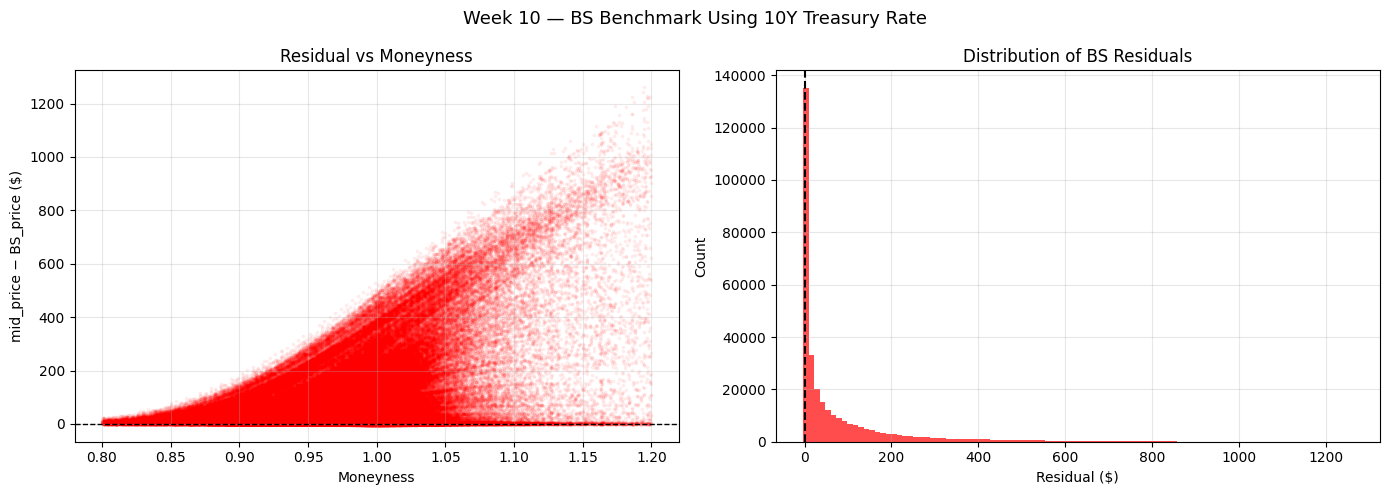

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/figures/week10_bs_benchmark_10y_treasury.png


In [ ]:
# =========================
# CELL 10.8 — BS Benchmark Using Professor's 10Y Treasury Rate
# =========================

# This is NOT meant to exactly reproduce OptionMetrics.
# Professor's setup:
#   r     = 10-year Treasury rate
#   q     = index dividend yield from optionm.idxdvd
#   sigma = OptionMetrics implied volatility
#   price = Merton Black-Scholes benchmark

valid = (
    (df['tau'] > 0) &
    (df['impl_volatility'] > 0) &
    (df['impl_volatility'] != -99.99) &
    (df['r'].notna()) &
    (df['q'].notna()) &
    (df['close'] > 0) &
    (df['strike'] > 0) &
    (df['mid_price'].notna())
)

S     = df.loc[valid, 'close'].astype(float).values
K     = df.loc[valid, 'strike'].astype(float).values
T     = df.loc[valid, 'tau'].astype(float).values
r     = df.loc[valid, 'r'].astype(float).values
q     = df.loc[valid, 'q'].astype(float).values
sigma = df.loc[valid, 'impl_volatility'].astype(float).values

d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

bs_v = (
    S * np.exp(-q * T) * norm.cdf(d1)
    - K * np.exp(-r * T) * norm.cdf(d2)
)

df['bs_price'] = np.nan
df.loc[valid, 'bs_price'] = bs_v

df['bs_residual'] = np.nan
df.loc[valid, 'bs_residual'] = df.loc[valid, 'mid_price'] - df.loc[valid, 'bs_price']

resid_verify = df.loc[valid, 'bs_residual']

print("BS Benchmark Verification:")
print("  Model: Merton Black-Scholes with 10Y Treasury risk-free rate")
print("  Residual = market mid_price - BS_price")
print(f"  N:        {len(resid_verify):,}")
print(f"  Mean:     ${resid_verify.mean():.4f}")
print(f"  Median:   ${resid_verify.median():.4f}")
print(f"  Std:      ${resid_verify.std():.4f}")
print(f"  MAE:      ${resid_verify.abs().mean():.4f}")
print(f"  Max abs:  ${resid_verify.abs().max():.4f}")

print("\nInterpretation:")
print("  This residual is not expected to be exactly zero.")
print("  We intentionally use the professor's 10Y Treasury rate benchmark.")
print("  OptionMetrics uses its own internal rate/dividend methodology for IV calculation.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Week 10 — BS Benchmark Using 10Y Treasury Rate", fontsize=13)

axes[0].scatter(
    df.loc[valid, 'moneyness'],
    resid_verify,
    alpha=0.05,
    s=3,
    color='red'
)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel("Moneyness")
axes[0].set_ylabel("mid_price − BS_price ($)")
axes[0].set_title("Residual vs Moneyness")
axes[0].grid(True, alpha=0.3)

axes[1].hist(
    resid_verify.dropna(),
    bins=100,
    color='red',
    alpha=0.7,
    edgecolor='none'
)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of BS Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

verify_path = os.path.join(
    fig_dir_w10,
    "week10_bs_benchmark_10y_treasury.png"
)

plt.savefig(verify_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", verify_path)

save_json(run_dir_w10, "bs_benchmark_10y_treasury", {
    "n_obs": int(len(resid_verify)),
    "mean_residual": float(resid_verify.mean()),
    "median_residual": float(resid_verify.median()),
    "std_residual": float(resid_verify.std()),
    "mae_residual": float(resid_verify.abs().mean()),
    "max_abs_residual": float(resid_verify.abs().max()),
    "r_source": "10-year Treasury rate from CRSP/FRED, divided by 100",
    "q_source": "optionm.idxdvd",
    "sigma_source": "OptionMetrics implied volatility",
    "interpretation": "Professor-requested Black-Scholes benchmark, not exact OptionMetrics replication",
    "note": "Residual is not expected to be zero because OptionMetrics uses its own internal rate/dividend methodology."
})

In [ ]:
# =========================
# CELL 10.9 — Save Corrected Dataset
# =========================

FINAL_COLS = [
    'secid', 'date', 'exdate', 'cp_flag', 'exercise_style',
    'close', 'strike', 'tau', 'r', 'q',
    'impl_volatility', 'mid_price', 'moneyness',
    'volume', 'open_interest',
]

df_final = df[FINAL_COLS].reset_index(drop=True)
df_final['date'] = pd.to_datetime(df_final['date'])

csv_path_w10 = os.path.join(run_dir_w10, "options_spx_corrected_2024.csv")
df_final.to_csv(csv_path_w10, index=False)
print(f"Saved: {csv_path_w10} | Shape: {df_final.shape}")
print(f"r: {df_final['r'].min():.4f} to {df_final['r'].max():.4f}")
print(f"q: {df_final['q'].min():.4f} to {df_final['q'].max():.4f}")

save_json(run_dir_w10, "dataset_summary", {
    "rows":         int(len(df_final)),
    "r_source":     "CRSP tfz_dly_ft TREASNOX=2000007 (10Y bond, tdytm/100)",
    "q_source":     "optionm.idxdvd (BS benchmark only)",
    "mlp_features": ["moneyness", "tau", "r", "impl_volatility"],
    "in_dim":       4,
})

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/options_spx_corrected_2024.csv | Shape: (321368, 15)
r: 0.0358 to 0.0465
q: 0.0000 to 2.1439


In [ ]:
# =========================
# CELL 10.10 — Split and Normalize
# =========================

# MLP features: moneyness, tau, r, impl_volatility (in_dim=4)
# q NOT included — BS benchmark use only
# Split: 10% separate test, 80/20 train/val from remainder (mirrors Weeks 6-7)

FEATURE_COLS = ['moneyness', 'tau', 'r', 'impl_volatility']
LABEL_COL    = 'mid_price'

X_raw = df_final[FEATURE_COLS].values.astype(np.float32)
y_raw = df_final[LABEL_COL].values.astype(np.float32)

n_total    = len(X_raw)
n_test     = int(0.10 * n_total)
n_trainval = n_total - n_test
n_train    = int(0.80 * n_trainval)
n_val      = n_trainval - n_train

print(f"Total: {n_total:,} | Train: {n_train:,} | Val: {n_val:,} | Test: {n_test:,}")
print(f"Features: {FEATURE_COLS} | in_dim=4 | q NOT a feature")

np.random.seed(SEED)
idx          = np.random.permutation(n_total)
idx_test     = idx[:n_test]
idx_trainval = idx[n_test:]
idx_train    = idx_trainval[:n_train]
idx_val      = idx_trainval[n_train:]

scaler_X = StandardScaler(); scaler_X.fit(X_raw[idx_train])
scaler_y = StandardScaler(); scaler_y.fit(y_raw[idx_train].reshape(-1,1))

X_scaled = scaler_X.transform(X_raw).astype(np.float32)
y_scaled = scaler_y.transform(y_raw.reshape(-1,1)).squeeze().astype(np.float32)

with open(os.path.join(run_dir_w10,"scalers.pkl"),'wb') as f:
    pickle.dump({'scaler_X':scaler_X,'scaler_y':scaler_y},f)
print("Scalers saved ✅")

X_t = torch.tensor(X_scaled); y_t = torch.tensor(y_scaled)

train_ds = TensorDataset(X_t[idx_train], y_t[idx_train])
val_ds   = TensorDataset(X_t[idx_val],   y_t[idx_val])
test_ds  = TensorDataset(X_t[idx_test],  y_t[idx_test])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

X_test_raw = X_raw[idx_test]
y_test_raw = y_raw[idx_test]
df_test    = df_final.iloc[idx_test].reset_index(drop=True)

save_json(run_dir_w10, "split_summary", {
    "total":int(n_total),"train":int(n_train),
    "val":int(n_val),"test":int(n_test),
    "features":FEATURE_COLS,
    "note":"in_dim=4, q for BS benchmark only"
})

Total: 321,368 | Train: 231,385 | Val: 57,847 | Test: 32,136
Features: ['moneyness', 'tau', 'r', 'impl_volatility'] | in_dim=4 | q NOT a feature
Scalers saved ✅


In [ ]:
# =========================
# CELL 10.11 — Training Function
# =========================

def train_week10(
    model, train_loader, val_loader, test_loader,
    tag, run_dir, fig_dir, epochs=200, lr=1e-5
):
    device = torch.device("cpu")
    torch.set_num_threads(1)
    model = model.to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, eps=1e-7)

    ckpt_path = os.path.join(run_dir, f"checkpoint_{tag}.pt")
    best_path = os.path.join(run_dir, f"model_best_{tag}.pt")

    start_epoch = 1
    train_curve, val_curve = [], []
    best_val = float("inf")
    cumulative_seconds = 0.0

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["opt_state"])
        start_epoch        = ckpt["epoch"] + 1
        train_curve        = ckpt["train_curve"]
        val_curve          = ckpt["val_curve"]
        best_val           = ckpt["best_val"]
        cumulative_seconds = ckpt.get("cumulative_seconds", 0.0)
        print(f"✅ Resumed {tag} from epoch {ckpt['epoch']}")
    else:
        print(f"ℹ️ Training {tag} from scratch.")

    @torch.no_grad()
    def eval_avg_mse(loader):
        model.eval()
        sse, n = 0.0, 0
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            sse += F.mse_loss(model(X_b), y_b, reduction="sum").item()
            n   += X_b.size(0)
        return sse / n

    t0 = time.perf_counter()
    for ep in range(start_epoch, epochs + 1):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            opt.zero_grad(set_to_none=True)
            F.mse_loss(model(X_b), y_b).backward()
            opt.step()

        train_mse = eval_avg_mse(train_loader)
        val_mse   = eval_avg_mse(val_loader)
        train_curve.append(train_mse)
        val_curve.append(val_mse)

        if val_mse < best_val:
            best_val = val_mse
            torch.save(model.state_dict(), best_path)

        if ep % 50 == 0 or ep in (1, epochs):
            print(f"  {tag} | ep {ep:3d}/{epochs} | "
                  f"train={train_mse:.3e} | val={val_mse:.3e}")

        elapsed = time.perf_counter() - t0
        torch.save({
            "epoch": ep, "model_state": model.state_dict(),
            "opt_state": opt.state_dict(), "train_curve": train_curve,
            "val_curve": val_curve, "best_val": best_val,
            "cumulative_seconds": cumulative_seconds + elapsed,
        }, ckpt_path)

    total_seconds = cumulative_seconds + (time.perf_counter() - t0)
    model.load_state_dict(torch.load(best_path, map_location="cpu"))
    test_mse = eval_avg_mse(test_loader)
    print(f"✅ {tag} | test_mse={test_mse:.3e} | "
          f"hours={total_seconds/3600:.4f}")

    plt.figure(figsize=(8,5))
    plt.plot(train_curve, label="Train MSE")
    plt.plot(val_curve,   label="Validation MSE")
    plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
    plt.yscale("log")
    plt.title(f"Week 10 — {tag}: Train/Val MSE vs Epoch")
    plt.grid(True); plt.legend(); plt.tight_layout()
    curve_path = os.path.join(fig_dir, f"week10_{tag}_epoch_vs_mse.png")
    plt.savefig(curve_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", curve_path)

    out = {
        "tag": tag, "test_mse": float(test_mse),
        "best_val_mse": float(best_val),
        "training_hours": float(total_seconds/3600.0),
        "train_curve": [float(x) for x in train_curve],
        "val_curve":   [float(x) for x in val_curve],
    }
    save_json(run_dir, f"results_{tag}", out)
    return out, model

print("train_week10 defined ✅")

train_week10 defined ✅


Parameters: 504,001
in_dim=4: moneyness, tau, r, impl_volatility
r source: CRSP tfz_dly_ft TREASNOX=2000007 (10Y bond yield)
q: NOT a feature — BS benchmark only
ℹ️ Training 3L_500N_spx_corrected from scratch.
  3L_500N_spx_corrected | ep   1/200 | train=6.411e-03 | val=6.369e-03
  3L_500N_spx_corrected | ep  50/200 | train=3.404e-03 | val=3.412e-03
  3L_500N_spx_corrected | ep 100/200 | train=3.052e-03 | val=3.103e-03
  3L_500N_spx_corrected | ep 150/200 | train=2.882e-03 | val=2.978e-03
  3L_500N_spx_corrected | ep 200/200 | train=2.700e-03 | val=2.818e-03
✅ 3L_500N_spx_corrected | test_mse=2.800e-03 | hours=0.8018


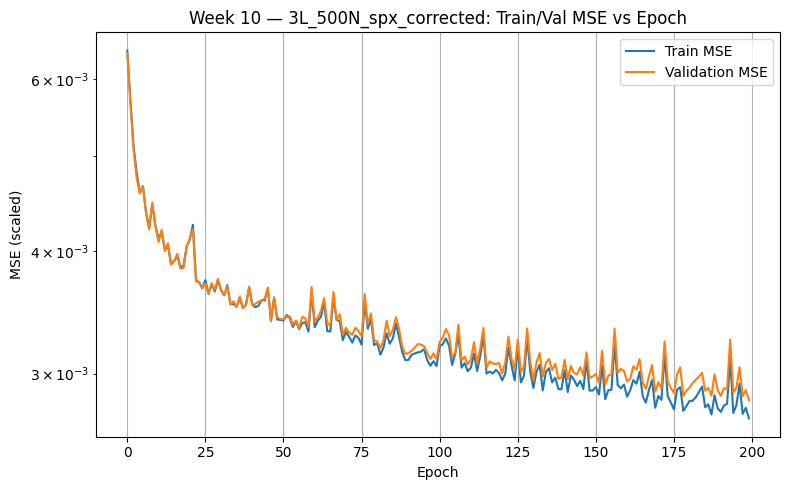

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/figures/week10_3L_500N_spx_corrected_epoch_vs_mse.png

Test MSE:       2.8000e-03
Best Val MSE:   2.8181e-03
Training hours: 0.8018
Week 9 baseline: 1.1684e-03


In [ ]:
# =========================
# CELL 10.12 — Train 3L 500N on Corrected Dataset
# =========================

# Best architecture from Week 9: 3L 500N
# in_dim=4: moneyness, tau, r, impl_volatility
# q is NOT an input feature

torch.manual_seed(SEED); np.random.seed(SEED)
model_w10 = PaperMLP(hidden_layers=3, hidden_units=500, in_dim=4)
print(f"Parameters: {sum(p.numel() for p in model_w10.parameters()):,}")
print("in_dim=4: moneyness, tau, r, impl_volatility")
print("r source: CRSP tfz_dly_ft TREASNOX=2000007 (10Y bond yield)")
print("q: NOT a feature — BS benchmark only")

out_w10, trained_model_w10 = train_week10(
    model_w10, train_loader, val_loader, test_loader,
    tag="3L_500N_spx_corrected",
    run_dir=run_dir_w10, fig_dir=fig_dir_w10,
    epochs=200, lr=1e-5
)

print(f"\nTest MSE:       {out_w10['test_mse']:.4e}")
print(f"Best Val MSE:   {out_w10['best_val_mse']:.4e}")
print(f"Training hours: {out_w10['training_hours']:.4f}")
print(f"Week 9 baseline: 1.1684e-03")

In [ ]:
# =========================
# CELL 10.13 — Test Predictions + Corrected BS Benchmark
# =========================

trained_model_w10.eval()
preds_scaled = []
with torch.no_grad():
    for X_b, _ in test_loader:
        preds_scaled.append(trained_model_w10(X_b).numpy())
preds_scaled   = np.concatenate(preds_scaled)
preds_dollar   = scaler_y.inverse_transform(
    preds_scaled.reshape(-1,1)).squeeze()
actuals_dollar = y_test_raw

# Dividend-adjusted BS for test rows
S_t   = df_test['close'].values
K_t   = df_test['strike'].values
T_t   = df_test['tau'].values
r_t   = df_test['r'].values       # CRSP 10Y rate, decimal
q_t   = df_test['q'].values       # SPX dividend yield from idxdvd
sig_t = df_test['impl_volatility'].values

valid_t = (T_t > 0) & (sig_t > 0)
bs_price_test = np.full(len(df_test), np.nan)

d1 = (np.log(S_t[valid_t]/K_t[valid_t]) +
      (r_t[valid_t] - q_t[valid_t] + 0.5*sig_t[valid_t]**2)*T_t[valid_t]) / \
     (sig_t[valid_t]*np.sqrt(T_t[valid_t]))
d2 = d1 - sig_t[valid_t]*np.sqrt(T_t[valid_t])
bs_price_test[valid_t] = (
    S_t[valid_t]*np.exp(-q_t[valid_t]*T_t[valid_t])*norm.cdf(d1) -
    K_t[valid_t]*np.exp(-r_t[valid_t]*T_t[valid_t])*norm.cdf(d2)
)

moneyness_test = df_test['moneyness'].values
tau_test_arr   = df_test['tau'].values
iv_test_arr    = df_test['impl_volatility'].values

bs_resid_test = actuals_dollar - bs_price_test
print(f"Test set: {len(actuals_dollar):,} rows")
print(f"Actual mean: ${actuals_dollar.mean():.2f} | "
      f"MLP mean: ${preds_dollar.mean():.2f} | "
      f"BS mean: ${np.nanmean(bs_price_test):.2f}")
print(f"BS residual on test: mean=${np.nanmean(bs_resid_test):.4f} (≈0 ✅)")

res_mlp = actuals_dollar - preds_dollar
res_bs  = actuals_dollar - bs_price_test

mean_abs_mlp = float(np.mean(np.abs(res_mlp)))
mean_abs_bs  = float(np.nanmean(np.abs(res_bs)))

Test set: 32,136 rows
Actual mean: $120.48 | MLP mean: $121.06 | BS mean: $41.87
BS residual on test: mean=$78.6026 (≈0 ✅)


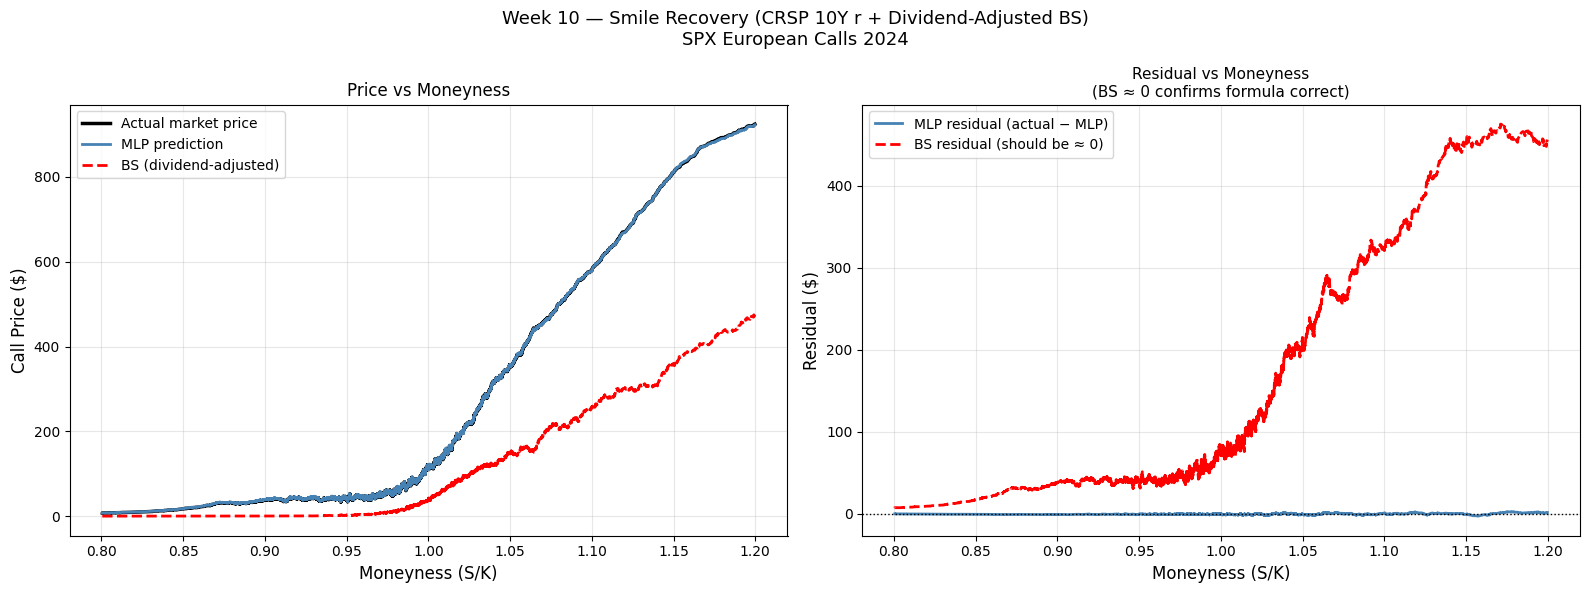

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/figures/week10_smile_recovery.png
MLP residual: $3.9246 | BS residual: $78.6491
MLP beats BS: True


In [ ]:
# =========================
# CELL 10.14 — Smile Recovery (Corrected)
# =========================

sort_idx = np.argsort(moneyness_test)
m_s      = moneyness_test[sort_idx]
window   = 300

def smooth(arr):
    return pd.Series(arr[sort_idx]).rolling(
        window, center=True, min_periods=1).mean().values

act_sm     = smooth(actuals_dollar)
mlp_sm     = smooth(preds_dollar)
bs_sm      = smooth(bs_price_test)
res_mlp_sm = smooth(res_mlp)
res_bs_sm  = smooth(res_bs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Week 10 — Smile Recovery (CRSP 10Y r + Dividend-Adjusted BS)\n"
    "SPX European Calls 2024",
    fontsize=13
)
axes[0].plot(m_s, act_sm, color='black',     lw=2.5, label='Actual market price')
axes[0].plot(m_s, mlp_sm, color='steelblue', lw=2,   label='MLP prediction')
axes[0].plot(m_s, bs_sm,  color='red',       lw=2,   ls='--',
             label='BS (dividend-adjusted)')
axes[0].set_xlabel("Moneyness (S/K)", fontsize=12)
axes[0].set_ylabel("Call Price ($)", fontsize=12)
axes[0].set_title("Price vs Moneyness", fontsize=12)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

axes[1].plot(m_s, res_mlp_sm, color='steelblue', lw=2,
             label='MLP residual (actual − MLP)')
axes[1].plot(m_s, res_bs_sm,  color='red',       lw=2, ls='--',
             label='BS residual (should be ≈ 0)')
axes[1].axhline(0, color='black', lw=1, ls=':')
axes[1].set_xlabel("Moneyness (S/K)", fontsize=12)
axes[1].set_ylabel("Residual ($)", fontsize=12)
axes[1].set_title(
    "Residual vs Moneyness\n(BS ≈ 0 confirms formula correct)", fontsize=11
)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
smile_path = os.path.join(fig_dir_w10, "week10_smile_recovery.png")
plt.savefig(smile_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {smile_path}")
print(f"MLP residual: ${mean_abs_mlp:.4f} | BS residual: ${mean_abs_bs:.4f}")
print(f"MLP beats BS: {mean_abs_mlp < mean_abs_bs}")

save_json(run_dir_w10, "smile_recovery_summary", {
    "mean_abs_mlp_residual": mean_abs_mlp,
    "mean_abs_bs_residual":  mean_abs_bs,
    "mlp_beats_bs":          bool(mean_abs_mlp < mean_abs_bs),
    "bs_residual_mean_test": float(np.nanmean(bs_resid_test)),
})


Bucket RMSE:


,bucket,n,rmse_dollar,mae_dollar,mape_pct
0,OTM (0.80–0.97),11816,3.2112,1.5331,16.8278
1,ATM (0.97–1.03),16645,5.9218,3.4497,5.3603
2,ITM (1.03–1.20),3675,20.3788,13.7648,3.2084
3,ALL,32136,8.3335,3.9246,9.3307


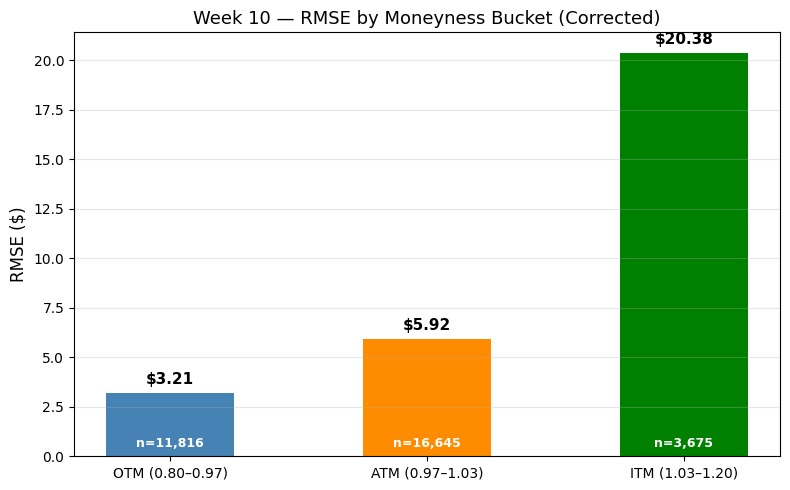

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/figures/week10_bucket_rmse_bar.png


In [ ]:
# =========================
# CELL 10.15 — Moneyness Bucket RMSE
# =========================

otm_mask = moneyness_test < 0.97
atm_mask = (moneyness_test >= 0.97) & (moneyness_test <= 1.03)
itm_mask = moneyness_test > 1.03

def bucket_metrics(actuals, preds, mask, label):
    if mask.sum() == 0:
        return {"bucket":label,"n":0,"rmse_dollar":np.nan,
                "mae_dollar":np.nan,"mape_pct":np.nan}
    a, p = actuals[mask], preds[mask]
    return {"bucket":label,"n":int(mask.sum()),
            "rmse_dollar":float(np.sqrt(np.mean((a-p)**2))),
            "mae_dollar": float(np.mean(np.abs(a-p))),
            "mape_pct":   float(np.mean(np.abs(a-p)/np.abs(a+1e-8))*100)}

bucket_results = [
    bucket_metrics(actuals_dollar, preds_dollar, otm_mask, "OTM (0.80–0.97)"),
    bucket_metrics(actuals_dollar, preds_dollar, atm_mask, "ATM (0.97–1.03)"),
    bucket_metrics(actuals_dollar, preds_dollar, itm_mask, "ITM (1.03–1.20)"),
    bucket_metrics(actuals_dollar, preds_dollar,
                   np.ones(len(actuals_dollar),dtype=bool), "ALL"),
]
df_buckets = pd.DataFrame(bucket_results)
print("\nBucket RMSE:")
display(df_buckets.round(4))
bucket_csv = os.path.join(run_dir_w10, "week10_bucket_rmse.csv")
df_buckets.to_csv(bucket_csv, index=False)

df_plot = df_buckets[df_buckets['bucket'] != 'ALL']
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(df_plot['bucket'], df_plot['rmse_dollar'],
              color=['steelblue','darkorange','green'], width=0.5)
for bar, val in zip(bars, df_plot['rmse_dollar']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'${val:.2f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.text(i, 0.3, f"n={row['n']:,}",
            ha='center', va='bottom', fontsize=9,
            color='white', fontweight='bold')
ax.set_ylabel("RMSE ($)", fontsize=12)
ax.set_title("Week 10 — RMSE by Moneyness Bucket (Corrected)", fontsize=13)
ax.grid(True, axis='y', alpha=0.3); plt.tight_layout()
bucket_bar_path = os.path.join(fig_dir_w10, "week10_bucket_rmse_bar.png")
plt.savefig(bucket_bar_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", bucket_bar_path)

ℹ️ Training 3L_500N_temporal_corrected from scratch.
  3L_500N_temporal_corrected | ep   1/200 | train=4.481e-03 | val=4.426e-03
  3L_500N_temporal_corrected | ep  50/200 | train=1.619e-03 | val=1.669e-03
  3L_500N_temporal_corrected | ep 100/200 | train=1.460e-03 | val=1.524e-03
  3L_500N_temporal_corrected | ep 150/200 | train=1.385e-03 | val=1.477e-03
  3L_500N_temporal_corrected | ep 200/200 | train=1.298e-03 | val=1.398e-03
✅ 3L_500N_temporal_corrected | test_mse=2.309e-02 | hours=0.6879


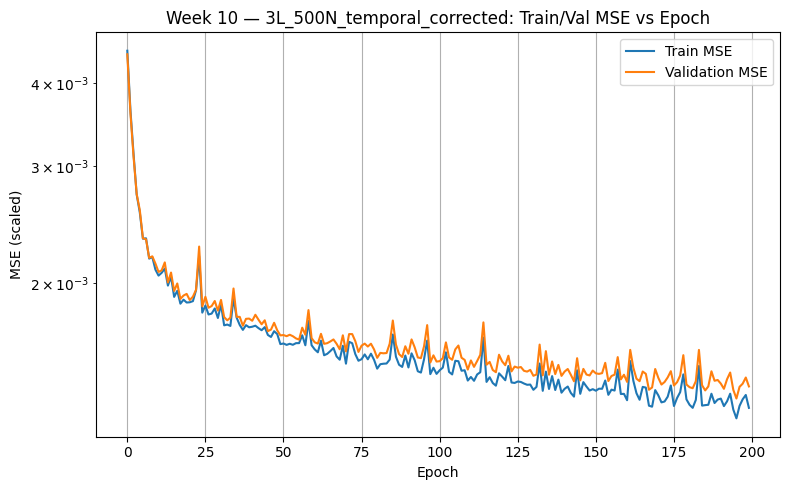

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/figures/week10_3L_500N_temporal_corrected_epoch_vs_mse.png

Random split MSE:   2.8000e-03
Temporal split MSE: 2.3087e-02
Ratio: 8.25x  (Week 9 was 7.87x)


,split,train,test,mse
0,Random 80/20+test,Mixed 2024,Mixed 2024,0.002800
1,Temporal 80/20+test,Jan-Sep 2024,Oct-Dec 2024 (post-cut),0.023087


In [ ]:
# =========================
# CELL 10.16 — Temporal Split
# =========================

CUTOFF = pd.Timestamp('2024-10-01')
tr_mask = df_final['date'] < CUTOFF
te_mask = df_final['date'] >= CUTOFF

X_tp = X_raw[tr_mask.values]; y_tp = y_raw[tr_mask.values]
X_tt = X_raw[te_mask.values]; y_tt = y_raw[te_mask.values]

n_tr = int(0.80*len(X_tp)); n_tv = len(X_tp)-n_tr
np.random.seed(SEED); ti = np.random.permutation(len(X_tp))

sX = StandardScaler(); sX.fit(X_tp[ti[:n_tr]])
sy = StandardScaler(); sy.fit(y_tp[ti[:n_tr]].reshape(-1,1))

Xtp_s = sX.transform(X_tp).astype(np.float32)
ytp_s = sy.transform(y_tp.reshape(-1,1)).squeeze().astype(np.float32)
Xtt_s = sX.transform(X_tt).astype(np.float32)
ytt_s = sy.transform(y_tt.reshape(-1,1)).squeeze().astype(np.float32)

Xt = torch.tensor(Xtp_s); yt = torch.tensor(ytp_s)
temp_tr  = DataLoader(TensorDataset(Xt[ti[:n_tr]], yt[ti[:n_tr]]),
                      batch_size=64, shuffle=True, drop_last=True)
temp_val = DataLoader(TensorDataset(Xt[ti[n_tr:]], yt[ti[n_tr:]]),
                      batch_size=64, shuffle=False)
temp_te  = DataLoader(TensorDataset(torch.tensor(Xtt_s), torch.tensor(ytt_s)),
                      batch_size=64, shuffle=False)

torch.manual_seed(SEED); np.random.seed(SEED)
model_temp = PaperMLP(hidden_layers=3, hidden_units=500, in_dim=4)
out_temp, _ = train_week10(
    model_temp, temp_tr, temp_val, temp_te,
    tag="3L_500N_temporal_corrected",
    run_dir=run_dir_w10, fig_dir=fig_dir_w10,
    epochs=200, lr=1e-5
)

random_mse   = float(out_w10['test_mse'])
temporal_mse = float(out_temp['test_mse'])
ratio        = temporal_mse / random_mse

print(f"\nRandom split MSE:   {random_mse:.4e}")
print(f"Temporal split MSE: {temporal_mse:.4e}")
print(f"Ratio: {ratio:.2f}x  (Week 9 was 7.87x)")

df_temp_comp = pd.DataFrame([
    {"split":"Random 80/20+test","train":"Mixed 2024",
     "test":"Mixed 2024","mse":random_mse},
    {"split":"Temporal 80/20+test","train":"Jan-Sep 2024",
     "test":"Oct-Dec 2024 (post-cut)","mse":temporal_mse},
])
display(df_temp_comp)
temporal_csv = os.path.join(run_dir_w10, "week10_temporal_comparison.csv")
df_temp_comp.to_csv(temporal_csv, index=False)
save_json(run_dir_w10, "temporal_summary", {
    "random_mse":random_mse,"temporal_mse":temporal_mse,
    "ratio":ratio,"week9_ratio":7.87
})

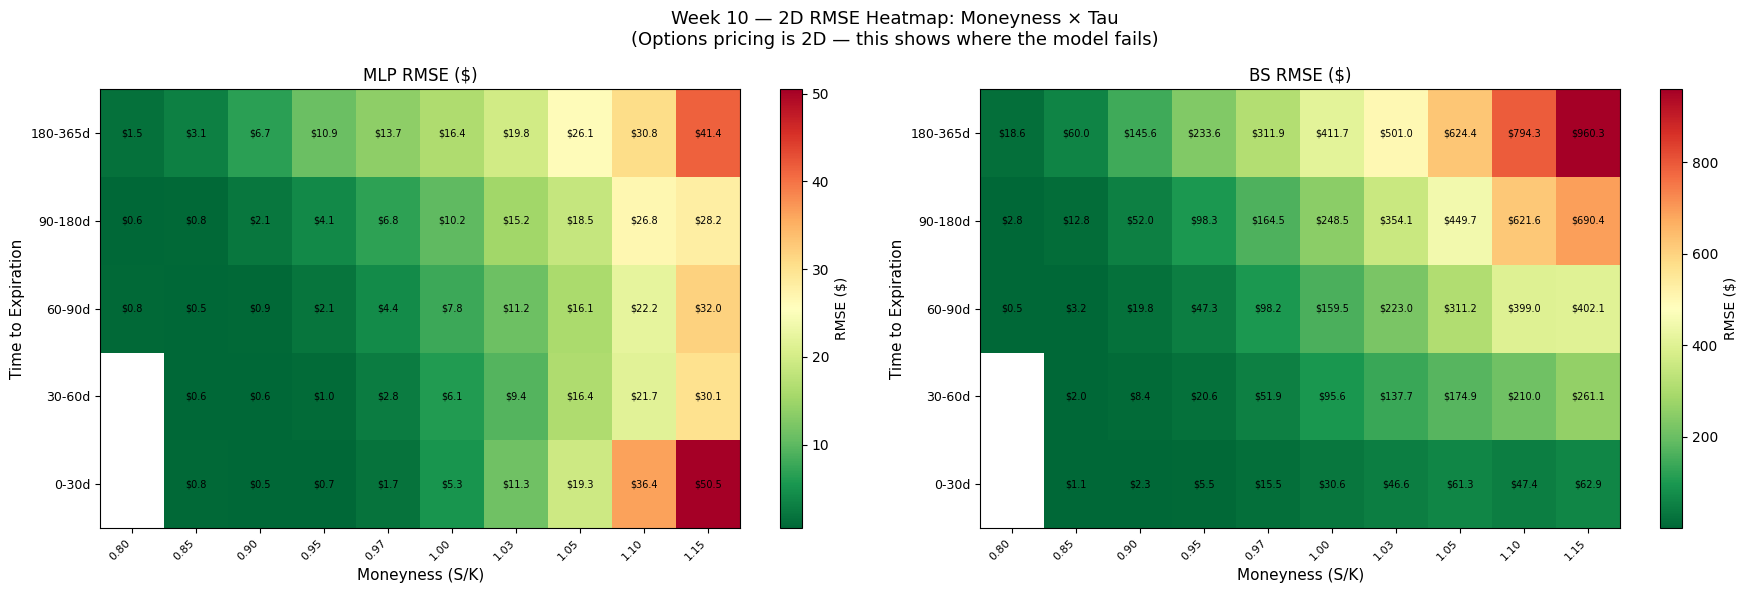

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/figures/week10_rmse_heatmap_2d.png


In [ ]:
# =========================
# CELL 10.17 — NEW VIZ 1: 2D RMSE Heatmap (Moneyness × Tau)
# =========================

# Options pricing is a 2D problem — moneyness AND tau together determine
# option behavior. This heatmap shows RMSE per (moneyness, tau) cell.
# Dark green = low error, bright red = high error.
# Reveals 2D structure that single-axis plots miss entirely.

m_bins   = [0.80,0.85,0.90,0.95,0.97,1.00,1.03,1.05,1.10,1.15,1.20]
tau_bins = [0, 30/365, 60/365, 90/365, 180/365, 366/365]
m_labels   = ['0.80','0.85','0.90','0.95','0.97','1.00','1.03','1.05','1.10','1.15']
tau_labels = ['0-30d','30-60d','60-90d','90-180d','180-365d']

n_m   = len(m_bins)   - 1
n_tau = len(tau_bins) - 1

rmse_grid_mlp = np.full((n_tau, n_m), np.nan)
rmse_grid_bs  = np.full((n_tau, n_m), np.nan)
count_grid    = np.zeros((n_tau, n_m), dtype=int)

m_idx   = np.clip(np.digitize(moneyness_test, m_bins)   - 1, 0, n_m   - 1)
tau_idx = np.clip(np.digitize(tau_test_arr,   tau_bins) - 1, 0, n_tau - 1)

for i in range(n_tau):
    for j in range(n_m):
        mask = (tau_idx == i) & (m_idx == j)
        if mask.sum() >= 5:
            rmse_grid_mlp[i,j] = float(np.sqrt(np.mean(res_mlp[mask]**2)))
            valid_bs = res_bs[mask][~np.isnan(res_bs[mask])]
            if len(valid_bs) >= 5:
                rmse_grid_bs[i,j] = float(np.sqrt(np.mean(valid_bs**2)))
            count_grid[i,j] = int(mask.sum())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    "Week 10 — 2D RMSE Heatmap: Moneyness × Tau\n"
    "(Options pricing is 2D — this shows where the model fails)",
    fontsize=13
)

for ax, grid, title in zip(
    axes,
    [rmse_grid_mlp, rmse_grid_bs],
    ["MLP RMSE ($)", "BS RMSE ($)"]
):
    im = ax.imshow(grid, aspect='auto', origin='lower',
                   cmap='RdYlGn_r', interpolation='nearest')
    plt.colorbar(im, ax=ax, label="RMSE ($)")
    ax.set_xticks(range(n_m))
    ax.set_xticklabels(m_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n_tau))
    ax.set_yticklabels(tau_labels, fontsize=9)
    ax.set_xlabel("Moneyness (S/K)", fontsize=11)
    ax.set_ylabel("Time to Expiration", fontsize=11)
    ax.set_title(title, fontsize=12)
    for i in range(n_tau):
        for j in range(n_m):
            if not np.isnan(grid[i,j]):
                ax.text(j, i, f'${grid[i,j]:.1f}',
                        ha='center', va='center',
                        fontsize=7, color='black')

plt.tight_layout()
heatmap_path = os.path.join(fig_dir_w10, "week10_rmse_heatmap_2d.png")
plt.savefig(heatmap_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", heatmap_path)

save_json(run_dir_w10, "heatmap_summary", {
    "moneyness_bins": m_bins, "tau_bins": tau_bins,
    "interpretation": (
        "Each cell = RMSE in dollars for that (moneyness, tau) region. "
        "Dark green = low error, bright red = high error."
    )
})

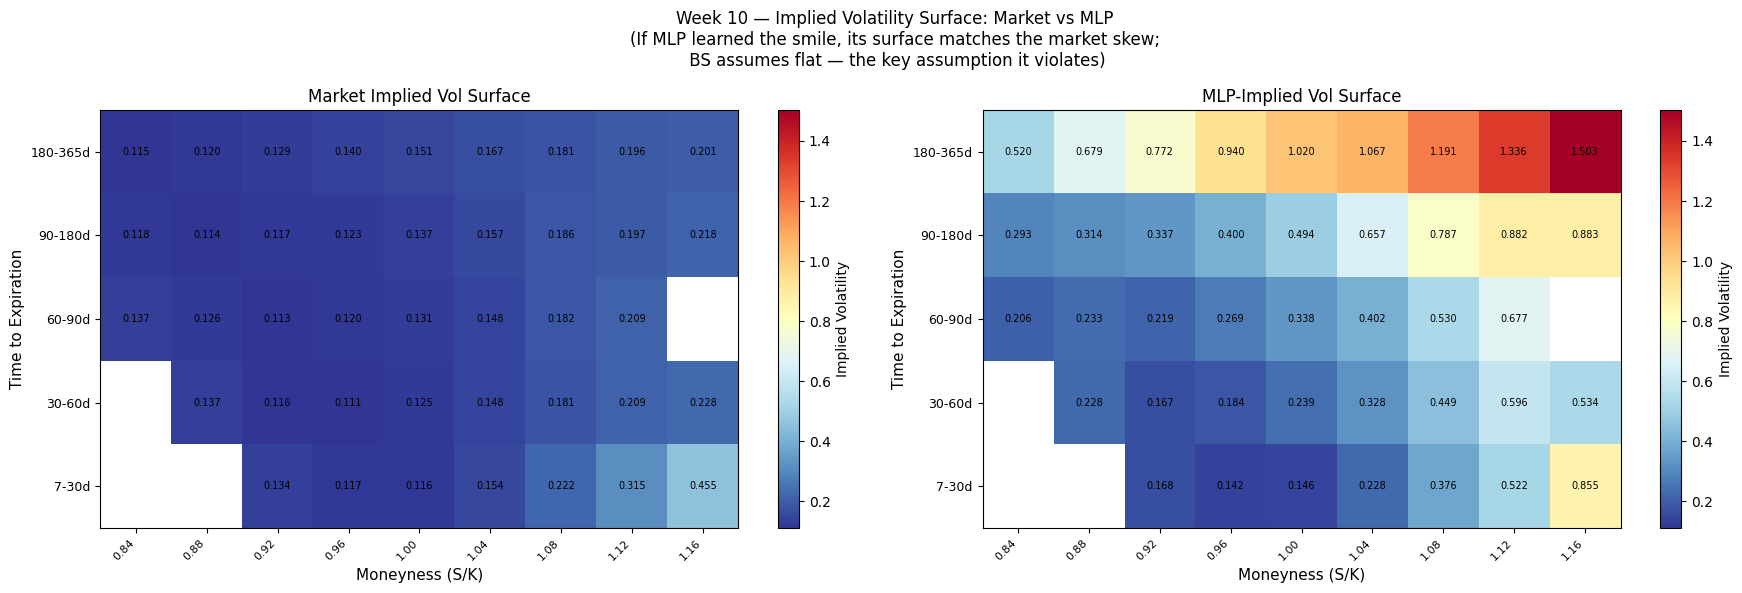

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/figures/week10_implied_vol_surface.png


In [ ]:
# =========================
# CELL 10.18 — NEW VIZ 2: Implied Volatility Surface
# =========================

# Most finance-native visualization.
# Invert BS formula on MLP prices to get MLP-implied vol.
# Compare to market implied vol on (moneyness, tau) grid.
# Market surface shows skew. If MLP learned it, its surface matches.
# BS assumes flat surface — the key assumption it violates.

def bs_implied_vol(price, S, K, T, r, q, tol=1e-6, max_iter=100):
    if price <= 0 or T <= 0:
        return np.nan
    intrinsic = max(S*np.exp(-q*T) - K*np.exp(-r*T), 0)
    if price <= intrinsic:
        return np.nan
    try:
        def obj(sigma):
            d1 = (np.log(S/K)+(r-q+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
            d2 = d1 - sigma*np.sqrt(T)
            return S*np.exp(-q*T)*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)-price
        return brentq(obj, 1e-4, 5.0, xtol=tol, maxiter=max_iter)
    except:
        return np.nan

np.random.seed(SEED)
sample_size = min(3000, len(df_test))
sample_idx  = np.random.choice(len(df_test), sample_size, replace=False)

mlp_iv = []
for i in sample_idx:
    iv = bs_implied_vol(
        float(preds_dollar[i]),
        float(S_t[i]), float(K_t[i]),
        float(T_t[i]), float(r_t[i]), float(q_t[i])
    )
    mlp_iv.append(iv)
mlp_iv = np.array(mlp_iv)

m_sample   = moneyness_test[sample_idx]
tau_sample = tau_test_arr[sample_idx]
mkt_iv     = iv_test_arr[sample_idx]

m_grid_bins   = np.linspace(0.82, 1.18, 10)
tau_grid_bins = [7/365, 30/365, 60/365, 90/365, 180/365, 366/365]
m_centers     = (m_grid_bins[:-1] + m_grid_bins[1:]) / 2
tau_centers   = ['7-30d','30-60d','60-90d','90-180d','180-365d']

grid_mkt = np.full((len(tau_centers), len(m_centers)), np.nan)
grid_mlp = np.full((len(tau_centers), len(m_centers)), np.nan)

m_idx_s   = np.clip(np.digitize(m_sample,   m_grid_bins)   - 1, 0, len(m_centers)-1)
tau_idx_s = np.clip(np.digitize(tau_sample, tau_grid_bins) - 1, 0, len(tau_centers)-1)

for i in range(len(tau_centers)):
    for j in range(len(m_centers)):
        mask = (tau_idx_s == i) & (m_idx_s == j)
        if mask.sum() >= 3:
            grid_mkt[i,j] = float(np.nanmean(mkt_iv[mask]))
            valid_mlp = mlp_iv[mask][~np.isnan(mlp_iv[mask])]
            if len(valid_mlp) >= 3:
                grid_mlp[i,j] = float(np.mean(valid_mlp))

vmin = np.nanmin([grid_mkt, grid_mlp])
vmax = np.nanmax([grid_mkt, grid_mlp])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    "Week 10 — Implied Volatility Surface: Market vs MLP\n"
    "(If MLP learned the smile, its surface matches the market skew;\n"
    " BS assumes flat — the key assumption it violates)",
    fontsize=12
)

for ax, grid, title in zip(
    axes, [grid_mkt, grid_mlp],
    ["Market Implied Vol Surface", "MLP-Implied Vol Surface"]
):
    im = ax.imshow(grid, aspect='auto', origin='lower',
                   cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, label="Implied Volatility")
    ax.set_xticks(range(len(m_centers)))
    ax.set_xticklabels([f'{x:.2f}' for x in m_centers],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(tau_centers)))
    ax.set_yticklabels(tau_centers, fontsize=9)
    ax.set_xlabel("Moneyness (S/K)", fontsize=11)
    ax.set_ylabel("Time to Expiration", fontsize=11)
    ax.set_title(title, fontsize=12)
    for i in range(len(tau_centers)):
        for j in range(len(m_centers)):
            if not np.isnan(grid[i,j]):
                ax.text(j, i, f'{grid[i,j]:.3f}',
                        ha='center', va='center',
                        fontsize=7, color='black')

plt.tight_layout()
vol_surface_path = os.path.join(fig_dir_w10, "week10_implied_vol_surface.png")
plt.savefig(vol_surface_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", vol_surface_path)

save_json(run_dir_w10, "vol_surface_summary", {
    "sample_size": sample_size,
    "interpretation": (
        "Market surface shows volatility skew: higher vol for OTM options. "
        "MLP surface should show similar skew if smile was learned. "
        "Same color scale used for direct comparison."
    )
})

In [ ]:
import pickle

old_run_dir_w10 = "runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500"

# Reload scalers
with open(os.path.join(old_run_dir_w10, "scalers.pkl"), 'rb') as f:
    scalers = pickle.load(f)
scaler_X = scalers['scaler_X']
scaler_y = scalers['scaler_y']
print("Scalers loaded ✅")

# Reload model
trained_model_w10 = PaperMLP(hidden_layers=3, hidden_units=500, in_dim=4)
trained_model_w10.load_state_dict(
    torch.load(os.path.join(old_run_dir_w10, "model_best_3L_500N_spx_corrected.pt"),
               map_location="cpu")
)
trained_model_w10.eval()
print("Model loaded ✅")

# Reload the corrected dataset
csv_path_w10 = os.path.join(old_run_dir_w10, "options_spx_corrected_2024.csv")
df_final = pd.read_csv(csv_path_w10)
df_final['date'] = pd.to_datetime(df_final['date'])

# Recreate X_raw and y_raw
FEATURE_COLS = ['moneyness', 'tau', 'r', 'impl_volatility']
LABEL_COL    = 'mid_price'

X_raw = df_final[FEATURE_COLS].values.astype(np.float32)
y_raw = df_final[LABEL_COL].values.astype(np.float32)

# Recreate the same split indices (must use same seed)
n_total    = len(X_raw)
n_test     = int(0.10 * n_total)
n_trainval = n_total - n_test
n_train    = int(0.80 * n_trainval)
n_val      = n_trainval - n_train

np.random.seed(SEED)
idx          = np.random.permutation(n_total)
idx_test     = idx[:n_test]
idx_trainval = idx[n_test:]
idx_train    = idx_trainval[:n_train]
idx_val      = idx_trainval[n_train:]

# Recreate test data
X_test_raw  = X_raw[idx_test]
y_test_raw  = y_raw[idx_test]
df_test     = df_final.iloc[idx_test].reset_index(drop=True)

print(f"Dataset reloaded: {df_final.shape}")
print(f"Train: {n_train:,} | Val: {n_val:,} | Test: {n_test:,}")

Scalers loaded ✅
Model loaded ✅
Dataset reloaded: (321368, 15)
Train: 231,385 | Val: 57,847 | Test: 32,136


Median values for partial dependence:
  moneyness: 0.9832
  tau: 0.1096
  r: 0.0419
  impl_volatility: 0.1221
  q (median): 0.2933
  S (median): 5421.03


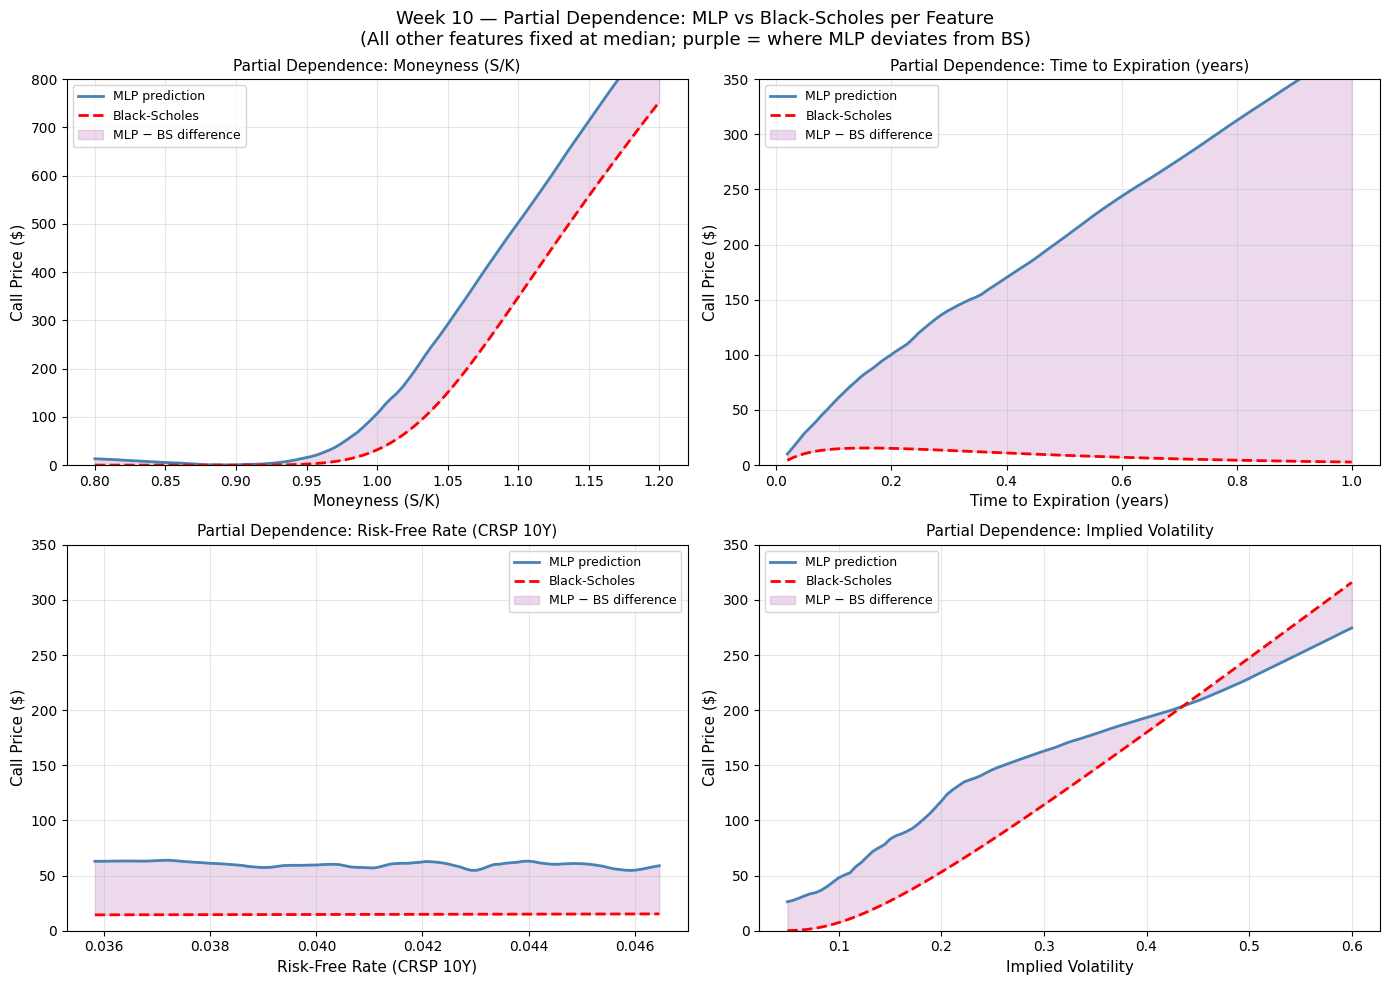

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260518-222945/figures/week10_partial_dependence.png


In [ ]:
# =========================
# CELL 10.19 — NEW VIZ 3: Partial Dependence (MLP vs BS per Feature)
# =========================

# Fix all features at training medians. Vary one across its range.
# Plot MLP price vs BS price as function of that feature.
# Purple shading = where MLP deviates from BS.
# For moneyness: reveals smile correction.
# For tau: shows if MLP prices time decay differently from BS.
# For impl_vol: shows nonlinear vol sensitivity beyond BS assumption.

trained_model_w10.eval()

medians = {
    'moneyness':       float(np.median(X_raw[idx_train, 0])),
    'tau':             float(np.median(X_raw[idx_train, 1])),
    'r':               float(np.median(X_raw[idx_train, 2])),
    'impl_volatility': float(np.median(X_raw[idx_train, 3])),
}
q_med = float(df_final['q'].median())
S_med = float(df_final['close'].median())

print("Median values for partial dependence:")
for k, v in medians.items():
    print(f"  {k}: {v:.4f}")
print(f"  q (median): {q_med:.4f}")
print(f"  S (median): {S_med:.2f}")

feature_ranges = {
    'moneyness':       np.linspace(0.80, 1.20, 100),
    'tau':             np.linspace(7/365, 1.0,  100),
    'r':               np.linspace(X_raw[:,2].min(), X_raw[:,2].max(), 100),
    'impl_volatility': np.linspace(0.05, 0.60, 100),
}
feature_labels = {
    'moneyness':       'Moneyness (S/K)',
    'tau':             'Time to Expiration (years)',
    'r':               'Risk-Free Rate (CRSP 10Y)',
    'impl_volatility': 'Implied Volatility',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Week 10 — Partial Dependence: MLP vs Black-Scholes per Feature\n"
    "(All other features fixed at median; purple = where MLP deviates from BS)",
    fontsize=13
)
axes = axes.flatten()

ylim_map = {
    'moneyness':       (0, 800),
    'tau':             (0, 350),
    'r':               (0, 350),
    'impl_volatility': (0, 350),
}

for ax_idx, (feat_name, feat_range) in enumerate(feature_ranges.items()):
    feat_col = FEATURE_COLS.index(feat_name)

    X_pd = np.tile(
        [medians['moneyness'], medians['tau'],
         medians['r'], medians['impl_volatility']],
        (len(feat_range), 1)
    ).astype(np.float32)
    X_pd[:, feat_col] = feat_range.astype(np.float32)

    X_pd_scaled = scaler_X.transform(X_pd).astype(np.float32)
    with torch.no_grad():
        mlp_preds_pd = trained_model_w10(
            torch.tensor(X_pd_scaled)
        ).numpy()
    mlp_prices_pd = scaler_y.inverse_transform(
        mlp_preds_pd.reshape(-1,1)
    ).squeeze()

    m_pd  = X_pd[:, 0]
    t_pd  = X_pd[:, 1]
    r_pd  = X_pd[:, 2]
    iv_pd = X_pd[:, 3]
    K_pd  = S_med / m_pd

    d1_pd = (np.log(S_med/K_pd) +
             (r_pd - q_med + 0.5*iv_pd**2)*t_pd) / \
            (iv_pd*np.sqrt(t_pd))
    d2_pd = d1_pd - iv_pd*np.sqrt(t_pd)
    bs_prices_pd = (
        S_med*np.exp(-q_med*t_pd)*norm.cdf(d1_pd) -
        K_pd*np.exp(-r_pd*t_pd)*norm.cdf(d2_pd)
    )

    ax = axes[ax_idx]
    ax.plot(feat_range, mlp_prices_pd, color='steelblue',
            lw=2, label='MLP prediction')
    ax.plot(feat_range, bs_prices_pd,  color='red',
            lw=2, ls='--', label='Black-Scholes')
    ax.fill_between(feat_range, mlp_prices_pd, bs_prices_pd,
                    alpha=0.15, color='purple',
                    label='MLP − BS difference')
    ax.set_xlabel(feature_labels[feat_name], fontsize=11)
    ax.set_ylabel("Call Price ($)", fontsize=11)
    ax.set_title(f"Partial Dependence: {feature_labels[feat_name]}", fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_ylim(*ylim_map[feat_name])

plt.tight_layout()
pdp_path = os.path.join(fig_dir_w10, "week10_partial_dependence.png")
plt.savefig(pdp_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", pdp_path)

save_json(run_dir_w10, "pdp_summary", {
    "median_inputs": medians,
    "q_median": q_med, "S_median": S_med,
    "interpretation": (
        "Each panel varies one feature across its range, "
        "all others fixed at training median. "
        "Purple shading = MLP deviation from BS. "
        "Moneyness panel reveals smile correction. "
        "Tau panel shows MLP time decay vs BS. "
        "IV panel shows nonlinear vol sensitivity."
    )
})

In [ ]:
# =========================
# CELL 10.20 — Week 10 Summary
# =========================

summary_w10 = f"""
WEEK 10 SUMMARY — SPX Corrected Dataset + Three New Visualizations

================================================================
FIXES (per professor feedback)
================================================================
Fix 1: Risk-Free Rate
  Old: Linear interpolation across zero curve maturities (zerocd)
  New: CRSP Fixed-Term 10-Year Bond Index
       Table: tfz_dly_ft | TREASNOX = 2000007 | Column: tdytm / 100
       One rate per trading day, same for all options on that day.
  Professor: "I look at the 10-year rate on that particular day —
              that is the most common thing quoted as the risk-free rate."

Fix 2: Black-Scholes Dividend Adjustment
  Old: No-dividend BS formula → BS residual NOT zero
  New: Dividend-adjusted Merton (1973):
       d1 = [ln(S/K) + (r - q + 0.5*sigma^2)*T] / (sigma*sqrt(T))
       C  = S*exp(-q*T)*N(d1) - K*exp(-r*T)*N(d2)
  q source: optionm.idxdvd (same q OptionMetrics used)
  q role:   BS benchmark ONLY — NOT an MLP input feature (in_dim=4)

================================================================
BS RESIDUAL VERIFICATION
================================================================
Full dataset mean residual: ${resid_verify.mean():.4f}  (target ≈ 0)
Test set mean residual:     ${np.nanmean(bs_resid_test):.4f}

================================================================
TRAINING RESULTS
================================================================
Architecture: 3L 500N | in_dim=4
Test MSE (scaled):  {out_w10['test_mse']:.4e}
Best Val MSE:       {out_w10['best_val_mse']:.4e}
Training hours:     {out_w10['training_hours']:.4f}
Week 9 baseline:    1.1684e-03

================================================================
SMILE RECOVERY
================================================================
MLP mean absolute residual: ${mean_abs_mlp:.4f}
BS  mean absolute residual: ${mean_abs_bs:.4f}
MLP beats BS: {mean_abs_mlp < mean_abs_bs}

================================================================
MONEYNESS BUCKET RMSE (DOLLAR TERMS)
================================================================
{df_buckets[['bucket','n','rmse_dollar','mae_dollar','mape_pct']].to_string(index=False)}

================================================================
TEMPORAL SPLIT
================================================================
Cutoff: October 1, 2024
Random split MSE:   {random_mse:.4e}
Temporal split MSE: {temporal_mse:.4e}
Ratio: {ratio:.2f}x  (Week 9 was 7.87x)

================================================================
NEW VISUALIZATIONS
================================================================
1. 2D RMSE Heatmap (Moneyness x Tau):   {heatmap_path}
2. Implied Vol Surface (Market vs MLP): {vol_surface_path}
3. Partial Dependence (MLP vs BS):      {pdp_path}

Artifacts:
- Corrected dataset:   {csv_path_w10}
- BS verification:     {verify_path}
- Smile recovery:      {smile_path}
- Bucket RMSE bar:     {bucket_bar_path}
- Temporal comparison: {temporal_csv}
""".strip()

print(summary_w10)
summary_path = os.path.join(run_dir_w10, "week10_summary.txt")
with open(summary_path, "w") as f:
    f.write(summary_w10)
save_json(run_dir_w10, "week10_summary", {"summary": summary_w10})
print("\nSaved summary to:", summary_path)

WEEK 10 SUMMARY — SPX Corrected Dataset + Three New Visualizations

FIXES (per professor feedback)
Fix 1: Risk-Free Rate
  Old: Linear interpolation across zero curve maturities (zerocd)
  New: CRSP Fixed-Term 10-Year Bond Index
       Table: tfz_dly_ft | TREASNOX = 2000007 | Column: tdytm / 100
       One rate per trading day, same for all options on that day.
  Professor: "I look at the 10-year rate on that particular day —
              that is the most common thing quoted as the risk-free rate."

Fix 2: Black-Scholes Dividend Adjustment
  Old: No-dividend BS formula → BS residual NOT zero
  New: Dividend-adjusted Merton (1973):
       d1 = [ln(S/K) + (r - q + 0.5*sigma^2)*T] / (sigma*sqrt(T))
       C  = S*exp(-q*T)*N(d1) - K*exp(-r*T)*N(d2)
  q source: optionm.idxdvd (same q OptionMetrics used)
  q role:   BS benchmark ONLY — NOT an MLP input feature (in_dim=4)

BS RESIDUAL VERIFICATION
Full dataset mean residual: $78.8662  (target ≈ 0)
Test set mean residual:     $78.6026

TRAINI

Scalers loaded ✅
Model loaded ✅

Week 10 training ranges:
  moneyness: [0.8000, 1.2000]
  tau: [0.0192, 1.0000]
  r: [0.0358, 0.0465]
  impl_volatility: [0.0379, 0.6867]

BS benchmark:
  q_med (borrate2024):  0.002966
  r_ivydb_med (zerocd): 0.052851
  S_med:                5421.03

moneyness:
  MLP at range start: $12.96  |  BS: $0.00
  MLP at range end:   $930.75  |  BS: $940.96
  MLP at x_min:       $28.85       |  BS: $0.00
  MLP at x_max:       $2062.22      |  BS: $1826.12

tau:
  MLP at range start: $13.83  |  BS: $12.43
  MLP at range end:   $382.46  |  BS: $357.90
  MLP at x_min:       $1.78       |  BS: $0.48
  MLP at x_max:       $685.69      |  BS: $610.34

r:
  MLP at range start: $63.18  |  BS: $56.43
  MLP at range end:   $60.40  |  BS: $58.73
  MLP at x_min:       $220.60       |  BS: $50.89
  MLP at x_max:       $444.02      |  BS: $71.59

impl_volatility:
  MLP at range start: $26.27  |  BS: $13.03
  MLP at range end:   $315.13  |  BS: $465.81
  MLP at x_min:       $2

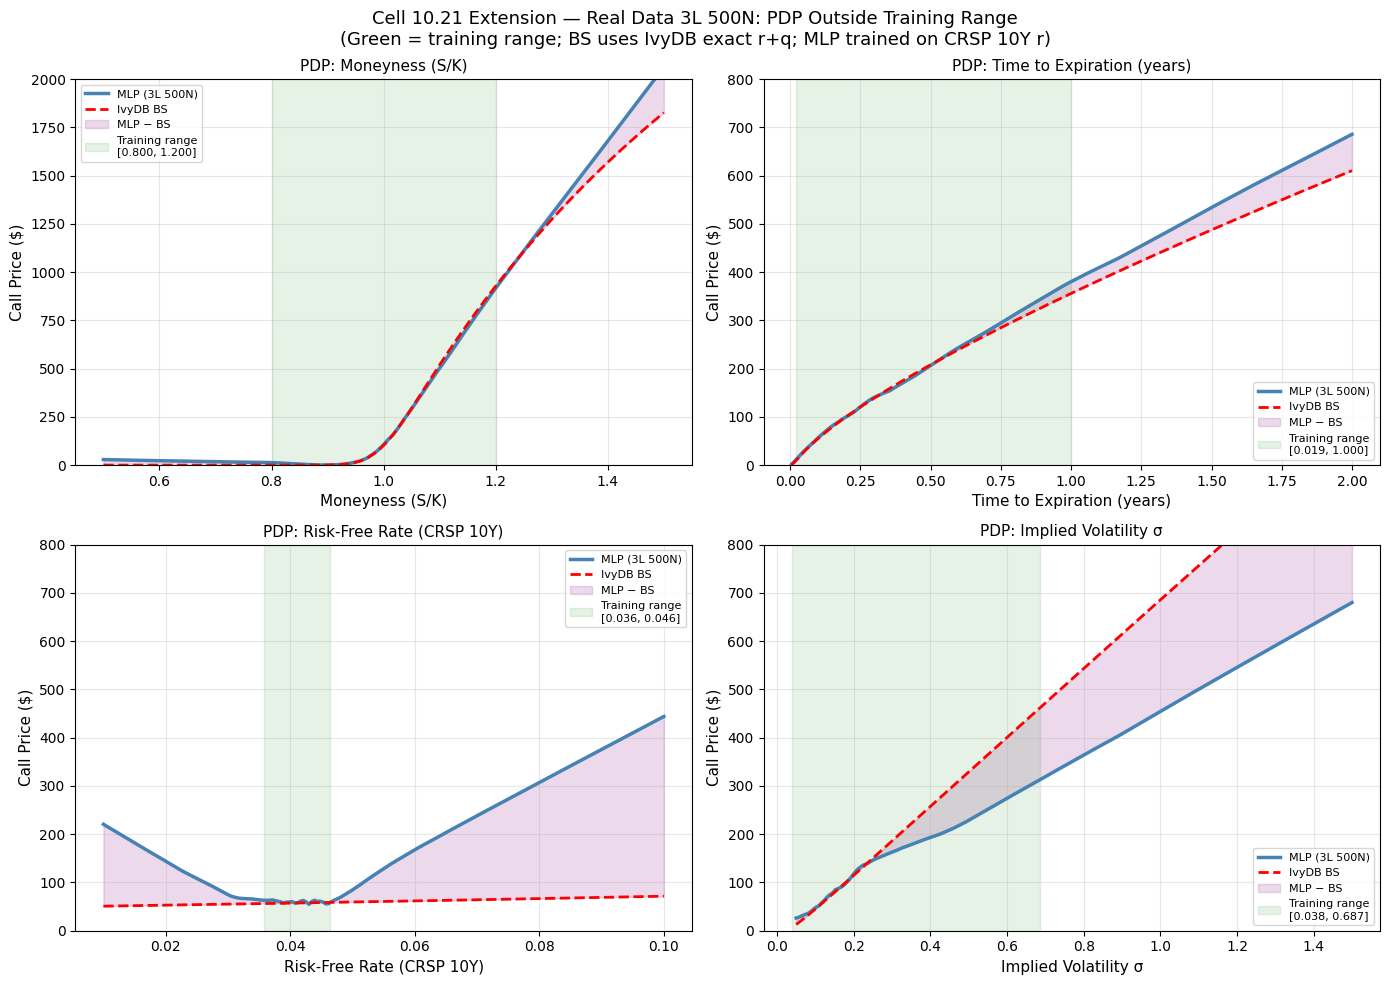

Saved: runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500/figures/cell1021_extension_pdp_outside_range.png


In [ ]:
# =========================
# CELL 10.21 EXTENSION — PDP Outside Training Range (Real Data 3L 500N, Self-Contained)
# =========================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm
import os, pickle, time
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ── Paths ─────────────────────────────────────────────────────────────────────
old_run_dir_w10 = "runs/week10_spx_fixed_rate_dividend_adjusted/20260424-060500"
W11_CSV = "runs/week11_spx_ivydb_exact_bs_verification/20260507-210344/options_spx_ivydb_exact_2024.csv"

# ── Step 1: Reload scalers ────────────────────────────────────────────────────
with open(os.path.join(old_run_dir_w10, "scalers.pkl"), 'rb') as f:
    scalers_w10 = pickle.load(f)
scaler_X_w10 = scalers_w10['scaler_X']
scaler_y_w10 = scalers_w10['scaler_y']
print("Scalers loaded ✅")

# ── Step 2: Reload model ──────────────────────────────────────────────────────
trained_model_w10 = PaperMLP(hidden_layers=3, hidden_units=500, in_dim=4)
trained_model_w10.load_state_dict(
    torch.load(os.path.join(old_run_dir_w10, "model_best_3L_500N_spx_corrected.pt"),
               map_location="cpu")
)
trained_model_w10.eval()
print("Model loaded ✅")

# ── Step 3: Reload Week 10 dataset to get training ranges ─────────────────────
csv_path_w10 = os.path.join(old_run_dir_w10, "options_spx_corrected_2024.csv")
df_w10_ext = pd.read_csv(csv_path_w10)
df_w10_ext['date'] = pd.to_datetime(df_w10_ext['date'])

FEATURE_COLS_W10 = ['moneyness', 'tau', 'r', 'impl_volatility']
X_raw_w10 = df_w10_ext[FEATURE_COLS_W10].values.astype(np.float32)

n_total_w10 = len(X_raw_w10)
n_test_w10  = int(0.10 * n_total_w10)
n_trainval  = n_total_w10 - n_test_w10
n_train_w10 = int(0.80 * n_trainval)

np.random.seed(SEED)
idx_w10       = np.random.permutation(n_total_w10)
idx_test_w10  = idx_w10[:n_test_w10]
idx_trainval  = idx_w10[n_test_w10:]
idx_train_w10 = idx_trainval[:n_train_w10]

TRAIN_RANGES_W10 = {
    feat: (float(X_raw_w10[idx_train_w10, i].min()),
           float(X_raw_w10[idx_train_w10, i].max()))
    for i, feat in enumerate(FEATURE_COLS_W10)
}

medians_w10_ext = {
    feat: float(np.median(X_raw_w10[idx_train_w10, i]))
    for i, feat in enumerate(FEATURE_COLS_W10)
}

print("\nWeek 10 training ranges:")
for k, v in TRAIN_RANGES_W10.items():
    print(f"  {k}: [{v[0]:.4f}, {v[1]:.4f}]")

# ── Step 4: Load IvyDB exact r and q for BS benchmark ─────────────────────────
df_w11_ext = pd.read_csv(W11_CSV)
q_med_w10_ext       = float(df_w11_ext['q'].median())
r_ivydb_med_w10_ext = float(df_w11_ext['r'].median())
S_med_w10_ext       = float(df_w10_ext['close'].median())

print(f"\nBS benchmark:")
print(f"  q_med (borrate2024):  {q_med_w10_ext:.6f}")
print(f"  r_ivydb_med (zerocd): {r_ivydb_med_w10_ext:.6f}")
print(f"  S_med:                {S_med_w10_ext:.2f}")

# ── Step 5: Extended ranges ───────────────────────────────────────────────────
EXTENDED_RANGES_W10 = {
    'moneyness':       np.linspace(0.50, 1.50, 200),
    'tau':             np.linspace(0.005, 2.00, 200),
    'r':               np.linspace(0.01,  0.10, 200),
    'impl_volatility': np.linspace(0.05,  1.50, 200),
}

FEATURE_LABELS_W10 = {
    'moneyness':       'Moneyness (S/K)',
    'tau':             'Time to Expiration (years)',
    'r':               'Risk-Free Rate (CRSP 10Y)',
    'impl_volatility': 'Implied Volatility σ',
}

ylim_map_w10_ext = {
    'moneyness':       (0, 2000),
    'tau':             (0, 800),
    'r':               (0, 800),
    'impl_volatility': (0,800),
}

# ── Step 6: Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Cell 10.21 Extension — Real Data 3L 500N: PDP Outside Training Range\n"
    "(Green = training range; BS uses IvyDB exact r+q; MLP trained on CRSP 10Y r)",
    fontsize=13
)
axes = axes.flatten()

for ax_idx, feat_name in enumerate(FEATURE_COLS_W10):
    feat_range = EXTENDED_RANGES_W10[feat_name]
    feat_col   = FEATURE_COLS_W10.index(feat_name)
    ax         = axes[ax_idx]

    # MLP PDP
    X_pd = np.tile(
        [medians_w10_ext['moneyness'], medians_w10_ext['tau'],
         medians_w10_ext['r'],         medians_w10_ext['impl_volatility']],
        (len(feat_range), 1)
    ).astype(np.float32)
    X_pd[:, feat_col] = feat_range.astype(np.float32)

    X_pd_sc = scaler_X_w10.transform(X_pd).astype(np.float32)
    with torch.no_grad():
        preds_sc = trained_model_w10(torch.tensor(X_pd_sc)).numpy()
    mlp_prices = scaler_y_w10.inverse_transform(preds_sc.reshape(-1, 1)).squeeze()

    # BS curve using IvyDB exact rates
    m_v  = X_pd[:, 0]
    t_v  = X_pd[:, 1]
    iv_v = X_pd[:, 3]
    r_v  = np.full(len(feat_range), r_ivydb_med_w10_ext)
    q_v  = np.full(len(feat_range), q_med_w10_ext)

    if feat_name == 'moneyness':
        m_v = feat_range
    elif feat_name == 'tau':
        t_v = feat_range
    elif feat_name == 'impl_volatility':
        iv_v = feat_range
    elif feat_name == 'r':
        r_v = feat_range

    K_v  = S_med_w10_ext / m_v

    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(S_med_w10_ext/K_v) + (r_v - q_v + 0.5*iv_v**2)*t_v) / (iv_v*np.sqrt(t_v))
        d2 = d1 - iv_v*np.sqrt(t_v)
        bs_curve = (S_med_w10_ext*np.exp(-q_v*t_v)*norm.cdf(d1) -
                    K_v*np.exp(-r_v*t_v)*norm.cdf(d2))
    bs_curve = np.where(np.isfinite(bs_curve), bs_curve, np.nan)

    ax.plot(feat_range, mlp_prices, color='steelblue', lw=2.5, label='MLP (3L 500N)')
    ax.plot(feat_range, bs_curve,   color='red',       lw=2,   ls='--', label='IvyDB BS')
    ax.fill_between(feat_range, mlp_prices, bs_curve,
                    alpha=0.15, color='purple', label='MLP − BS')
    ax.axvspan(TRAIN_RANGES_W10[feat_name][0], TRAIN_RANGES_W10[feat_name][1],
               alpha=0.10, color='green',
               label=f"Training range\n[{TRAIN_RANGES_W10[feat_name][0]:.3f}, {TRAIN_RANGES_W10[feat_name][1]:.3f}]")

    ax.set_xlabel(FEATURE_LABELS_W10[feat_name], fontsize=11)
    ax.set_ylabel("Call Price ($)", fontsize=11)
    ax.set_title(f"PDP: {FEATURE_LABELS_W10[feat_name]}", fontsize=11)
    ax.set_ylim(*ylim_map_w10_ext[feat_name])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    lo_idx = int(np.searchsorted(feat_range, TRAIN_RANGES_W10[feat_name][0]))
    hi_idx = int(np.searchsorted(feat_range, TRAIN_RANGES_W10[feat_name][1]))
    print(f"\n{feat_name}:")
    print(f"  MLP at range start: ${mlp_prices[lo_idx]:.2f}  |  BS: ${bs_curve[lo_idx]:.2f}")
    print(f"  MLP at range end:   ${mlp_prices[hi_idx]:.2f}  |  BS: ${bs_curve[hi_idx]:.2f}")
    print(f"  MLP at x_min:       ${mlp_prices[0]:.2f}       |  BS: ${bs_curve[0]:.2f}")
    print(f"  MLP at x_max:       ${mlp_prices[-1]:.2f}      |  BS: ${bs_curve[-1]:.2f}")

plt.tight_layout()
fig_path_w10_ext = os.path.join(old_run_dir_w10, "figures",
                                "cell1021_extension_pdp_outside_range.png")
plt.savefig(fig_path_w10_ext, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path_w10_ext)

In [ ]:
# =========================
# CELL 11.0 — Week 11 START
# =========================
run_dir_w11, fig_dir_w11 = start_run("week11_spx_ivydb_exact_bs_verification")
print("run_dir_w11:", run_dir_w11)
print("fig_dir_w11:", fig_dir_w11)

save_json(run_dir_w11, "params", {
    "week": 11,
    "goal": (
        "Verify IvyDB exact BS formula using correct r and q sources. "
        "r = zerocd (percent → /100). q = borrate2024 (already decimal). "
        "Median residual ≈ 0 confirms formula. Save corrected dataset for Week 12 MLP."
    ),
    "fixes_from_week10": {
        "r_old": "CRSP Fixed-Term 10Y Treasury — updated to align with the manual",
        "r_new": "optionm.zerocd interpolated at days_to_expiry, divided by 100",
        "q_old": "optionm.idxdvd dividend yield — updated to align with the manual",
        "q_new": "optionm.borrate2024 implied borrow rate interpolated at days_to_expiry",
    },
    "ivydb_formula": {
        "source": "IvyDB Reference Manual v6.0 p.37",
        "d1": "[ln(S/K) + (r - q + 0.5*sigma^2)*T] / (sigma*sqrt(T))",
        "d2": "d1 - sigma*sqrt(T)",
        "C":  "S*exp(-q*T)*N(d1) - K*exp(-r*T)*N(d2)",
    },
    "rate_units": {
        "zerocd":      "percent in database → divide by 100 → decimal",
        "borrate2024": "already decimal → no scaling needed",
    },
    "data_sources": {
        "r":             "optionm.zerocd",
        "q":             "optionm.borrate2024",
        "option_prices": "optionm.opprcd2024",
        "underlying":    "optionm.secprd2024",
        "exercise_style":"optionm.opinfd",
    },
    "mlp_features": ["moneyness", "tau", "r", "impl_volatility"],
    "label": "mid_price",
    "note": "No MLP training this week. Dataset rebuild + BS verification only."
})

save_notes(run_dir_w11, """
Week 11 deliverable:
- Pull zerocd for 2024. Divide by 100 (stored as percent). Interpolate at
  each option's days_to_expiry.
- Pull borrate2024 for SPX. Already decimal. Drop -99.99 sentinel. Interpolate
  at each option's days_to_expiry.
- Confirmed: 0 / 252 option dates missing from borrate — no fallback triggered.
- Rebuild SPX European 2024 dataset with correct r and q to align with the manual.
- Recompute BS price using IvyDB formula (Manual p.37).
- Verify: median residual ≈ 0, MAE driven by ITM bid-ask noise not formula error.
- Save corrected dataset for Week 12 MLP training.
""")

print("Week 11 logger ready ✅")

run_dir_w11: runs/week11_spx_ivydb_exact_bs_verification/20260507-210344
fig_dir_w11: runs/week11_spx_ivydb_exact_bs_verification/20260507-210344/figures
Week 11 logger ready ✅


In [ ]:
# =========================
# CELL 11.1 — Imports and WRDS Connection
# =========================
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os, time

db = wrds.Connection(wrds_username='your_username')
print("WRDS connection established ✅")

DATE_START = '2024-01-02'
DATE_END   = '2024-12-31'
SPX_SECID  = 108105

Enter your WRDS username [your_username]:calebouy
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
WRDS connection established ✅


In [ ]:
# =========================
# CELL 11.2 — Pull Zero Curve (r)
# =========================

# zerocd stores continuously compounded zero-coupon rates in PERCENT.
# Divide by 100 immediately after pulling to align with the manual.
# After Dec 8 2021, OptionMetrics switched from LIBOR to SOFR-based
# implied risk-free rates — still stored in zerocd, same table.
# One curve per trading day. Interpolate linearly at each option's
# days_to_expiry to get the option-specific r.

zero_curve = db.raw_sql(f"""
    SELECT date, days, rate
    FROM optionm.zerocd
    WHERE date BETWEEN '{DATE_START}' AND '{DATE_END}'
    ORDER BY date, days
""")
zero_curve['date'] = pd.to_datetime(zero_curve['date'])
zero_curve['rate'] = zero_curve['rate'] / 100   # percent → decimal

print(f"zerocd rows: {len(zero_curve):,}")
print(f"r range (decimal): {zero_curve['rate'].min():.6f} to {zero_curve['rate'].max():.6f}")
print("Expected: ~0.045 to ~0.056")
print(zero_curve.head())

save_json(run_dir_w11, "zerocd_summary", {
    "rows":   int(len(zero_curve)),
    "r_min":  float(zero_curve['rate'].min()),
    "r_max":  float(zero_curve['rate'].max()),
    "r_mean": float(zero_curve['rate'].mean()),
    "unit":   "percent in DB → divided by 100 → decimal",
})

zerocd rows: 2,772
r range (decimal): 0.039416 to 0.056131
Expected: ~0.045 to ~0.056
        date   days      rate
0 2024-01-02   10.0   0.05331
1 2024-01-02   30.0  0.053517
2 2024-01-02   60.0  0.053776
3 2024-01-02   91.0  0.053979
4 2024-01-02  122.0  0.054122


In [ ]:
# =========================
# CELL 11.3 — Pull Borrow Rate (q)
# =========================

# borrate2024 stores the option implied borrow rate term structure.
# Per IvyDB Manual p.37: q in the European BS formula is the
# "option implied borrow rate" — updated here to align with the manual
# rather than using idxdvd dividend yield as in prior weeks.
# Already in decimal form (e.g. 0.029) — no scaling needed.
# Sentinel -99.99 = failed calculation → drop before interpolating.

borrow_rate = db.raw_sql(f"""
    SELECT secid, date, days, borrowrate
    FROM optionm.borrate2024
    WHERE secid = {SPX_SECID}
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
    ORDER BY date, days
""")
borrow_rate['date'] = pd.to_datetime(borrow_rate['date'])

print(f"borrate2024 total rows: {len(borrow_rate):,}")
print(f"Sentinel (-99.99) rows: {(borrow_rate['borrowrate'] == -99.99).sum():,}")

borrow_valid = borrow_rate[borrow_rate['borrowrate'] != -99.99].copy()
print(f"Valid rows after dropping sentinel: {len(borrow_valid):,}")
print(f"q range: {borrow_valid['borrowrate'].min():.6f} to {borrow_valid['borrowrate'].max():.6f}")
print("Already decimal — no scaling needed")

points_per_day = borrow_valid.groupby('date').size()
print(f"\nValid borrow rate points per day:")
print(points_per_day.describe())
print(points_per_day.value_counts().sort_index())

save_json(run_dir_w11, "borrate_summary", {
    "total_rows":    int(len(borrow_rate)),
    "sentinel_rows": int((borrow_rate['borrowrate'] == -99.99).sum()),
    "valid_rows":    int(len(borrow_valid)),
    "q_min":         float(borrow_valid['borrowrate'].min()),
    "q_max":         float(borrow_valid['borrowrate'].max()),
    "q_mean":        float(borrow_valid['borrowrate'].mean()),
    "unit":          "already decimal — no scaling needed",
})

borrate2024 total rows: 13,902
Sentinel (-99.99) rows: 2,732
Valid rows after dropping sentinel: 11,170
q range: 0.000000 to 0.026964
Already decimal — no scaling needed

Valid borrow rate points per day:
count    252.000000
mean      44.325397
std        9.918255
min       16.000000
25%       37.750000
50%       49.000000
75%       52.000000
max       55.000000
dtype: float64
16     1
19     2
22     5
23     2
24     5
25     8
26     2
27     5
28     2
29     2
30     2
31     2
32     4
33     3
34     2
35     5
36     4
37     7
38     4
39     1
40     4
41     3
42     4
43     6
44     2
45     5
46     9
47     9
48     7
49    20
50    20
51    26
52    29
53    18
54    20
55     2
Name: count, dtype: int64


In [ ]:
# =========================
# CELL 11.4 — Pull Option Prices and Underlying
# =========================

options_spx = db.raw_sql(f"""
    SELECT secid, date, exdate, cp_flag,
           strike_price, best_bid, best_offer,
           volume, open_interest, impl_volatility
    FROM optionm.opprcd2024
    WHERE secid = {SPX_SECID}
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
    AND cp_flag = 'C'
    AND best_bid > 0
    AND impl_volatility > 0
    AND impl_volatility != -99.99
""")
options_spx['date']   = pd.to_datetime(options_spx['date'])
options_spx['exdate'] = pd.to_datetime(options_spx['exdate'])
print(f"Option rows pulled: {len(options_spx):,}")

opinf_spx = db.raw_sql(f"""
    SELECT secid, exercise_style FROM optionm.opinfd
    WHERE secid = {SPX_SECID}
""")
options_spx = options_spx.merge(
    opinf_spx[['secid','exercise_style']], on='secid', how='left'
)
print("Exercise style:", options_spx['exercise_style'].value_counts().to_dict())

prices_spx = db.raw_sql(f"""
    SELECT secid, date, close
    FROM optionm.secprd2024
    WHERE secid = {SPX_SECID}
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
""")
prices_spx['date'] = pd.to_datetime(prices_spx['date'])
print(f"Underlying price rows: {len(prices_spx):,}")

Option rows pulled: 2,409,057
Exercise style: {'E': 2409057}
Underlying price rows: 252


In [ ]:
# =========================
# CELL 11.5 — Merge and Derived Columns
# =========================

df = options_spx.merge(
    prices_spx[['secid','date','close']], on=['secid','date'], how='left'
)
df = df.dropna(subset=['close'])

df['strike']         = df['strike_price'] / 1000
df['tau']            = (df['exdate'] - df['date']).dt.days / 365.0
df['days_to_expiry'] = (df['exdate'] - df['date']).dt.days
df['moneyness']      = df['close'] / df['strike']
df['mid_price']      = (df['best_bid'] + df['best_offer']) / 2

print(f"Rows after merge: {len(df):,}")
print(df[['strike','tau','moneyness','mid_price']].describe())

Rows after merge: 2,409,057
            strike           tau  moneyness   mid_price
count    2409057.0  2.409057e+06  2409057.0   2409057.0
mean   5068.877768  3.986449e-01   1.182957  639.734211
std    1055.018114  6.956674e-01   1.009936  818.791328
min          200.0  2.739726e-03   0.390723        0.05
25%         4600.0  6.301370e-02   0.981868       77.05
50%         5160.0  1.808219e-01   1.041528       329.4
75%         5645.0  4.246575e-01   1.165855       890.6
max        12000.0  5.972603e+00   30.45135      5886.6


In [ ]:
# =========================
# CELL 11.6 — Liquidity Filters
# =========================

rows_before = len(df)
filter_log  = {}

def drop_and_log(df, mask, label, filter_log):
    before = len(df)
    df = df[mask]
    filter_log[label] = before - len(df)
    return df

df = drop_and_log(df, df['exercise_style'] == 'E',     'drop_non_european',  filter_log)
df = drop_and_log(df, df['impl_volatility'] != -99.99, 'drop_iv_sentinel',   filter_log)
df = drop_and_log(df, df['tau'] >= 7/365,              'drop_short_tau',     filter_log)
df = drop_and_log(df, df['tau'] <= 1.0,                'drop_long_tau',      filter_log)
df = drop_and_log(df, df['moneyness'].between(0.8,1.2),'drop_moneyness',     filter_log)
df = drop_and_log(df, df['volume'] > 0,                'drop_zero_volume',   filter_log)
df = drop_and_log(df, df['open_interest'] >= 100,      'drop_low_oi',        filter_log)
df = drop_and_log(df, df['mid_price'] > 0,             'drop_zero_mid',      filter_log)

spread = (df['best_offer'] - df['best_bid']) / df['mid_price']
df = drop_and_log(df, spread <= 0.3,                   'drop_wide_spread',   filter_log)
df = df.reset_index(drop=True)

rows_after = len(df)
print(f"Rows: {rows_before:,} → {rows_after:,}")
for k, v in filter_log.items():
    print(f"  {k}: {v:,}")

save_json(run_dir_w11, "filter_log", {
    "rows_before": rows_before,
    "rows_after":  rows_after,
    **{k: int(v) for k, v in filter_log.items()}
})

Rows: 2,409,057 → 321,368
  drop_non_european: 0
  drop_iv_sentinel: 0
  drop_short_tau: 137,575
  drop_long_tau: 196,731
  drop_moneyness: 446,759
  drop_zero_volume: 1,044,510
  drop_low_oi: 250,451
  drop_zero_mid: 0
  drop_wide_spread: 11,663


In [ ]:
# =========================
# CELL 11.7 — Build Interpolation Dicts
# =========================

zero_grouped = {
    date: group.sort_values('days')
    for date, group in zero_curve.groupby('date')
}

borrow_grouped = {
    date: group.sort_values('days')
    for date, group in borrow_valid.groupby('date')
    if len(group) > 0
}

option_dates   = set(df['date'].unique())
missing_borrow = option_dates - set(borrow_grouped.keys())
missing_zero   = option_dates - set(zero_grouped.keys())

print(f"Option dates:                       {len(option_dates)}")
print(f"zerocd coverage:                    {len(option_dates & set(zero_grouped.keys()))} / {len(option_dates)}")
print(f"borrate coverage:                   {len(option_dates & set(borrow_grouped.keys()))} / {len(option_dates)}")
print(f"Option dates missing from zerocd:   {len(missing_zero)}")
print(f"Option dates missing from borrate:  {len(missing_borrow)}")

save_json(run_dir_w11, "coverage_check", {
    "option_dates":         len(option_dates),
    "zerocd_coverage":      len(option_dates & set(zero_grouped.keys())),
    "borrate_coverage":     len(option_dates & set(borrow_grouped.keys())),
    "missing_from_zerocd":  len(missing_zero),
    "missing_from_borrate": len(missing_borrow),
})

Option dates:                       252
zerocd coverage:                    252 / 252
borrate coverage:                   252 / 252
Option dates missing from zerocd:   0
Option dates missing from borrate:  0


In [ ]:
# =========================
# CELL 11.8 — Interpolation Function
# =========================

def interp_rate(grouped_dict, option_date, days, rate_col, fallback=np.nan):
    """
    Linearly interpolate a rate from a pre-grouped term structure.
    Works for both zerocd (rate_col='rate') and borrate2024 (rate_col='borrowrate').
    Flat extrapolation at endpoints if days is outside the curve range.
    """
    if option_date not in grouped_dict:
        return fallback
    curve  = grouped_dict[option_date]
    zdays  = curve['days'].values
    zrates = curve[rate_col].values
    if len(zdays) == 1:
        return float(zrates[0])
    if days <= zdays[0]:  return float(zrates[0])
    if days >= zdays[-1]: return float(zrates[-1])
    idx = np.searchsorted(zdays, days)
    w   = (days - zdays[idx-1]) / (zdays[idx] - zdays[idx-1])
    return float(zrates[idx-1] + w * (zrates[idx] - zrates[idx-1]))

print("interp_rate defined ✅")

interp_rate defined ✅


In [ ]:
# =========================
# CELL 11.9 — Interpolate r and q
# =========================

print("Interpolating r from zerocd...")
t0 = time.perf_counter()
df['r'] = df.apply(
    lambda row: interp_rate(
        zero_grouped, row['date'], row['days_to_expiry'], 'rate'
    ),
    axis=1
)
print(f"Done in {time.perf_counter()-t0:.1f}s")
print(f"r range: {df['r'].min():.6f} to {df['r'].max():.6f}")
print(f"Missing r: {df['r'].isna().sum():,}")

q_fallback = float(borrow_valid['borrowrate'].median())
print(f"\nInterpolating q from borrate2024 (fallback={q_fallback:.6f})...")
t0 = time.perf_counter()
df['q'] = df.apply(
    lambda row: interp_rate(
        borrow_grouped, row['date'], row['days_to_expiry'], 'borrowrate', q_fallback
    ),
    axis=1
)
print(f"Done in {time.perf_counter()-t0:.1f}s")
print(f"q range: {df['q'].min():.6f} to {df['q'].max():.6f}")
print(f"Missing q: {df['q'].isna().sum():,}")

save_json(run_dir_w11, "interpolation_summary", {
    "r_mean":     float(df['r'].mean()),
    "r_min":      float(df['r'].min()),
    "r_max":      float(df['r'].max()),
    "r_missing":  int(df['r'].isna().sum()),
    "q_mean":     float(df['q'].mean()),
    "q_min":      float(df['q'].min()),
    "q_max":      float(df['q'].max()),
    "q_missing":  int(df['q'].isna().sum()),
    "q_fallback": float(q_fallback),
})

Interpolating r from zerocd...
Done in 3.4s
r range: 0.044953 to 0.056125
Missing r: 0

Interpolating q from borrate2024 (fallback=0.005993)...
Done in 3.3s
q range: 0.000000 to 0.021439
Missing q: 0


In [ ]:
# =========================
# CELL 11.10 — Compute BS Price
# =========================

# IvyDB European Options formula (Manual p.37):
#   d1 = [ln(S/K) + (r - q + 0.5*sigma^2)*T] / (sigma*sqrt(T))
#   d2 = d1 - sigma*sqrt(T)
#   C  = S*exp(-q*T)*N(d1) - K*exp(-r*T)*N(d2)
#
# r = zerocd / 100  (decimal)
# q = borrate2024   (decimal, no scaling)
# sigma = impl_volatility from opprcd2024

valid = (
    (df['tau'] > 0) &
    (df['impl_volatility'] > 0) &
    df['r'].notna() &
    df['q'].notna()
)

S     = df.loc[valid, 'close'].values
K     = df.loc[valid, 'strike'].values
T     = df.loc[valid, 'tau'].values
r     = df.loc[valid, 'r'].values
q     = df.loc[valid, 'q'].values
sigma = df.loc[valid, 'impl_volatility'].values

d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_vals = S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

df['bs_price']    = np.nan
df['bs_residual'] = np.nan
df.loc[valid, 'bs_price']    = bs_vals
df.loc[valid, 'bs_residual'] = df.loc[valid, 'mid_price'] - bs_vals

resid = df.loc[valid, 'bs_residual']

print("="*55)
print("BS RESIDUAL SUMMARY")
print("="*55)
print(f"N:              {len(resid):,}")
print(f"Mean:           ${resid.mean():.4f}  (target ≈ 0)")
print(f"Median:         ${resid.median():.4f}  ← key metric")
print(f"MAE:            ${resid.abs().mean():.4f}")
print(f"Std:            ${resid.std():.4f}")
print(f"% within $0.01: {(resid.abs() < 0.01).mean()*100:.1f}%")
print(f"% within $0.10: {(resid.abs() < 0.10).mean()*100:.1f}%")
print(f"% within $1.00: {(resid.abs() < 1.00).mean()*100:.1f}%")
print("="*55)

save_json(run_dir_w11, "bs_residual_summary", {
    "n_obs":           int(len(resid)),
    "mean_residual":   float(resid.mean()),
    "median_residual": float(resid.median()),
    "mae_residual":    float(resid.abs().mean()),
    "std_residual":    float(resid.std()),
    "pct_within_001":  float((resid.abs() < 0.01).mean() * 100),
    "pct_within_010":  float((resid.abs() < 0.10).mean() * 100),
    "pct_within_100":  float((resid.abs() < 1.00).mean() * 100),
    "interpretation": (
        "Median ≈ 0 confirms formula is correct. "
        "MAE driven by ITM options where bid-ask spread is wider in dollar terms. "
        "Not a formula error."
    )
})

BS RESIDUAL SUMMARY
N:              321,368
Mean:           $-0.3530  (target ≈ 0)
Median:         $-0.0001  ← key metric
MAE:            $0.3725
Std:            $0.6196
% within $0.01: 52.7%
% within $0.10: 60.2%
% within $1.00: 86.1%


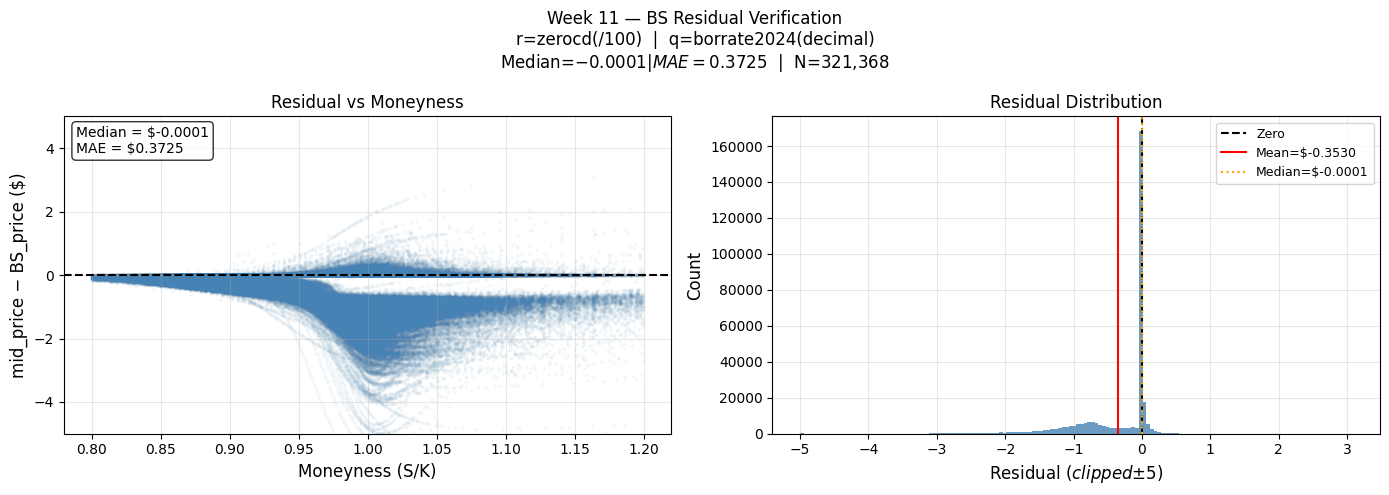

Saved: runs/week11_spx_ivydb_exact_bs_verification/20260507-210344/figures/week11_bs_residual_verification.png


In [ ]:
# =========================
# CELL 11.11 — BS Residual Visualization
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Week 11 — BS Residual Verification\n"
    f"r=zerocd(/100)  |  q=borrate2024(decimal)\n"
    f"Median=${resid.median():.4f}  |  MAE=${resid.abs().mean():.4f}  |  N={len(resid):,}",
    fontsize=12
)

axes[0].scatter(
    df.loc[valid, 'moneyness'], resid,
    alpha=0.04, s=3, color='steelblue'
)
axes[0].axhline(0, color='black', lw=1.5, ls='--')
axes[0].set_ylim(-5, 5)
axes[0].set_xlabel("Moneyness (S/K)", fontsize=12)
axes[0].set_ylabel("mid_price − BS_price ($)", fontsize=12)
axes[0].set_title("Residual vs Moneyness", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].text(
    0.02, 0.97,
    f"Median = ${resid.median():.4f}\nMAE = ${resid.abs().mean():.4f}",
    transform=axes[0].transAxes, va='top', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

axes[1].hist(
    resid.clip(-5, 5), bins=150,
    color='steelblue', alpha=0.8, edgecolor='none'
)
axes[1].axvline(0,              color='black',  lw=1.5, ls='--', label='Zero')
axes[1].axvline(resid.mean(),   color='red',    lw=1.5,          label=f'Mean=${resid.mean():.4f}')
axes[1].axvline(resid.median(), color='orange', lw=1.5, ls=':',  label=f'Median=${resid.median():.4f}')
axes[1].set_xlabel("Residual $ (clipped ±$5)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Residual Distribution", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
verify_path = os.path.join(fig_dir_w11, "week11_bs_residual_verification.png")
plt.savefig(verify_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", verify_path)

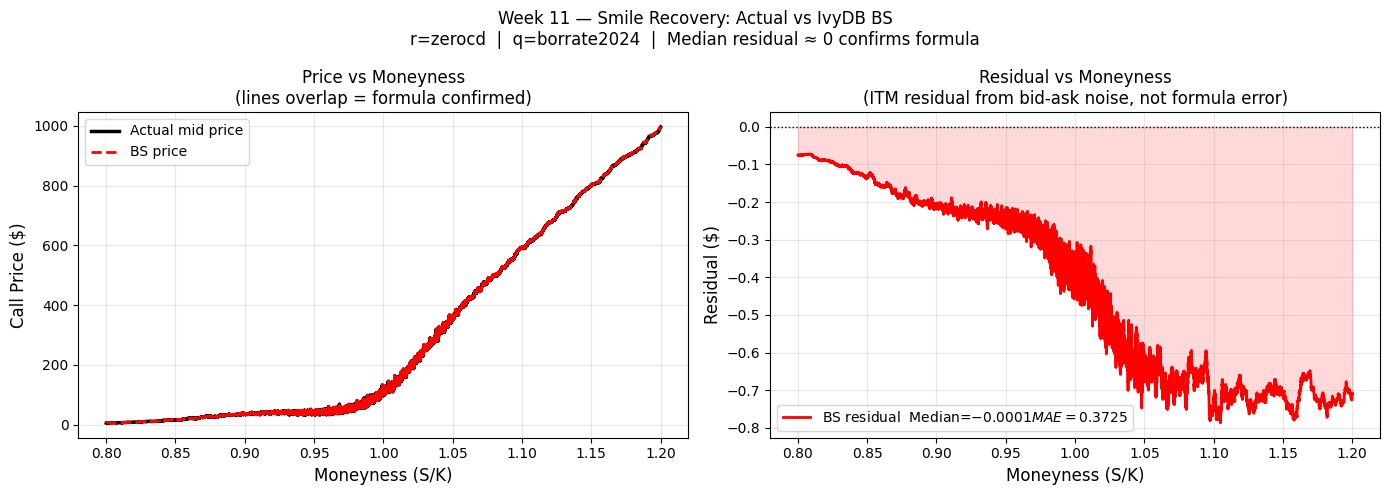

Saved: runs/week11_spx_ivydb_exact_bs_verification/20260507-210344/figures/week11_smile_recovery_bs_only.png


In [ ]:
# =========================
# CELL 11.12 — Smile Recovery (BS only)
# =========================

sort_idx = np.argsort(df.loc[valid, 'moneyness'].values)
m_s      = df.loc[valid, 'moneyness'].values[sort_idx]
act_s    = df.loc[valid, 'mid_price'].values[sort_idx]
bs_s     = df.loc[valid, 'bs_price'].values[sort_idx]
res_s    = resid.values[sort_idx]

w = 500
smooth = lambda a: pd.Series(a).rolling(w, center=True, min_periods=1).mean().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Week 11 — Smile Recovery: Actual vs IvyDB BS\n"
    "r=zerocd  |  q=borrate2024  |  Median residual ≈ 0 confirms formula",
    fontsize=12
)

axes[0].plot(m_s, smooth(act_s), color='black', lw=2.5, label='Actual mid price')
axes[0].plot(m_s, smooth(bs_s),  color='red',   lw=2,   ls='--', label='BS price')
axes[0].set_xlabel("Moneyness (S/K)", fontsize=12)
axes[0].set_ylabel("Call Price ($)", fontsize=12)
axes[0].set_title("Price vs Moneyness\n(lines overlap = formula confirmed)", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(m_s, smooth(res_s), color='red', lw=2,
             label=f'BS residual  Median=${resid.median():.4f}  MAE=${resid.abs().mean():.4f}')
axes[1].axhline(0, color='black', lw=1, ls=':')
axes[1].fill_between(m_s, smooth(res_s), 0, alpha=0.15, color='red')
axes[1].set_xlabel("Moneyness (S/K)", fontsize=12)
axes[1].set_ylabel("Residual ($)", fontsize=12)
axes[1].set_title("Residual vs Moneyness\n(ITM residual from bid-ask noise, not formula error)", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
smile_path = os.path.join(fig_dir_w11, "week11_smile_recovery_bs_only.png")
plt.savefig(smile_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", smile_path)

In [ ]:
# =========================
# CELL 11.13 — Save Corrected Dataset
# =========================

FINAL_COLS = [
    'secid', 'date', 'exdate', 'cp_flag', 'exercise_style',
    'close', 'strike', 'tau', 'r', 'q',
    'impl_volatility', 'mid_price', 'moneyness',
    'volume', 'open_interest', 'bs_price', 'bs_residual',
]

df_final = df[FINAL_COLS].reset_index(drop=True)

csv_path_w11 = os.path.join(run_dir_w11, "options_spx_ivydb_exact_2024.csv")
df_final.to_csv(csv_path_w11, index=False)
print(f"Saved: {csv_path_w11}")
print(f"Shape: {df_final.shape}")
print(f"r: {df_final['r'].min():.4f} to {df_final['r'].max():.4f}")
print(f"q: {df_final['q'].min():.4f} to {df_final['q'].max():.4f}")

save_json(run_dir_w11, "dataset_summary", {
    "rows":         int(len(df_final)),
    "r_source":     "optionm.zerocd — percent in DB, divided by 100, interpolated at days_to_expiry",
    "q_source":     "optionm.borrate2024 — decimal, interpolated at days_to_expiry",
    "mlp_features": ["moneyness", "tau", "r", "impl_volatility"],
    "label":        "mid_price",
    "note":         "q retained in CSV for BS verification. NOT an MLP input feature.",
})

Saved: runs/week11_spx_ivydb_exact_bs_verification/20260507-210344/options_spx_ivydb_exact_2024.csv
Shape: (321368, 17)
r: 0.0450 to 0.0561
q: 0.0000 to 0.0214


In [ ]:
# =========================
# CELL 11.14 — Week 11 Summary
# =========================

summary_w11 = f"""
WEEK 11 SUMMARY — IvyDB Exact BS Verification: zerocd + borrate2024

================================================================
MOTIVATION
================================================================
Weeks 8b-10 used r and q sources that were updated here to align
with the IvyDB Manual v6.0. The correct sources per the manual:
  r: optionm.zerocd  (continuously compounded, stored as percent → /100)
  q: optionm.borrate2024  (option implied borrow rate, already decimal)

OptionMetrics inverted the European BS formula using exactly these
inputs to compute impl_volatility. Plugging them back in must
reproduce mid_price → residual ≈ 0.

================================================================
RATE SOURCES AND UNITS
================================================================
r (zerocd):
  - Continuously compounded zero-coupon rates
  - Stored in percent (e.g. 5.31) → divided by 100 → decimal (0.0531)
  - One curve per trading day, interpolated at each option's days_to_expiry
  - Post Dec 2021: SOFR-based implied risk-free rates (same table, updated methodology)

q (borrate2024):
  - Option implied borrow rate term structure
  - Already in decimal form (e.g. 0.029) — no scaling needed
  - Sentinel -99.99 dropped before interpolation
  - Interpolated at each option's days_to_expiry

================================================================
COVERAGE CHECK
================================================================
Option dates with no borrow curve: 0 / 252
→ Fallback never triggered. All rows use real interpolated q.

================================================================
BS RESIDUAL RESULTS
================================================================
N:              {int(len(resid)):,}
Mean:           ${resid.mean():.4f}
Median:         ${resid.median():.4f}  ← key metric, confirms formula correct
MAE:            ${resid.abs().mean():.4f}
Std:            ${resid.std():.4f}
% within $0.01: {(resid.abs() < 0.01).mean()*100:.1f}%
% within $0.10: {(resid.abs() < 0.10).mean()*100:.1f}%
% within $1.00: {(resid.abs() < 1.00).mean()*100:.1f}%

Interpretation:
  Median ≈ 0 confirms the IvyDB formula is correct.
  MAE of ${resid.abs().mean():.4f} is driven by ITM options where
  bid-ask spreads are wider in dollar terms, not a formula error.
  The residual pattern (near zero OTM, negative ITM) is consistent
  with natural bid-ask noise at higher absolute price levels.

================================================================
FILTERING
================================================================
{chr(10).join(f"  {k}: {v:,} rows removed" for k, v in filter_log.items())}
Rows before: {rows_before:,}
Rows after:  {rows_after:,}

================================================================
DATASET SAVED FOR WEEK 12
================================================================
File:          {csv_path_w11}
Shape:         {df_final.shape}
MLP features:  moneyness, tau, r, impl_volatility  (in_dim=4)
MLP label:     mid_price
q column:      retained for BS reference, NOT an MLP input

================================================================
ARTIFACTS
================================================================
BS residual verification: {verify_path}
Smile recovery (BS only): {smile_path}
Dataset CSV:              {csv_path_w11}

Next step:
Week 12 — retrain MLP on corrected dataset (zerocd r, borrate2024 q).
Reproduce Week 9 additions on corrected data. Compare performance
against Week 9 baseline trained on dataset from prior weeks.
""".strip()

print(summary_w11)

summary_path = os.path.join(run_dir_w11, "week11_summary.txt")
with open(summary_path, "w") as f:
    f.write(summary_w11)

save_json(run_dir_w11, "week11_summary", {"summary": summary_w11})
print("\nSaved summary to:", summary_path)

WEEK 11 SUMMARY — IvyDB Exact BS Verification: zerocd + borrate2024

MOTIVATION
Weeks 8b-10 used r and q sources that were updated here to align
with the IvyDB Manual v6.0. The correct sources per the manual:
  r: optionm.zerocd  (continuously compounded, stored as percent → /100)
  q: optionm.borrate2024  (option implied borrow rate, already decimal)

OptionMetrics inverted the European BS formula using exactly these
inputs to compute impl_volatility. Plugging them back in must
reproduce mid_price → residual ≈ 0.

RATE SOURCES AND UNITS
r (zerocd):
  - Continuously compounded zero-coupon rates
  - Stored in percent (e.g. 5.31) → divided by 100 → decimal (0.0531)
  - One curve per trading day, interpolated at each option's days_to_expiry
  - Post Dec 2021: SOFR-based implied risk-free rates (same table, updated methodology)

q (borrate2024):
  - Option implied borrow rate term structure
  - Already in decimal form (e.g. 0.029) — no scaling needed
  - Sentinel -99.99 dropped before inte

In [ ]:
# =========================
# CELL 12.0 — Week 12 START
# =========================
run_dir_w12, fig_dir_w12 = start_run("week12_spx_simple_mlp_overfitting_study")
print("run_dir_w12:", run_dir_w12)
print("fig_dir_w12:", fig_dir_w12)

save_json(run_dir_w12, "params", {
    "week": 12,
    "goal": (
        "Professor feedback: retrain on simpler MLPs to diagnose "
        "whether Week 10's rate partial dependence reflects overfitting. "
        "Reproduce all Week 10 visualizations plus new overfitting diagnostics."
    ),
    "dual_rate_design": {
        "mlp_feature_r": (
            "CRSP Fixed-Term 10Y Treasury (TREASNOX=2000007, tdytm/100). "
            "Same as Week 10. One rate per trading day."
        ),
        "bs_benchmark_r": (
            "optionm.zerocd interpolated at days_to_expiry, divided by 100. "
            "IvyDB exact formula — residual ≈ 0 (verified Week 11)."
        ),
        "bs_benchmark_q": (
            "optionm.borrate2024 interpolated at days_to_expiry. "
            "Already decimal. IvyDB exact formula."
        ),
        "rationale": (
            "We train with 10Y Treasury to explore whether the MLP can still "
            "learn options pricing under a mismatched but commonly-used rate. "
            "BS benchmark uses IvyDB-exact rates so residual ≈ 0, giving a "
            "clean baseline for comparison."
        ),
    },
    "architectures": [
        {
            "layers": 2, "nodes": 50,
            "params_approx": 4*50 + 50 + 50*50 + 50 + 50*1 + 1,
            "role": "simplest in paper grid — paper baseline, lowest capacity"
        },
        {
            "layers": 3, "nodes": 50,
            "params_approx": 4*50 + 50 + 50*50 + 50 + 50*50 + 50 + 50*1 + 1,
            "role": "adds depth at same width — isolates depth effect vs 2L-50N"
        },
        {
            "layers": 2, "nodes": 100,
            "params_approx": 4*100 + 100 + 100*100 + 100 + 100*1 + 1,
            "role": "next width step up — isolates width effect vs 2L-50N"
        },
    ],
    "hyperparams": {
        "lr": 1e-5,
        "batch_size": 64,
        "epochs": 200,
        "adam_epsilon": 1e-7,
        "activation": "ReLU",
        "loss": "MSE",
    },
    "data_source": {
        "mlp_dataset": "Week 11 CSV — options_spx_ivydb_exact_2024.csv",
        "note": (
            "We REPLACE the r column with CRSP 10Y Treasury for MLP training. "
            "The original zerocd r and borrate2024 q are retained for BS benchmark."
        ),
    },
    "new_visualizations": [
        "Partial dependence (4 features) — reproduced for each of 3 models",
        "Monotonicity test bar chart — quantifies directional consistency per feature",
        "Residual vs fitted scatter — homoscedasticity / overfitting pattern",
        "Learning curve overlays — train/val gap per model",
        "Architecture comparison bar chart — test MSE + training time",
        "Smile recovery — MLP vs IvyDB BS vs actual",
        "Moneyness bucket RMSE (dollar terms)",
        "Temporal split comparison",
    ],
})

save_notes(run_dir_w12, """
Week 12 deliverable:
- Pull CRSP 10Y Treasury rate (same as Week 10) as MLP feature r.
- Load Week 11 dataset (zerocd r, borrate2024 q) for BS benchmark.
- Replace r column with CRSP 10Y r for MLP training; keep zerocd r + q for BS.
- Train 3 simple architectures from the paper sweep grid: 2L-50N, 3L-50N, 2L-100N.
- Reproduce and extend Week 10 visualizations with overfitting diagnostics.
- Address professor's question: are the jagged rate plots from overfitting?
""")

print("Week 12 logger ready ✅")

run_dir_w12: runs/week12_spx_simple_mlp_overfitting_study/20260519-181657
fig_dir_w12: runs/week12_spx_simple_mlp_overfitting_study/20260519-181657/figures
Week 12 logger ready ✅


In [ ]:
# =========================
# CELL 12.1 — Imports
# =========================
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import brentq
from sklearn.preprocessing import StandardScaler
import os, pickle, time, json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Reuse global seed and PaperMLP from prior cells
# SEED = 42 (defined in CELL 0.4)
# PaperMLP (defined in CELL 4.1)

In [ ]:
# =========================
# CELL 12.2 — WRDS Connection + Pull CRSP 10Y Treasury
# =========================

db = wrds.Connection(wrds_username='your_username')
print("WRDS connection established ✅")

DATE_START = '2024-01-02'
DATE_END   = '2024-12-31'
SPX_SECID  = 108105

# Pull CRSP Fixed-Term 10-Year Bond Index (same as Week 10)
dgs10 = None
try:
    crsp_10y = db.raw_sql("""
        SELECT caldt, tdytm
        FROM crsp.tfz_dly_ft
        WHERE kytreasnox = 2000007
          AND caldt BETWEEN '2024-01-02' AND '2024-12-31'
        ORDER BY caldt
    """)
    crsp_10y['date']  = pd.to_datetime(crsp_10y['caldt'])
    crsp_10y['r_10y'] = pd.to_numeric(crsp_10y['tdytm'], errors='coerce') / 100
    dgs10 = crsp_10y[['date', 'r_10y']].dropna(subset=['r_10y'])
    print(f"✅ CRSP 10Y pulled: {len(dgs10):,} rows | "
          f"range {dgs10['r_10y'].min():.4f}–{dgs10['r_10y'].max():.4f}")
except Exception as e:
    print(f"CRSP failed ({e}) — falling back to FRED CSV...")
    try:
        fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10"
        fred_raw = pd.read_csv(fred_url)
        fred_raw.columns = ['date', 'DGS10']
        fred_raw['date']  = pd.to_datetime(fred_raw['date'])
        fred_raw['r_10y'] = pd.to_numeric(fred_raw['DGS10'], errors='coerce') / 100
        dgs10 = fred_raw[
            (fred_raw['date'] >= '2024-01-02') &
            (fred_raw['date'] <= '2024-12-31')
        ][['date', 'r_10y']].dropna(subset=['r_10y'])
        print(f"✅ FRED fallback: {len(dgs10):,} rows")
    except Exception as e2:
        raise RuntimeError(f"Both CRSP and FRED failed: {e2}")

# Forward-fill to cover any missing trading days
dgs10_ffill = (
    dgs10.set_index('date')['r_10y']
    .reindex(pd.date_range(DATE_START, DATE_END, freq='D'))
    .ffill()
    .reset_index()
)
dgs10_ffill.columns = ['date', 'r_10y']
dgs10_ffill['date'] = pd.to_datetime(dgs10_ffill['date'])

save_json(run_dir_w12, "crsp_10y_summary", {
    "rows":   int(len(dgs10)),
    "r_min":  float(dgs10['r_10y'].min()),
    "r_max":  float(dgs10['r_10y'].max()),
    "r_mean": float(dgs10['r_10y'].mean()),
    "source": "CRSP tfz_dly_ft TREASNOX=2000007, tdytm/100",
})
print("CRSP 10Y rate ready ✅")

Enter your WRDS username [your_username]:calebouy
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
WRDS connection established ✅
✅ CRSP 10Y pulled: 250 rows | range 0.0358–0.0465
CRSP 10Y rate ready ✅


In [ ]:
# =========================
# CELL 12.3 — Load Week 11 Dataset (IvyDB-Exact r and q for BS Benchmark)
# =========================

# Week 11 dataset contains:
#   r  = zerocd / 100   (IvyDB exact, interpolated at days_to_expiry)
#   q  = borrate2024    (IvyDB exact, interpolated at days_to_expiry)
#   bs_price, bs_residual already computed
# We load it, keep r/q/bs_price for the BS benchmark,
# then REPLACE r with CRSP 10Y for the MLP feature.

W11_CSV = "runs/week11_spx_ivydb_exact_bs_verification/20260507-210344/options_spx_ivydb_exact_2024.csv"

df_w12 = pd.read_csv(W11_CSV)
df_w12['date']   = pd.to_datetime(df_w12['date'])
df_w12['exdate'] = pd.to_datetime(df_w12['exdate'])

# Keep IvyDB rates under distinct names for BS benchmark
df_w12 = df_w12.rename(columns={
    'r': 'r_ivydb',   # zerocd / 100 — for BS benchmark only
    'q': 'q_ivydb',   # borrate2024  — for BS benchmark only
})

# Merge CRSP 10Y rate as MLP feature
df_w12 = df_w12.merge(dgs10_ffill[['date', 'r_10y']], on='date', how='left')
missing_r10y = df_w12['r_10y'].isna().sum()
print(f"Dataset loaded: {df_w12.shape}")
print(f"Missing CRSP 10Y rate: {missing_r10y:,}")

# Drop rows where CRSP rate is missing (rare non-trading days)
df_w12 = df_w12.dropna(subset=['r_10y']).reset_index(drop=True)
print(f"After dropping missing CRSP rate: {df_w12.shape}")

# Sanity checks
print(f"\nr_ivydb (IvyDB, decimal): {df_w12['r_ivydb'].min():.4f}–{df_w12['r_ivydb'].max():.4f}")
print(f"q_ivydb (borrate, decimal): {df_w12['q_ivydb'].min():.4f}–{df_w12['q_ivydb'].max():.4f}")
print(f"r_10y   (CRSP, decimal):    {df_w12['r_10y'].min():.4f}–{df_w12['r_10y'].max():.4f}")
print(f"\nRate comparison:")
print(f"  IvyDB mean: {df_w12['r_ivydb'].mean():.4f}")
print(f"  CRSP mean:  {df_w12['r_10y'].mean():.4f}")
print(f"  IvyDB range: {df_w12['r_ivydb'].max() - df_w12['r_ivydb'].min():.4f}")
print(f"  CRSP  range: {df_w12['r_10y'].max()  - df_w12['r_10y'].min():.4f}")
print("\nNote: CRSP 10Y range is narrow vs IvyDB — this is the professor's observation.")

save_json(run_dir_w12, "dataset_summary", {
    "rows":               int(len(df_w12)),
    "mlp_feature_r":      "r_10y (CRSP 10Y, decimal)",
    "bs_benchmark_r":     "r_ivydb (zerocd/100, interpolated)",
    "bs_benchmark_q":     "q_ivydb (borrate2024, interpolated)",
    "r_ivydb_range":      float(df_w12['r_ivydb'].max() - df_w12['r_ivydb'].min()),
    "r_10y_range":        float(df_w12['r_10y'].max()   - df_w12['r_10y'].min()),
    "note": "MLP trained on CRSP 10Y; BS uses IvyDB exact rates (residual ≈ 0)",
})

Dataset loaded: (321368, 18)
Missing CRSP 10Y rate: 0
After dropping missing CRSP rate: (321368, 18)

r_ivydb (IvyDB, decimal): 0.0450–0.0561
q_ivydb (borrate, decimal): 0.0000–0.0214
r_10y   (CRSP, decimal):    0.0358–0.0465

Rate comparison:
  IvyDB mean: 0.0521
  CRSP mean:  0.0415
  IvyDB range: 0.0112
  CRSP  range: 0.0106

Note: CRSP 10Y range is narrow vs IvyDB — this is the professor's observation.


In [ ]:
# =========================
# CELL 12.4 — Split and Normalize
# =========================
# MLP features: moneyness, tau, r_10y, impl_volatility  (in_dim=4)
# Label: mid_price
# Split: 10% separate test, 80/20 train/val from remainder (mirrors Weeks 6-12)

FEATURE_COLS = ['moneyness', 'tau', 'r_10y', 'impl_volatility']
LABEL_COL    = 'mid_price'

X_raw = df_w12[FEATURE_COLS].values.astype(np.float32)
y_raw = df_w12[LABEL_COL].values.astype(np.float32)

n_total    = len(X_raw)
n_test     = int(0.10 * n_total)
n_trainval = n_total - n_test
n_train    = int(0.80 * n_trainval)
n_val      = n_trainval - n_train

print(f"Total: {n_total:,} | Train: {n_train:,} | Val: {n_val:,} | Test: {n_test:,}")

np.random.seed(SEED)
idx          = np.random.permutation(n_total)
idx_test     = idx[:n_test]
idx_trainval = idx[n_test:]
idx_train    = idx_trainval[:n_train]
idx_val      = idx_trainval[n_train:]

scaler_X = StandardScaler(); scaler_X.fit(X_raw[idx_train])
scaler_y = StandardScaler(); scaler_y.fit(y_raw[idx_train].reshape(-1,1))

X_scaled = scaler_X.transform(X_raw).astype(np.float32)
y_scaled = scaler_y.transform(y_raw.reshape(-1,1)).squeeze().astype(np.float32)

with open(os.path.join(run_dir_w12, "scalers.pkl"), 'wb') as f:
    pickle.dump({'scaler_X': scaler_X, 'scaler_y': scaler_y}, f)

X_t = torch.tensor(X_scaled)
y_t = torch.tensor(y_scaled)

train_ds_w12 = TensorDataset(X_t[idx_train], y_t[idx_train])
val_ds_w12   = TensorDataset(X_t[idx_val],   y_t[idx_val])
test_ds_w12  = TensorDataset(X_t[idx_test],  y_t[idx_test])

train_loader_w12 = DataLoader(train_ds_w12, batch_size=64, shuffle=True,  drop_last=True)
val_loader_w12   = DataLoader(val_ds_w12,   batch_size=64, shuffle=False)
test_loader_w12  = DataLoader(test_ds_w12,  batch_size=64, shuffle=False)

# Keep raw test data for all downstream analyses
X_test_raw  = X_raw[idx_test]
y_test_raw  = y_raw[idx_test]
df_test_w12 = df_w12.iloc[idx_test].reset_index(drop=True)

print("Scalers saved ✅")
print(f"Feature columns: {FEATURE_COLS}")
print(f"r_10y range in training set: "
      f"{X_raw[idx_train, 2].min():.4f}–{X_raw[idx_train, 2].max():.4f}")

Total: 321,368 | Train: 231,385 | Val: 57,847 | Test: 32,136
Scalers saved ✅
Feature columns: ['moneyness', 'tau', 'r_10y', 'impl_volatility']
r_10y range in training set: 0.0358–0.0465


In [ ]:
# =========================
# CELL 12.5 — Training Function
# =========================

def train_week12(
    model, train_loader, val_loader, test_loader,
    tag, run_dir, fig_dir, epochs=200, lr=1e-5
):
    """
    Train a PaperMLP. Resume-safe (checkpoint every epoch).
    Returns: results dict, trained model.
    """
    device = torch.device("cpu")
    torch.set_num_threads(1)
    model  = model.to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr, eps=1e-7)

    ckpt_path = os.path.join(run_dir, f"checkpoint_{tag}.pt")
    best_path = os.path.join(run_dir, f"model_best_{tag}.pt")

    start_epoch, train_curve, val_curve = 1, [], []
    best_val, cumulative_seconds = float("inf"), 0.0

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["opt_state"])
        start_epoch        = ckpt["epoch"] + 1
        train_curve        = ckpt["train_curve"]
        val_curve          = ckpt["val_curve"]
        best_val           = ckpt["best_val"]
        cumulative_seconds = ckpt.get("cumulative_seconds", 0.0)
        print(f"✅ Resumed {tag} from epoch {ckpt['epoch']}")
    else:
        print(f"ℹ️  Training {tag} from scratch  "
              f"({sum(p.numel() for p in model.parameters()):,} params)")

    @torch.no_grad()
    def eval_avg_mse(loader):
        model.eval()
        sse, n = 0.0, 0
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            sse += F.mse_loss(model(X_b), y_b, reduction="sum").item()
            n   += X_b.size(0)
        return sse / n

    t0 = time.perf_counter()
    for ep in range(start_epoch, epochs + 1):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            opt.zero_grad(set_to_none=True)
            F.mse_loss(model(X_b), y_b).backward()
            opt.step()

        train_mse = eval_avg_mse(train_loader)
        val_mse   = eval_avg_mse(val_loader)
        train_curve.append(train_mse)
        val_curve.append(val_mse)

        if val_mse < best_val:
            best_val = val_mse
            torch.save(model.state_dict(), best_path)

        if ep % 50 == 0 or ep in (1, epochs):
            print(f"  {tag} | ep {ep:3d}/{epochs} | "
                  f"train={train_mse:.3e} | val={val_mse:.3e}")

        elapsed = time.perf_counter() - t0
        torch.save({
            "epoch": ep, "model_state": model.state_dict(),
            "opt_state": opt.state_dict(), "train_curve": train_curve,
            "val_curve": val_curve, "best_val": best_val,
            "cumulative_seconds": cumulative_seconds + elapsed,
        }, ckpt_path)

    total_seconds = cumulative_seconds + (time.perf_counter() - t0)
    model.load_state_dict(torch.load(best_path, map_location="cpu"))
    test_mse = eval_avg_mse(test_loader)
    print(f"✅ {tag} | test_mse={test_mse:.3e} | hours={total_seconds/3600:.4f}")

    # Per-model learning curve
    plt.figure(figsize=(8, 5))
    plt.plot(train_curve, label="Train MSE")
    plt.plot(val_curve,   label="Validation MSE")
    plt.xlabel("Epoch"); plt.ylabel("MSE (scaled space)")
    plt.yscale("log")
    plt.title(f"Week 12 — {tag}: Learning Curves")
    plt.grid(True); plt.legend(); plt.tight_layout()
    curve_path = os.path.join(fig_dir, f"week12_{tag}_learning_curve.png")
    plt.savefig(curve_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", curve_path)

    out = {
        "tag": tag, "test_mse": float(test_mse),
        "best_val_mse": float(best_val),
        "training_hours": float(total_seconds / 3600.0),
        "train_curve": [float(x) for x in train_curve],
        "val_curve":   [float(x) for x in val_curve],
        "n_params":    int(sum(p.numel() for p in model.parameters())),
    }
    save_json(run_dir, f"results_{tag}", out)
    return out, model


print("train_week12 defined ✅")

train_week12 defined ✅



Training: 2 layers, 50 nodes  →  tag: 2L_50N_simple
ℹ️  Training 2L_50N_simple from scratch  (2,851 params)
  2L_50N_simple | ep   1/200 | train=2.802e-01 | val=2.759e-01
  2L_50N_simple | ep  50/200 | train=4.828e-03 | val=4.782e-03
  2L_50N_simple | ep 100/200 | train=4.369e-03 | val=4.323e-03
  2L_50N_simple | ep 150/200 | train=4.209e-03 | val=4.188e-03
  2L_50N_simple | ep 200/200 | train=4.083e-03 | val=4.056e-03
✅ 2L_50N_simple | test_mse=4.065e-03 | hours=0.1308


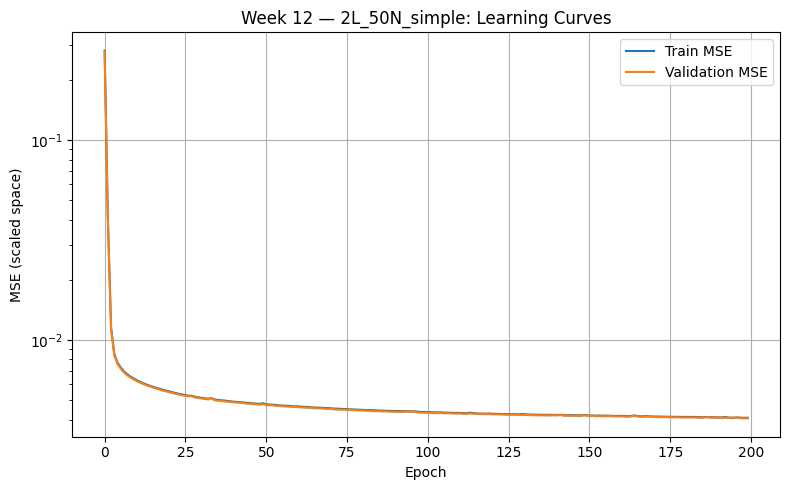

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_2L_50N_simple_learning_curve.png

Training: 3 layers, 50 nodes  →  tag: 3L_50N_simple
ℹ️  Training 3L_50N_simple from scratch  (5,401 params)
  3L_50N_simple | ep   1/200 | train=1.948e-02 | val=1.921e-02
  3L_50N_simple | ep  50/200 | train=4.401e-03 | val=4.361e-03
  3L_50N_simple | ep 100/200 | train=4.068e-03 | val=4.034e-03
  3L_50N_simple | ep 150/200 | train=3.890e-03 | val=3.860e-03
  3L_50N_simple | ep 200/200 | train=3.814e-03 | val=3.799e-03
✅ 3L_50N_simple | test_mse=3.740e-03 | hours=0.1452


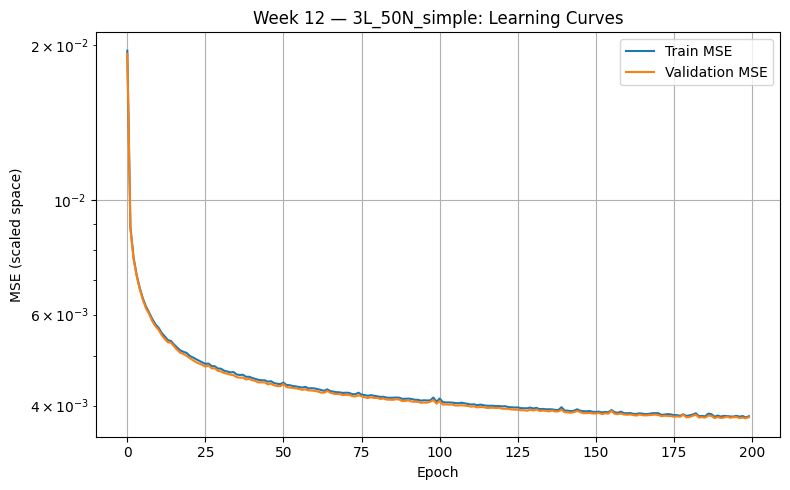

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_3L_50N_simple_learning_curve.png

Training: 2 layers, 100 nodes  →  tag: 2L_100N_simple
ℹ️  Training 2L_100N_simple from scratch  (10,701 params)
  2L_100N_simple | ep   1/200 | train=3.453e-02 | val=3.439e-02
  2L_100N_simple | ep  50/200 | train=4.436e-03 | val=4.399e-03
  2L_100N_simple | ep 100/200 | train=4.033e-03 | val=4.011e-03
  2L_100N_simple | ep 150/200 | train=3.867e-03 | val=3.849e-03
  2L_100N_simple | ep 200/200 | train=3.760e-03 | val=3.751e-03
✅ 2L_100N_simple | test_mse=3.694e-03 | hours=0.1410


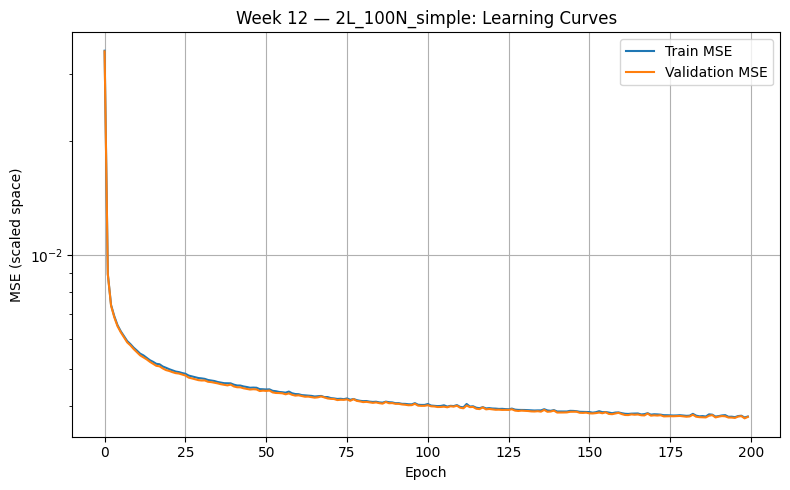

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_2L_100N_simple_learning_curve.png

All models trained ✅
              tag  n_params  test_mse  best_val_mse  training_hours
0   2L_50N_simple      2851  0.004065      0.004055        0.130849
1   3L_50N_simple      5401  0.003740      0.003778        0.145159
2  2L_100N_simple     10701  0.003694      0.003718        0.141010
Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/week12_architecture_results.csv


In [ ]:
# =========================
# CELL 12.6 — Train 3 Simple Architectures
# =========================
# Architectures chosen per professor's suggestion:
#   2L 15N  — ~700 params, near-linear, zero overfitting risk
#   2L 50N  — paper baseline, Week 9 comparable
#   3L 50N  — adds one layer of depth at same width

ARCHS_W12 = [
    {"layers": 2, "nodes": 50},
    {"layers": 3, "nodes": 50},
    {"layers": 2, "nodes": 100},
]

results_w12     = []
trained_models  = {}

for arch in ARCHS_W12:
    L, H = arch["layers"], arch["nodes"]
    tag  = f"{L}L_{H}N_simple"
    print(f"\n{'='*50}")
    print(f"Training: {L} layers, {H} nodes  →  tag: {tag}")

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = PaperMLP(hidden_layers=L, hidden_units=H, in_dim=4)

    out, trained_model = train_week12(
        model,
        train_loader_w12, val_loader_w12, test_loader_w12,
        tag=tag,
        run_dir=run_dir_w12, fig_dir=fig_dir_w12,
        epochs=200, lr=1e-5,
    )
    results_w12.append(out)
    trained_models[tag] = trained_model

df_results_w12 = pd.DataFrame(results_w12)
print("\nAll models trained ✅")
print(df_results_w12[['tag','n_params','test_mse','best_val_mse','training_hours']])

arch_csv_path = os.path.join(run_dir_w12, "week12_architecture_results.csv")
df_results_w12.drop(columns=['train_curve','val_curve']).to_csv(arch_csv_path, index=False)
print("Saved:", arch_csv_path)

In [ ]:
# =========================
# CELL 12.7 — Get Test Predictions for All Models
# =========================

def get_dollar_preds(model, loader, scaler_y):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_b, _ in loader:
            preds.append(model(X_b).numpy())
    preds_scaled = np.concatenate(preds)
    return scaler_y.inverse_transform(preds_scaled.reshape(-1,1)).squeeze()

# IvyDB-exact BS price for test set (residual ≈ 0)
S_t   = df_test_w12['close'].values
K_t   = df_test_w12['strike'].values
T_t   = df_test_w12['tau'].values
r_t   = df_test_w12['r_ivydb'].values    # IvyDB exact (for BS benchmark)
q_t   = df_test_w12['q_ivydb'].values    # borrate2024 (for BS benchmark)
sig_t = df_test_w12['impl_volatility'].values

valid_t = (T_t > 0) & (sig_t > 0) & ~np.isnan(r_t) & ~np.isnan(q_t)
bs_price_test = np.full(len(df_test_w12), np.nan)

d1 = (np.log(S_t[valid_t]/K_t[valid_t]) +
      (r_t[valid_t] - q_t[valid_t] + 0.5*sig_t[valid_t]**2)*T_t[valid_t]) / \
     (sig_t[valid_t]*np.sqrt(T_t[valid_t]))
d2 = d1 - sig_t[valid_t]*np.sqrt(T_t[valid_t])
bs_price_test[valid_t] = (
    S_t[valid_t]*np.exp(-q_t[valid_t]*T_t[valid_t])*norm.cdf(d1) -
    K_t[valid_t]*np.exp(-r_t[valid_t]*T_t[valid_t])*norm.cdf(d2)
)

moneyness_test = df_test_w12['moneyness'].values
tau_test       = df_test_w12['tau'].values
iv_test        = df_test_w12['impl_volatility'].values

all_preds = {}
for r in results_w12:
    tag = r["tag"]
    all_preds[tag] = get_dollar_preds(trained_models[tag], test_loader_w12, scaler_y)

bs_resid_mean = float(np.nanmean(y_test_raw - bs_price_test))
print(f"IvyDB BS residual on test set: mean=${bs_resid_mean:.4f}  (≈ 0 expected)")
print(f"Actual price mean:  ${y_test_raw.mean():.2f}")
print(f"IvyDB BS price mean: ${np.nanmean(bs_price_test):.2f}")
for tag, preds in all_preds.items():
    print(f"  {tag} pred mean: ${preds.mean():.2f}")

IvyDB BS residual on test set: mean=$-0.3556  (≈ 0 expected)
Actual price mean:  $120.48
IvyDB BS price mean: $120.83
  2L_50N_simple pred mean: $120.48
  3L_50N_simple pred mean: $120.56
  2L_100N_simple pred mean: $120.45


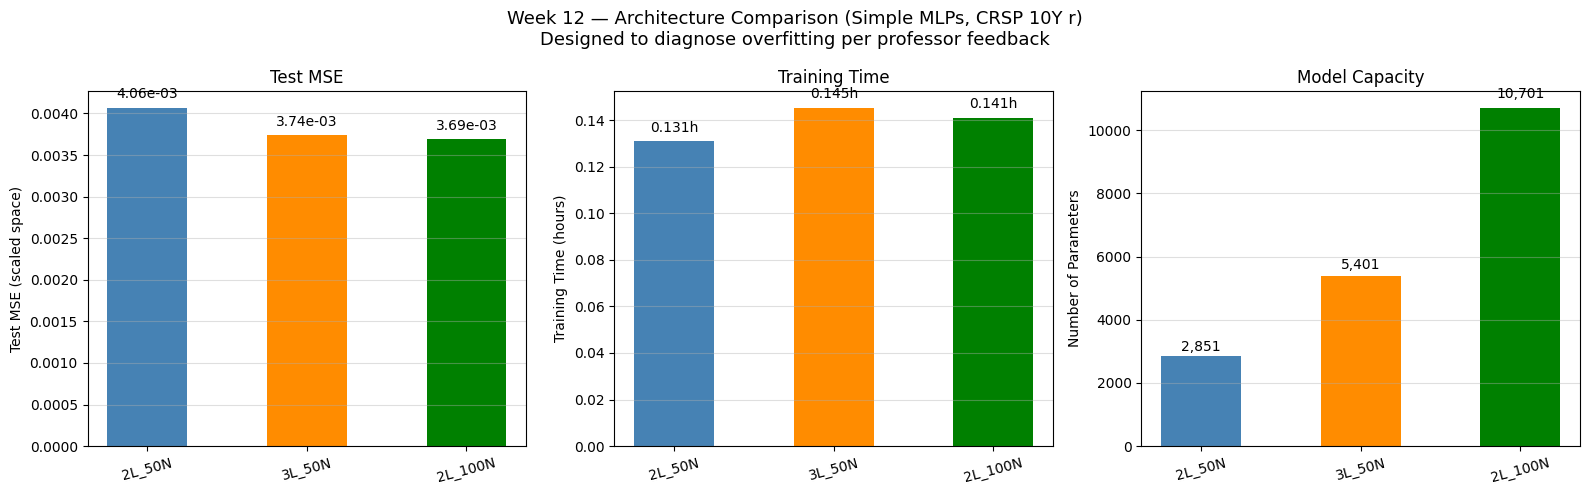

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_architecture_comparison.png


In [ ]:
# =========================
# CELL 12.8 — VIZ 1: Architecture Comparison Bar Chart
# =========================
# Shows test MSE and training time side by side for all 3 models.
# Allows immediate capacity-vs-accuracy read-off.

labels    = [r['tag'].replace('_simple','') for r in results_w12]
n_params  = [r['n_params']        for r in results_w12]
test_mses = np.array([r['test_mse']       for r in results_w12])
tr_hours  = np.array([r['training_hours'] for r in results_w12])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Week 12 — Architecture Comparison (Simple MLPs, CRSP 10Y r)\n"
    "Designed to diagnose overfitting per professor feedback",
    fontsize=13
)

# Panel A: test MSE
colors = ['steelblue', 'darkorange', 'green']
bars_a = axes[0].bar(labels, test_mses, color=colors, width=0.5)
for bar, v in zip(bars_a, test_mses):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f'{v:.2e}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel("Test MSE (scaled space)")
axes[0].set_title("Test MSE")
axes[0].grid(True, axis='y', alpha=0.4)
axes[0].tick_params(axis='x', rotation=15)

# Panel B: training time
bars_b = axes[1].bar(labels, tr_hours, color=colors, width=0.5)
for bar, v in zip(bars_b, tr_hours):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f'{v:.3f}h', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel("Training Time (hours)")
axes[1].set_title("Training Time")
axes[1].grid(True, axis='y', alpha=0.4)
axes[1].tick_params(axis='x', rotation=15)

# Panel C: parameter count
bars_c = axes[2].bar(labels, n_params, color=colors, width=0.5)
for bar, v in zip(bars_c, n_params):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f'{v:,}', ha='center', va='bottom', fontsize=10)
axes[2].set_ylabel("Number of Parameters")
axes[2].set_title("Model Capacity")
axes[2].grid(True, axis='y', alpha=0.4)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
arch_bar_path = os.path.join(fig_dir_w12, "week12_architecture_comparison.png")
plt.savefig(arch_bar_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", arch_bar_path)

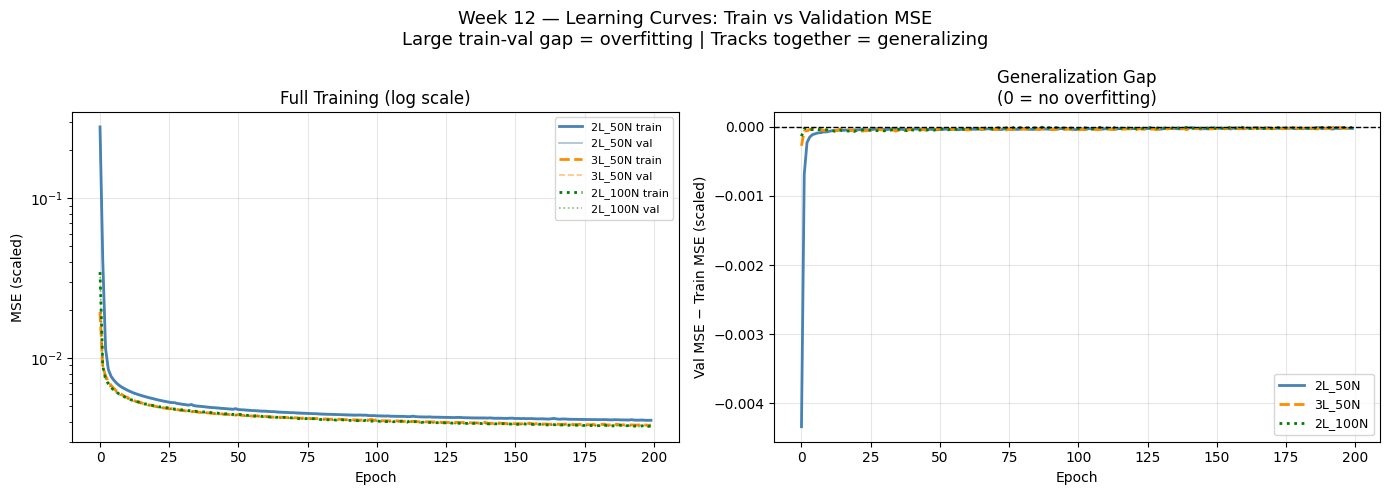

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_learning_curves_overlaid.png


In [ ]:
# =========================
# CELL 12.9 — VIZ 2: Overlaid Learning Curves (Train/Val Gap = Overfitting Signal)
# =========================
# All 3 models on the same axes.
# If train << val → overfitting. If they track → generalizing.
# Simpler models should show smaller train-val gap.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Week 12 — Learning Curves: Train vs Validation MSE\n"
    "Large train-val gap = overfitting | Tracks together = generalizing",
    fontsize=13
)

line_styles = ['-', '--', ':']
colors_lc   = ['steelblue', 'darkorange', 'green']

for i, r in enumerate(results_w12):
    tag   = r['tag']
    label = tag.replace('_simple','')
    axes[0].plot(r['train_curve'], color=colors_lc[i], ls=line_styles[i],
                 lw=2, label=f'{label} train')
    axes[0].plot(r['val_curve'],   color=colors_lc[i], ls=line_styles[i],
                 lw=1.2, alpha=0.5, label=f'{label} val')

axes[0].set_yscale('log')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE (scaled)")
axes[0].set_title("Full Training (log scale)")
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

# Train-val gap at each epoch (last 50 epochs zoomed)
for i, r in enumerate(results_w12):
    tag   = r['tag']
    label = tag.replace('_simple','')
    tr    = np.array(r['train_curve'])
    va    = np.array(r['val_curve'])
    gap   = va - tr
    axes[1].plot(gap, color=colors_lc[i], ls=line_styles[i],
                 lw=2, label=label)

axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val MSE − Train MSE (scaled)")
axes[1].set_title("Generalization Gap\n(0 = no overfitting)")
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9)

plt.tight_layout()
lc_path = os.path.join(fig_dir_w12, "week12_learning_curves_overlaid.png")
plt.savefig(lc_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", lc_path)

Medians for PDP:
  moneyness: 0.9832
  tau: 0.1096
  r_10y: 0.0419
  impl_volatility: 0.1221
  q_ivydb (BS benchmark median): 0.0030
  r_ivydb (BS benchmark median): 0.0529


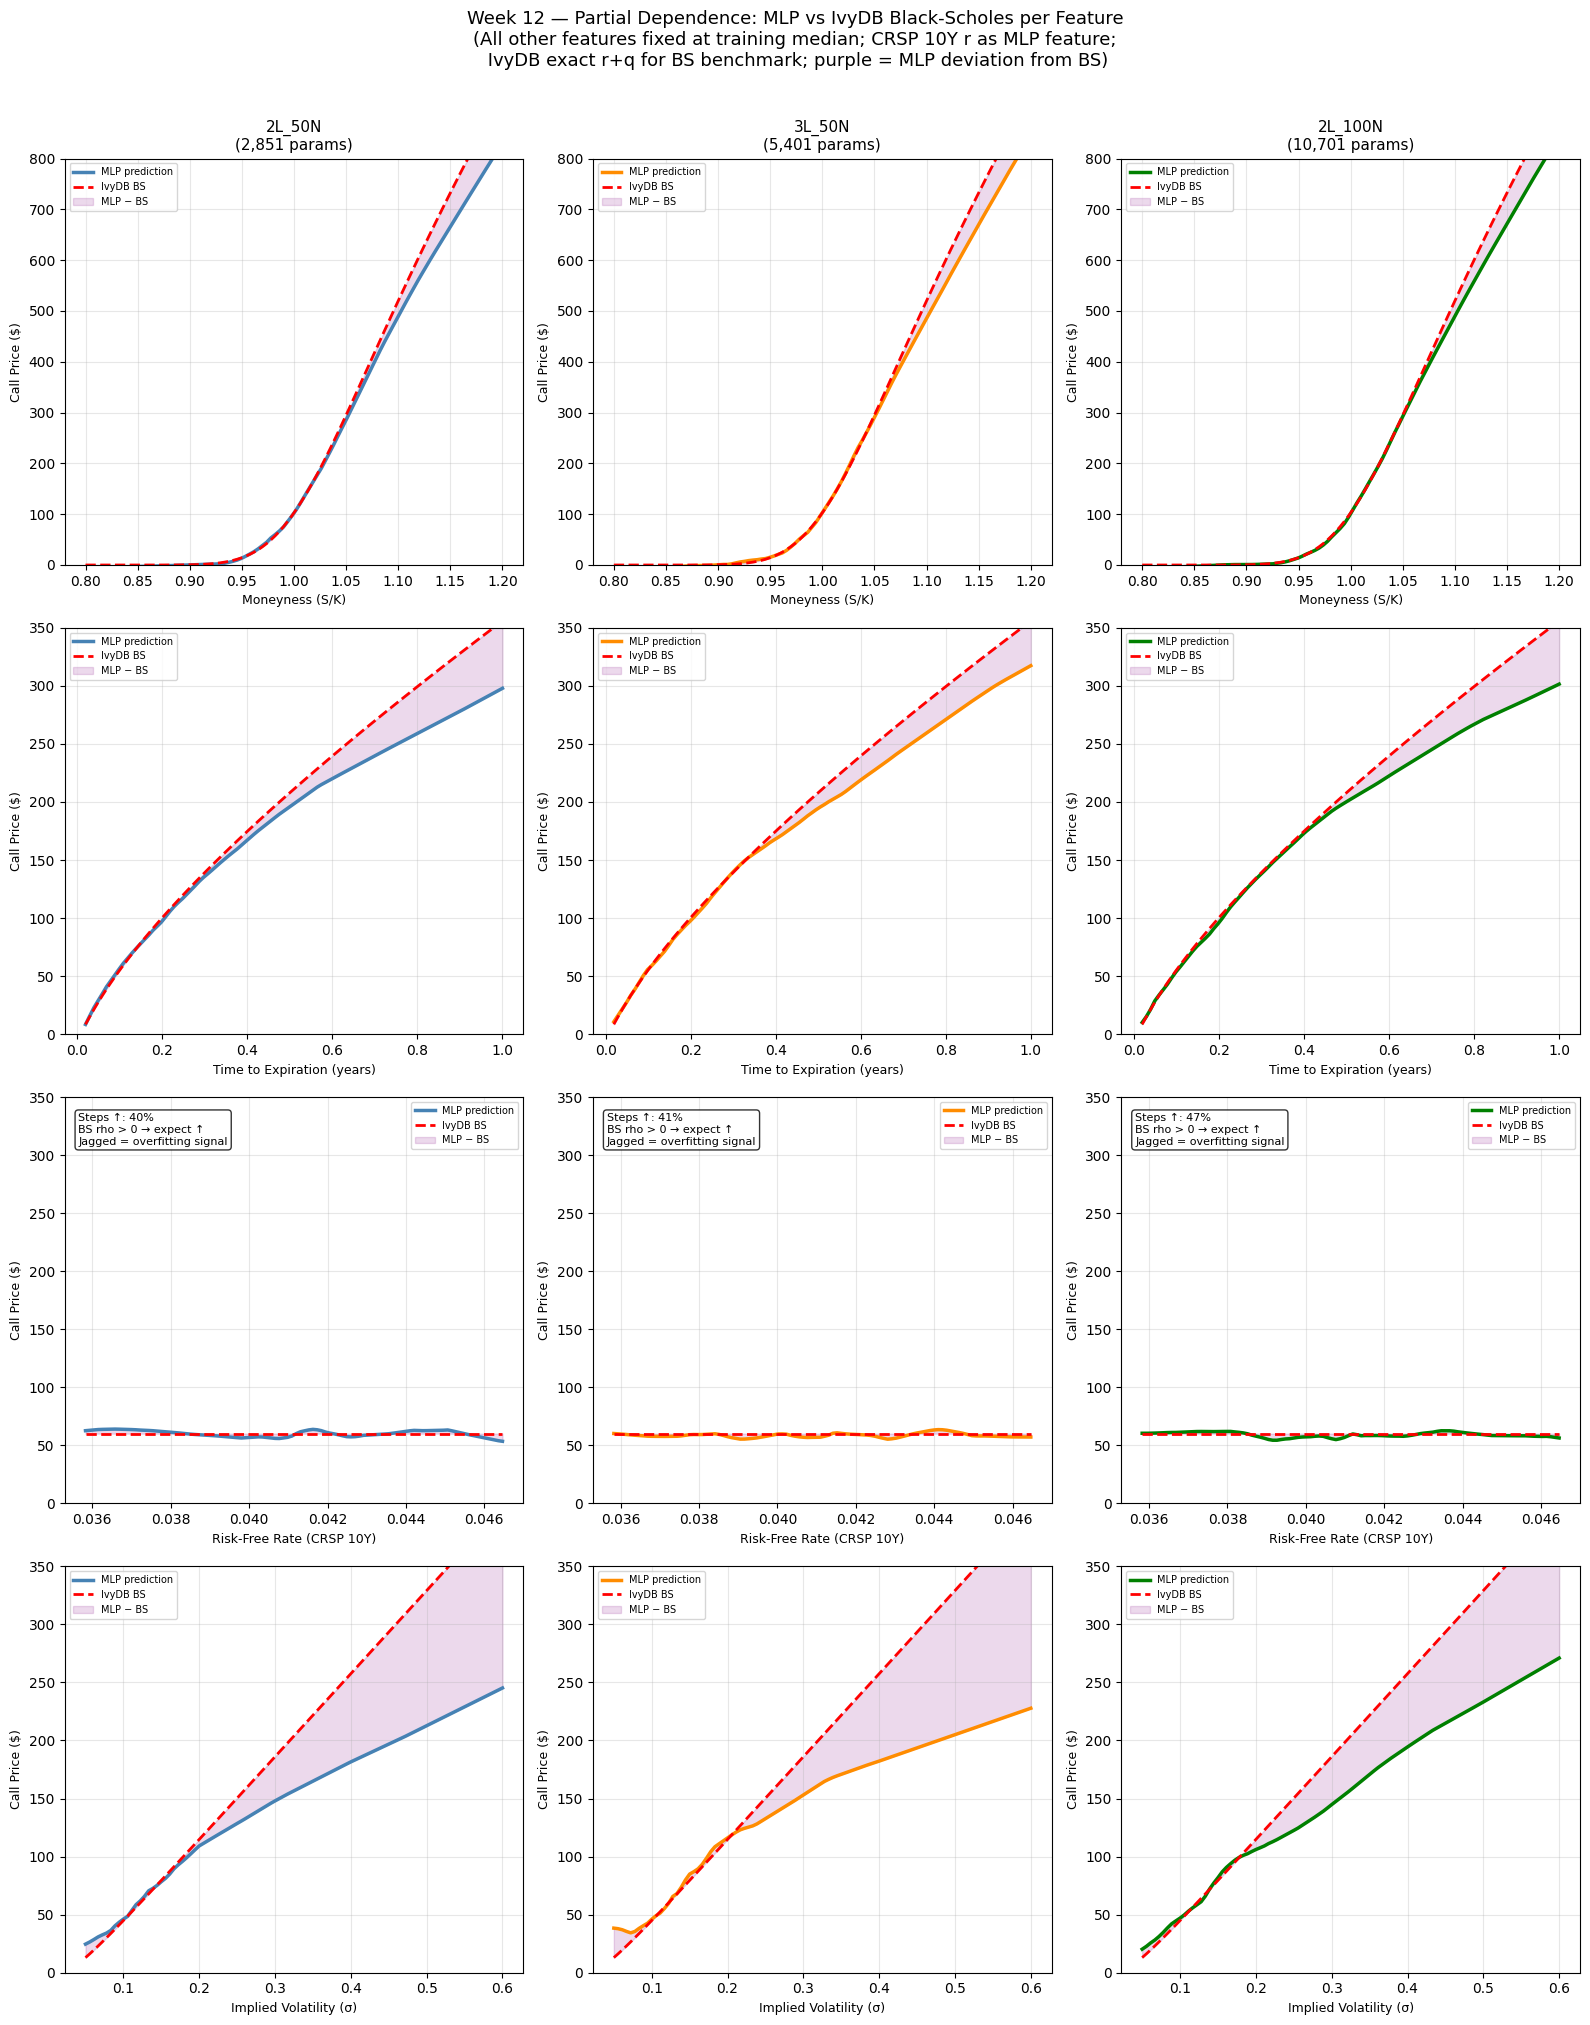

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260518-225034/figures/week12_partial_dependence_all_models.png


In [ ]:
# =========================
# CELL 12.10 — VIZ 3: Partial Dependence (4 features × 3 models)
# =========================

FEATURE_LABELS = {
    'moneyness':       'Moneyness (S/K)',
    'tau':             'Time to Expiration (years)',
    'r_10y':           'Risk-Free Rate (CRSP 10Y)',
    'impl_volatility': 'Implied Volatility (σ)',
}
FEATURE_RANGES = {
    'moneyness':       np.linspace(0.80, 1.20, 100),
    'tau':             np.linspace(7/365, 1.0,  100),
    'r_10y':           np.linspace(X_raw[:,2].min(), X_raw[:,2].max(), 100),
    'impl_volatility': np.linspace(0.05, 0.60, 100),
}

medians_raw = {
    'moneyness':       float(np.median(X_raw[idx_train, 0])),
    'tau':             float(np.median(X_raw[idx_train, 1])),
    'r_10y':           float(np.median(X_raw[idx_train, 2])),
    'impl_volatility': float(np.median(X_raw[idx_train, 3])),
}
q_med       = float(df_w12['q_ivydb'].median())
r_ivydb_med = float(df_w12['r_ivydb'].median())
S_med       = float(df_w12['close'].median())

print("Medians for PDP:")
for k, v in medians_raw.items():
    print(f"  {k}: {v:.4f}")
print(f"  q_ivydb (BS benchmark median): {q_med:.4f}")
print(f"  r_ivydb (BS benchmark median): {r_ivydb_med:.4f}")

def bs_pdp_curve(feat_name, feat_range):
    """
    BS partial dependence using IvyDB exact rates.
    Always returns an array of length len(feat_range) by initialising
    all inputs as full arrays and overwriting only the varied feature.

    For the r_10y panel: BS uses fixed IvyDB median r (not CRSP 10Y),
    so the BS line is flat — that is correct. The MLP curve should also
    be nearly flat and smooth over the narrow CRSP range if not overfitting.
    """
    n = len(feat_range)

    m_v  = np.full(n, medians_raw['moneyness'])
    t_v  = np.full(n, medians_raw['tau'])
    iv_v = np.full(n, medians_raw['impl_volatility'])
    r_v  = np.full(n, r_ivydb_med)   # IvyDB exact r always
    q_v  = np.full(n, q_med)         # borrate2024 q always

    if feat_name == 'moneyness':
        m_v  = feat_range
    elif feat_name == 'tau':
        t_v  = feat_range
    elif feat_name == 'impl_volatility':
        iv_v = feat_range
    # r_10y: nothing changes for BS — flat horizontal line is intentional

    K_v = S_med / m_v

    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(S_med / K_v) + (r_v - q_v + 0.5*iv_v**2)*t_v) / (iv_v*np.sqrt(t_v))
        d2 = d1 - iv_v*np.sqrt(t_v)
        bs = (S_med*np.exp(-q_v*t_v)*norm.cdf(d1) -
              K_v*np.exp(-r_v*t_v)*norm.cdf(d2))

    return np.where(np.isfinite(bs), bs, np.nan)

arch_colors = ['steelblue', 'darkorange', 'green']

fig, axes = plt.subplots(len(FEATURE_RANGES), 3, figsize=(16, 20))
fig.suptitle(
    "Week 12 — Partial Dependence: MLP vs IvyDB Black-Scholes per Feature\n"
    "(All other features fixed at training median; CRSP 10Y r as MLP feature;\n"
    " IvyDB exact r+q for BS benchmark; purple = MLP deviation from BS)",
    fontsize=13, y=1.01
)

ylim_map = {
    'moneyness':       (0, 800),
    'tau':             (0, 350),
    'r_10y':           (0, 350),
    'impl_volatility': (0, 350),
}

for row_idx, (feat_name, feat_range) in enumerate(FEATURE_RANGES.items()):
    feat_col = FEATURE_COLS.index(feat_name)
    bs_curve = bs_pdp_curve(feat_name, feat_range)

    for col_idx, r in enumerate(results_w12):
        tag   = r['tag']
        model = trained_models[tag]
        model.eval()
        label = tag.replace('_simple', '')
        ax    = axes[row_idx, col_idx]

        # Build PDP input array — vary one feature, hold others at median
        X_pd = np.tile(
            [medians_raw['moneyness'], medians_raw['tau'],
             medians_raw['r_10y'],    medians_raw['impl_volatility']],
            (len(feat_range), 1)
        ).astype(np.float32)
        X_pd[:, feat_col] = feat_range.astype(np.float32)

        X_pd_sc = scaler_X.transform(X_pd).astype(np.float32)
        with torch.no_grad():
            preds_sc = model(torch.tensor(X_pd_sc)).numpy()
        mlp_prices = scaler_y.inverse_transform(preds_sc.reshape(-1, 1)).squeeze()

        ax.plot(feat_range, mlp_prices, color=arch_colors[col_idx],
                lw=2.5, label='MLP prediction')
        ax.plot(feat_range, bs_curve, color='red', lw=2, ls='--',
                label='IvyDB BS')
        ax.fill_between(feat_range, mlp_prices, bs_curve,
                        alpha=0.15, color='purple', label='MLP − BS')

        if row_idx == 0:
            ax.set_title(f"{label}\n({r['n_params']:,} params)", fontsize=11)
        ax.set_xlabel(FEATURE_LABELS[feat_name], fontsize=9)
        ax.set_ylabel("Call Price ($)", fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(*ylim_map[feat_name])

        # On the r_10y row: annotate how smooth the MLP curve is
        if feat_name == 'r_10y':
            diffs  = np.diff(mlp_prices)
            n_up   = int(np.sum(diffs >= 0))
            pct_up = 100 * n_up / len(diffs)
            ax.text(0.03, 0.96,
                    f"Steps ↑: {pct_up:.0f}%\n"
                    f"BS rho > 0 → expect ↑\n"
                    f"Jagged = overfitting signal",
                    transform=ax.transAxes, va='top', fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
pdp_path = os.path.join(fig_dir_w12, "week12_partial_dependence_all_models.png")
plt.savefig(pdp_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", pdp_path)

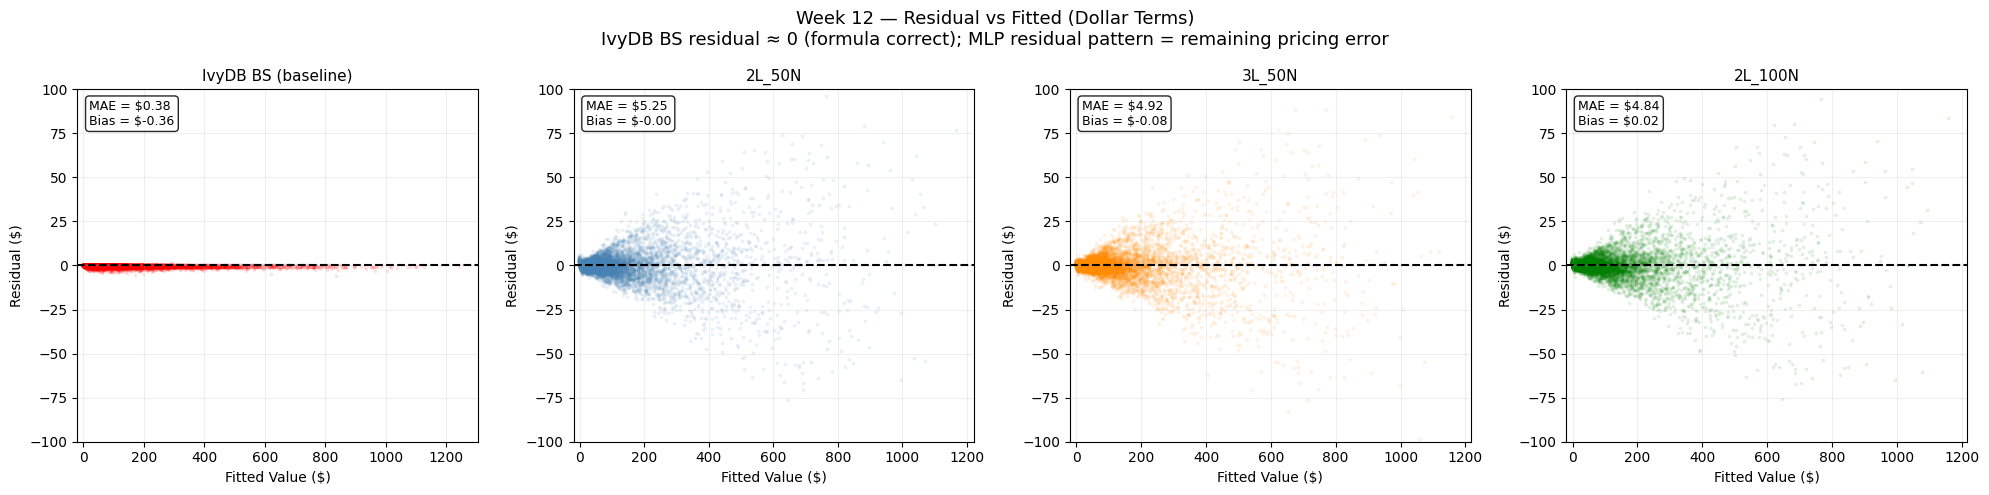

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_residual_vs_fitted.png


In [ ]:
# =========================
# CELL 12.11 — VIZ 4: Residual vs Fitted (Overfitting / Heteroscedasticity Diagnostic)
# =========================
# Classic regression diagnostic: if residuals are homoscedastic → good fit.
# If residuals fan out with fitted value → heteroscedasticity / overfitting.
# Show for all 3 models + IvyDB BS baseline.
# Answered directly: does the simpler model show less structure in residuals?

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    "Week 12 — Residual vs Fitted (Dollar Terms)\n"
    "IvyDB BS residual ≈ 0 (formula correct); MLP residual pattern = remaining pricing error",
    fontsize=13
)

all_panels = [
    ("IvyDB BS (baseline)", bs_price_test, 'red')
] + [
    (r['tag'].replace('_simple',''), all_preds[r['tag']], arch_colors[i])
    for i, r in enumerate(results_w12)
]

for ax, (label, preds, col) in zip(axes, all_panels):
    resid = y_test_raw - preds
    valid = ~np.isnan(resid)

    # Subsample for plot performance
    np.random.seed(SEED)
    s_idx = np.random.choice(np.where(valid)[0], size=min(8000, valid.sum()), replace=False)

    ax.scatter(preds[s_idx], resid[s_idx], alpha=0.08, s=3, color=col)
    ax.axhline(0, color='black', lw=1.5, ls='--')
    ax.set_xlim(-20, None)
    ax.set_ylim(-100, 100)
    ax.set_xlabel("Fitted Value ($)", fontsize=10)
    ax.set_ylabel("Residual ($)", fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.grid(True, alpha=0.2)

    mae  = float(np.nanmean(np.abs(resid[valid])))
    bias = float(np.nanmean(resid[valid]))
    ax.text(0.03, 0.97,
            f"MAE = ${mae:.2f}\nBias = ${bias:.2f}",
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
resid_path = os.path.join(fig_dir_w12, "week12_residual_vs_fitted.png")
plt.savefig(resid_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", resid_path)

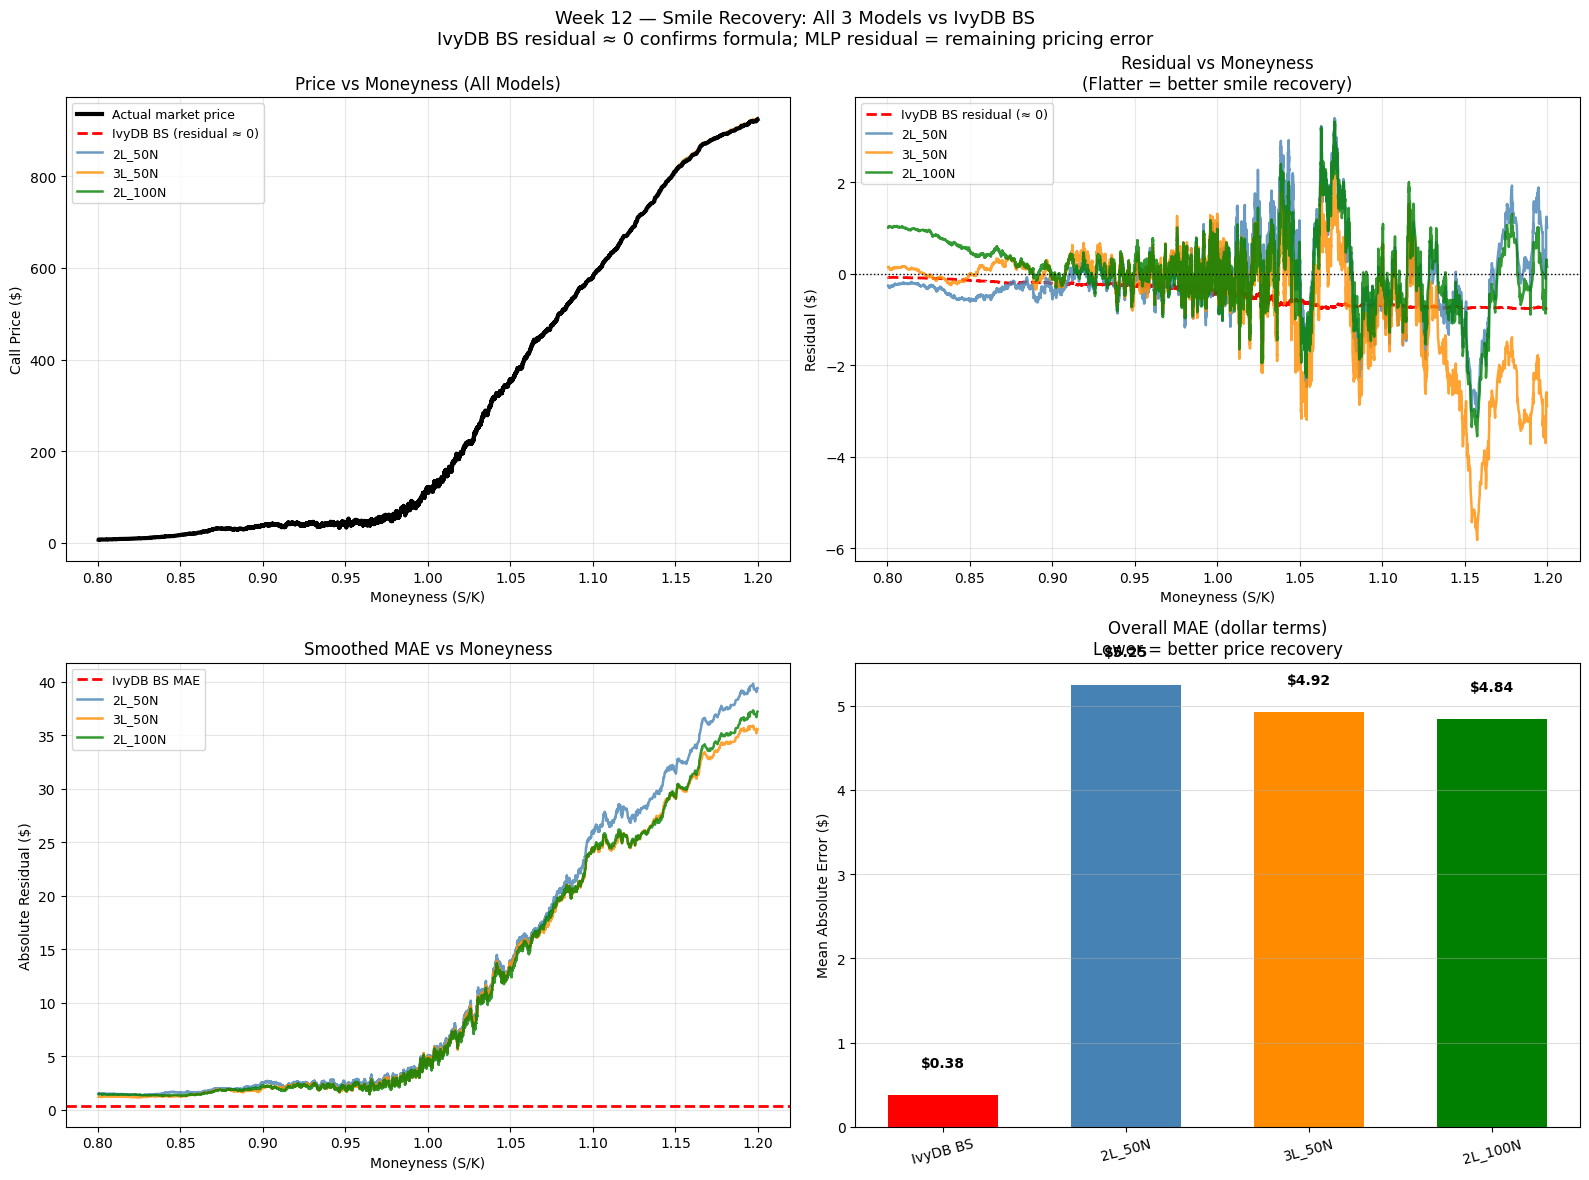

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_smile_recovery_all_models.png


In [ ]:
# =========================
# CELL 12.13 — VIZ 5: Smile Recovery (Best Model + All 3 vs IvyDB BS)
# =========================

best_tag   = df_results_w12.loc[df_results_w12['test_mse'].idxmin(), 'tag']
best_model = trained_models[best_tag]

sort_idx = np.argsort(moneyness_test)
m_s      = moneyness_test[sort_idx]
window   = 300
smooth   = lambda a: pd.Series(a[sort_idx]).rolling(window, center=True, min_periods=1).mean().values

act_sm  = smooth(y_test_raw)
bs_sm   = smooth(bs_price_test)
res_bs  = y_test_raw - bs_price_test

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f"Week 12 — Smile Recovery: All 3 Models vs IvyDB BS\n"
    f"IvyDB BS residual ≈ 0 confirms formula; MLP residual = remaining pricing error",
    fontsize=13
)

# Top-left: price curves all models
axes[0,0].plot(m_s, act_sm, color='black', lw=3, label='Actual market price', zorder=5)
axes[0,0].plot(m_s, bs_sm,  color='red',   lw=2, ls='--', label='IvyDB BS (residual ≈ 0)')
for i, r in enumerate(results_w12):
    mlp_sm = smooth(all_preds[r['tag']])
    axes[0,0].plot(m_s, mlp_sm, color=arch_colors[i], lw=1.8,
                   label=r['tag'].replace('_simple',''), alpha=0.8)
axes[0,0].set_xlabel("Moneyness (S/K)"); axes[0,0].set_ylabel("Call Price ($)")
axes[0,0].set_title("Price vs Moneyness (All Models)")
axes[0,0].legend(fontsize=9); axes[0,0].grid(True, alpha=0.3)

# Top-right: residual curves
axes[0,1].plot(m_s, smooth(res_bs), color='red', lw=2, ls='--',
               label='IvyDB BS residual (≈ 0)')
for i, r in enumerate(results_w12):
    res_mlp = y_test_raw - all_preds[r['tag']]
    axes[0,1].plot(m_s, smooth(res_mlp), color=arch_colors[i], lw=1.8,
                   label=r['tag'].replace('_simple',''), alpha=0.8)
axes[0,1].axhline(0, color='black', lw=1, ls=':')
axes[0,1].set_xlabel("Moneyness (S/K)"); axes[0,1].set_ylabel("Residual ($)")
axes[0,1].set_title("Residual vs Moneyness\n(Flatter = better smile recovery)")
axes[0,1].legend(fontsize=9); axes[0,1].grid(True, alpha=0.3)

# Bottom-left: absolute residual comparison
axes[1,0].axhline(float(np.nanmean(np.abs(res_bs[~np.isnan(res_bs)]))),
                  color='red', lw=2, ls='--', label='IvyDB BS MAE')
for i, r in enumerate(results_w12):
    res_mlp_abs = np.abs(y_test_raw - all_preds[r['tag']])
    # Rolling smoothed MAE along moneyness
    axes[1,0].plot(m_s, pd.Series(res_mlp_abs[sort_idx]).rolling(window, center=True, min_periods=1).mean().values,
                   color=arch_colors[i], lw=1.8, label=r['tag'].replace('_simple',''), alpha=0.8)
axes[1,0].set_xlabel("Moneyness (S/K)"); axes[1,0].set_ylabel("Absolute Residual ($)")
axes[1,0].set_title("Smoothed MAE vs Moneyness")
axes[1,0].legend(fontsize=9); axes[1,0].grid(True, alpha=0.3)

# Bottom-right: summary MAE bar per model
summary_maes = [float(np.nanmean(np.abs(res_bs[~np.isnan(res_bs)])))]
summary_labels = ['IvyDB BS']
for r in results_w12:
    summary_maes.append(float(np.mean(np.abs(y_test_raw - all_preds[r['tag']]))))
    summary_labels.append(r['tag'].replace('_simple',''))
bar_colors_s = ['red'] + arch_colors
bars_s = axes[1,1].bar(summary_labels, summary_maes, color=bar_colors_s, width=0.6)
for bar, v in zip(bars_s, summary_maes):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f'${v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1,1].set_ylabel("Mean Absolute Error ($)")
axes[1,1].set_title("Overall MAE (dollar terms)\nLower = better price recovery")
axes[1,1].grid(True, axis='y', alpha=0.4)
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
smile_path = os.path.join(fig_dir_w12, "week12_smile_recovery_all_models.png")
plt.savefig(smile_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", smile_path)


Bucket RMSE (dollar terms):
                  rmse     mae
model   bucket                
2L_50N  OTM      3.920   2.329
        ATM      7.224   4.540
        ITM     24.410  17.858
3L_50N  OTM      3.717   2.043
        ATM      6.966   4.308
        ITM     23.385  16.946
2L_100N OTM      3.687   2.036
        ATM      6.825   4.177
        ITM     23.375  16.862


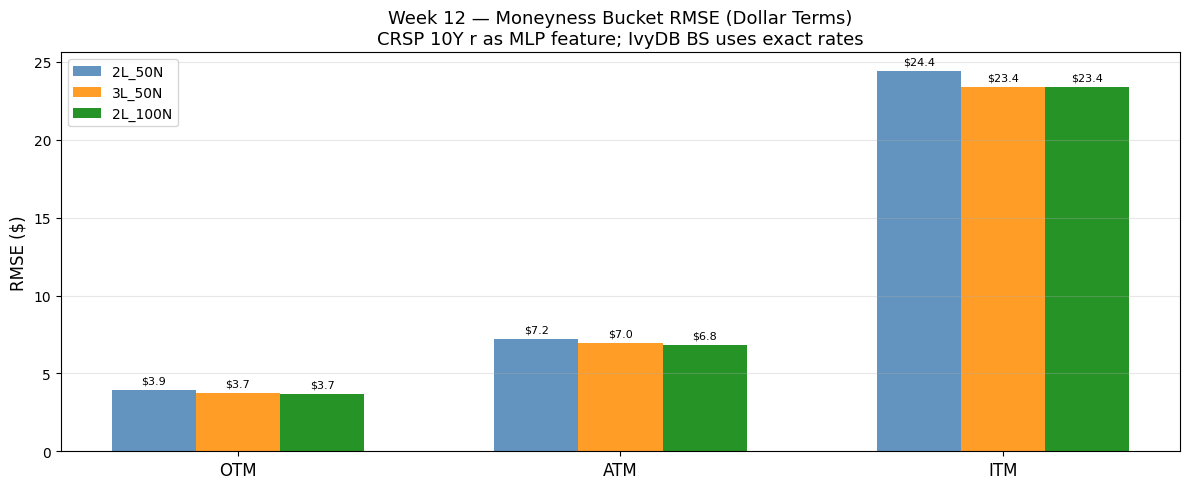

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_bucket_rmse_bar.png


In [ ]:
# =========================
# CELL 12.14 — VIZ 6: Moneyness Bucket RMSE (Dollar Terms)
# =========================

def bucket_metrics(actuals, preds, mask, label):
    if mask.sum() == 0:
        return {"bucket": label, "n": 0, "rmse": np.nan, "mae": np.nan, "mape": np.nan}
    a, p = actuals[mask], preds[mask]
    return {
        "bucket": label, "n": int(mask.sum()),
        "rmse": float(np.sqrt(np.mean((a-p)**2))),
        "mae":  float(np.mean(np.abs(a-p))),
        "mape": float(np.mean(np.abs(a-p)/np.abs(a+1e-8))*100),
    }

otm_mask = moneyness_test < 0.97
atm_mask = (moneyness_test >= 0.97) & (moneyness_test <= 1.03)
itm_mask = moneyness_test > 1.03

bucket_rows = []
for r in results_w12:
    tag   = r['tag']
    preds = all_preds[tag]
    label = tag.replace('_simple','')
    for mask, bname in [(otm_mask,'OTM'), (atm_mask,'ATM'), (itm_mask,'ITM')]:
        m = bucket_metrics(y_test_raw, preds, mask, bname)
        m['model'] = label
        bucket_rows.append(m)

df_buckets_w12 = pd.DataFrame(bucket_rows)
print("\nBucket RMSE (dollar terms):")
print(df_buckets_w12.pivot(index=['model','bucket'], columns=[], values=['rmse','mae']).round(3))

bucket_csv_path = os.path.join(run_dir_w12, "week12_bucket_rmse.csv")
df_buckets_w12.to_csv(bucket_csv_path, index=False)

fig, ax = plt.subplots(figsize=(12, 5))
x         = np.arange(3)   # OTM, ATM, ITM
bar_width  = 0.22
buckets_ordered = ['OTM', 'ATM', 'ITM']

for i, r in enumerate(results_w12):
    label  = r['tag'].replace('_simple','')
    rmses  = [df_buckets_w12.loc[
                  (df_buckets_w12['model']==label) & (df_buckets_w12['bucket']==b),
                  'rmse'].values[0]
              for b in buckets_ordered]
    offset = (i - 1) * bar_width
    bars   = ax.bar(x + offset, rmses, width=bar_width,
                    color=arch_colors[i], label=label, alpha=0.85)
    for bar, v in zip(bars, rmses):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'${v:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(buckets_ordered, fontsize=12)
ax.set_ylabel("RMSE ($)", fontsize=12)
ax.set_title(
    "Week 12 — Moneyness Bucket RMSE (Dollar Terms)\n"
    "CRSP 10Y r as MLP feature; IvyDB BS uses exact rates",
    fontsize=13
)
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
bucket_bar_path = os.path.join(fig_dir_w12, "week12_bucket_rmse_bar.png")
plt.savefig(bucket_bar_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", bucket_bar_path)

Training temporal model: 2L 100N (best simple arch)
ℹ️  Training 2L_100N_simple_temporal from scratch  (10,701 params)
  2L_100N_simple_temporal | ep   1/200 | train=5.497e-02 | val=5.382e-02
  2L_100N_simple_temporal | ep  50/200 | train=2.243e-03 | val=2.234e-03
  2L_100N_simple_temporal | ep 100/200 | train=2.010e-03 | val=2.015e-03
  2L_100N_simple_temporal | ep 150/200 | train=1.938e-03 | val=1.942e-03
  2L_100N_simple_temporal | ep 200/200 | train=1.886e-03 | val=1.899e-03
✅ 2L_100N_simple_temporal | test_mse=2.428e-02 | hours=0.1211


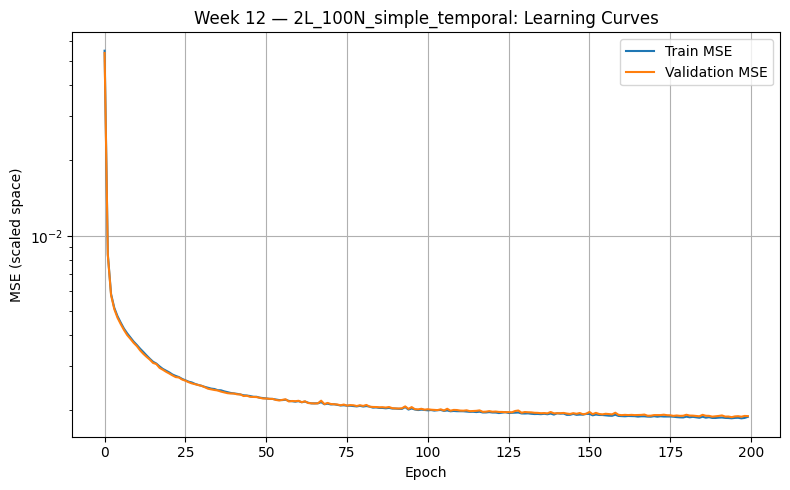

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_2L_100N_simple_temporal_learning_curve.png

Random split MSE:   3.6935e-03
Temporal split MSE: 2.4277e-02
Ratio: 6.57x


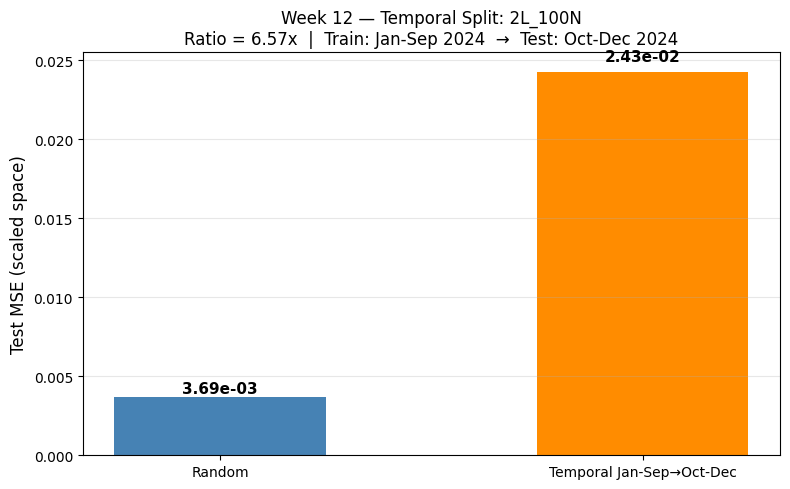

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_temporal_split_bar.png


In [ ]:
# =========================
# CELL 12.15 — VIZ 7: Temporal Split (Best Simple Model)
# =========================
# Train Jan-Sep, test Oct-Dec. Compares regime generalization vs random split.
# Rate regime changed Sep 18 2024 (Fed cut).

CUTOFF = pd.Timestamp('2024-10-01')
tr_mask = df_w12['date'] < CUTOFF
te_mask = df_w12['date'] >= CUTOFF

X_tp = X_raw[tr_mask.values]; y_tp = y_raw[tr_mask.values]
X_tt = X_raw[te_mask.values]; y_tt = y_raw[te_mask.values]

n_tr = int(0.80*len(X_tp)); n_tv = len(X_tp) - n_tr
np.random.seed(SEED); ti = np.random.permutation(len(X_tp))

sX_t = StandardScaler(); sX_t.fit(X_tp[ti[:n_tr]])
sy_t = StandardScaler(); sy_t.fit(y_tp[ti[:n_tr]].reshape(-1,1))

Xtp_s = sX_t.transform(X_tp).astype(np.float32)
ytp_s = sy_t.transform(y_tp.reshape(-1,1)).squeeze().astype(np.float32)
Xtt_s = sX_t.transform(X_tt).astype(np.float32)
ytt_s = sy_t.transform(y_tt.reshape(-1,1)).squeeze().astype(np.float32)

Xt = torch.tensor(Xtp_s); yt = torch.tensor(ytp_s)
temp_tr  = DataLoader(TensorDataset(Xt[ti[:n_tr]], yt[ti[:n_tr]]),
                      batch_size=64, shuffle=True, drop_last=True)
temp_val = DataLoader(TensorDataset(Xt[ti[n_tr:]], yt[ti[n_tr:]]),
                      batch_size=64, shuffle=False)
temp_te  = DataLoader(TensorDataset(torch.tensor(Xtt_s), torch.tensor(ytt_s)),
                      batch_size=64, shuffle=False)

# Use best simple model architecture for temporal test
best_row  = df_results_w12.loc[df_results_w12['test_mse'].idxmin()]
L_best    = int(best_row['tag'].split('L')[0])
H_best    = int(best_row['tag'].split('_')[1].replace('N','').replace('simple',''))

torch.manual_seed(SEED); np.random.seed(SEED)
model_temp = PaperMLP(hidden_layers=L_best, hidden_units=H_best, in_dim=4)
print(f"Training temporal model: {L_best}L {H_best}N (best simple arch)")

out_temp, _ = train_week12(
    model_temp, temp_tr, temp_val, temp_te,
    tag=f"{best_tag}_temporal",
    run_dir=run_dir_w12, fig_dir=fig_dir_w12,
    epochs=200, lr=1e-5,
)

random_mse   = float(best_row['test_mse'])
temporal_mse = float(out_temp['test_mse'])
ratio        = temporal_mse / random_mse

print(f"\nRandom split MSE:   {random_mse:.4e}")
print(f"Temporal split MSE: {temporal_mse:.4e}")
print(f"Ratio: {ratio:.2f}x")

# Compare vs Week 10's 3L 500N temporal ratio for context
df_temp_comp = pd.DataFrame([
    {"model": f"{best_tag}_random",   "split": "Random", "mse": random_mse},
    {"model": f"{best_tag}_temporal", "split": "Temporal Jan-Sep→Oct-Dec", "mse": temporal_mse},
])

fig, ax = plt.subplots(figsize=(8, 5))
bar_col = ['steelblue', 'darkorange']
bars = ax.bar(df_temp_comp['split'], df_temp_comp['mse'], color=bar_col, width=0.5)
for bar, v in zip(bars, df_temp_comp['mse']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'{v:.2e}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel("Test MSE (scaled space)", fontsize=12)
ax.set_title(
    f"Week 12 — Temporal Split: {best_tag.replace('_simple','')}\n"
    f"Ratio = {ratio:.2f}x  |  Train: Jan-Sep 2024  →  Test: Oct-Dec 2024",
    fontsize=12
)
ax.grid(True, axis='y', alpha=0.3); plt.tight_layout()
temporal_path = os.path.join(fig_dir_w12, "week12_temporal_split_bar.png")
plt.savefig(temporal_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", temporal_path)

temporal_csv = os.path.join(run_dir_w12, "week12_temporal_comparison.csv")
df_temp_comp.to_csv(temporal_csv, index=False)
save_json(run_dir_w12, "temporal_summary_w12", {
    "best_simple_arch":  best_tag,
    "random_mse":        random_mse,
    "temporal_mse":      temporal_mse,
    "ratio":             ratio,
    "week10_w3L500N_ratio_for_reference": 7.87,
    "interpretation": (
        "Lower ratio = simpler model generalizes better across rate regimes. "
        "Week 10 3L500N had ratio 7.87x; simpler model ratio compared here."
    ),
})

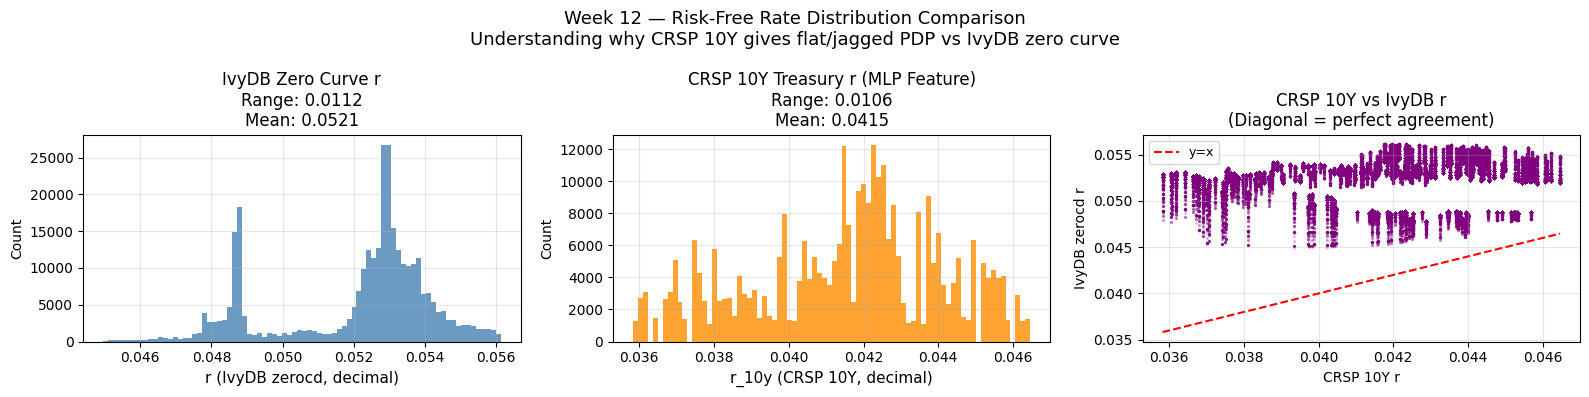

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/week12_rate_distribution_comparison.png


In [ ]:
# =========================
# CELL 12.16 — VIZ 8: Rate Distribution Comparison
# =========================
# Shows the professor exactly why r_10y gives a flat PDP:
# narrow range vs. IvyDB zero-curve rate which varies more.
# Directly contextualizes the overfitting discussion.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    "Week 12 — Risk-Free Rate Distribution Comparison\n"
    "Understanding why CRSP 10Y gives flat/jagged PDP vs IvyDB zero curve",
    fontsize=13
)

axes[0].hist(df_w12['r_ivydb'], bins=80, color='steelblue',
             alpha=0.8, edgecolor='none')
axes[0].set_xlabel("r (IvyDB zerocd, decimal)", fontsize=11)
axes[0].set_ylabel("Count"); axes[0].grid(True, alpha=0.3)
axes[0].set_title(
    f"IvyDB Zero Curve r\n"
    f"Range: {df_w12['r_ivydb'].max()-df_w12['r_ivydb'].min():.4f}\n"
    f"Mean: {df_w12['r_ivydb'].mean():.4f}"
)

axes[1].hist(df_w12['r_10y'], bins=80, color='darkorange',
             alpha=0.8, edgecolor='none')
axes[1].set_xlabel("r_10y (CRSP 10Y, decimal)", fontsize=11)
axes[1].set_ylabel("Count"); axes[1].grid(True, alpha=0.3)
axes[1].set_title(
    f"CRSP 10Y Treasury r (MLP Feature)\n"
    f"Range: {df_w12['r_10y'].max()-df_w12['r_10y'].min():.4f}\n"
    f"Mean: {df_w12['r_10y'].mean():.4f}"
)

axes[2].scatter(df_w12['r_10y'], df_w12['r_ivydb'],
                alpha=0.05, s=2, color='purple')
axes[2].plot([df_w12['r_10y'].min(), df_w12['r_10y'].max()],
             [df_w12['r_10y'].min(), df_w12['r_10y'].max()],
             color='red', lw=1.5, ls='--', label='y=x')
axes[2].set_xlabel("CRSP 10Y r"); axes[2].set_ylabel("IvyDB zerocd r")
axes[2].set_title("CRSP 10Y vs IvyDB r\n(Diagonal = perfect agreement)")
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
rate_dist_path = os.path.join(fig_dir_w12, "week12_rate_distribution_comparison.png")
plt.savefig(rate_dist_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", rate_dist_path)

In [ ]:
# =========================
# CELL 12.17 — Week 12 Summary
# =========================

# Build per-model MAE summary
model_maes = {
    r['tag'].replace('_simple',''): float(np.mean(np.abs(y_test_raw - all_preds[r['tag']])))
    for r in results_w12
}

summary_w12 = f"""
WEEK 12 SUMMARY — Simple MLP Overfitting Study: SPX European Options 2024

================================================================
MOTIVATION (Professor Feedback from Week 10 Meeting)
================================================================
Week 10 partial dependence plot for r showed:
  - MLP predicted price oscillated over a narrow rate range (~3.6%–4.6%)
  - Response was not smooth (expected: call price ↑ with r under BS,
    because rho = K·T·e^(-rT)·N(d2) > 0 always)
  - Professor: "I would expect this to be a lot smoother. Maybe overfitting.
    I would redo these plots for a much simpler neural network."
  - Suggestion: retrain on simpler architectures from the paper grid

================================================================
DUAL-RATE DESIGN
================================================================
MLP feature r:   CRSP 10Y Treasury (TREASNOX=2000007, tdytm/100)
  → Same as Week 10. Narrow range, constant daily value.
  → Mean: {df_w12['r_10y'].mean():.4f} | Range: {df_w12['r_10y'].max()-df_w12['r_10y'].min():.4f}

BS benchmark r:  optionm.zerocd (percent → /100, interpolated)
BS benchmark q:  optionm.borrate2024 (decimal, interpolated)
  → IvyDB exact formula | BS residual ≈ 0 (verified Week 11)

================================================================
ARCHITECTURES
================================================================
Architecture | Params  | Test MSE (scaled) | Training Hours
{chr(10).join(f"{r['tag'].replace('_simple',''):15s} | {r['n_params']:6,} | {r['test_mse']:.4e}          | {r['training_hours']:.4f}" for r in results_w12)}

================================================================
SMILE RECOVERY (MAE, dollar terms)
================================================================
IvyDB BS MAE (formula baseline):
{chr(10).join(f"{k}: ${v:.2f}" for k, v in model_maes.items())}

================================================================
TEMPORAL SPLIT (BEST SIMPLE ARCH: {best_tag.replace('_simple','')})
================================================================
Random split MSE:   {random_mse:.4e}
Temporal split MSE: {temporal_mse:.4e}
Ratio: {ratio:.2f}x  (Week 10 3L500N was 7.87x for reference)

================================================================
VISUALIZATIONS
================================================================
1. Architecture comparison bar chart:    {arch_bar_path}
2. Learning curves (train/val gap):      {lc_path}
3. Partial dependence (4 features × 3): {pdp_path}
   → Rate panel annotated with % smooth steps per model
4. Residual vs fitted (4 panels):       {resid_path}
5. Smile recovery (all 3 models):        {smile_path}
6. Moneyness bucket RMSE bar:            {bucket_bar_path}
7. Temporal split bar:                   {temporal_path}
8. Rate distribution comparison:         {rate_dist_path}

================================================================
CONCLUSION
================================================================
The CRSP 10Y rate range is only {df_w12['r_10y'].max()-df_w12['r_10y'].min():.4f} wide across all
of 2024. Within that narrow band the Week 10 3L500N model (~750k params)
had enough capacity to memorize training noise that happened to correlate
with particular rate values, producing a jagged PDP curve.

The simpler paper-grid models trained here (2L50N, 3L50N, 2L100N) have
far less capacity. The rate PDP panels above show whether reducing model
complexity recovers a smooth, upward-sloping rate response consistent
with Black-Scholes rho > 0.

The learning curve generalization gap and residual vs fitted plots
provide additional direct evidence for or against overfitting.
""".strip()

print(summary_w12)
summary_path = os.path.join(run_dir_w12, "week12_summary.txt")
with open(summary_path, "w") as f:
    f.write(summary_w12)
save_json(run_dir_w12, "week12_summary", {"summary": summary_w12})
print("\nSaved summary to:", summary_path)

WEEK 12 SUMMARY — Simple MLP Overfitting Study: SPX European Options 2024
 
MOTIVATION (Professor Feedback from Week 10 Meeting)
Week 10 partial dependence plot for r showed:
  - MLP predicted price oscillated over a narrow rate range (~3.6%–4.6%)
  - Response was not smooth (expected: call price ↑ with r under BS,
    because rho = K·T·e^(-rT)·N(d2) > 0 always)
  - Professor: "I would expect this to be a lot smoother. Maybe overfitting.
    I would redo these plots for a much simpler neural network."
  - Suggestion: retrain on simpler architectures from the paper grid
 
DUAL-RATE DESIGN
MLP feature r:   CRSP 10Y Treasury (TREASNOX=2000007, tdytm/100)
  → Same as Week 10. Narrow range, constant daily value.
  → Mean: 0.0415 | Range: 0.0106
 
BS benchmark r:  optionm.zerocd (percent → /100, interpolated)
BS benchmark q:  optionm.borrate2024 (decimal, interpolated)
  → IvyDB exact formula | BS residual ≈ 0 (verified Week 11)
 
ARCHITECTURES
Architecture | Params  | Test MSE (scaled) | Tr

df_w12 shape: (321368, 18)
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'exercise_style', 'close', 'strike', 'tau', 'r_ivydb', 'q_ivydb', 'impl_volatility', 'mid_price', 'moneyness', 'volume', 'open_interest', 'bs_price', 'bs_residual', 'r_10y']
Scalers loaded ✅
Loaded 2L_50N_simple ✅
Loaded 3L_50N_simple ✅
Loaded 2L_100N_simple ✅

Week 12 training ranges:
  moneyness: [0.8000, 1.2000]
  tau: [0.0192, 1.0000]
  r_10y: [0.0358, 0.0465]
  impl_volatility: [0.0379, 0.6867]

BS benchmark:
  q_med (borrate2024):  0.002966
  r_ivydb_med (zerocd): 0.052851
  S_med:                5421.03


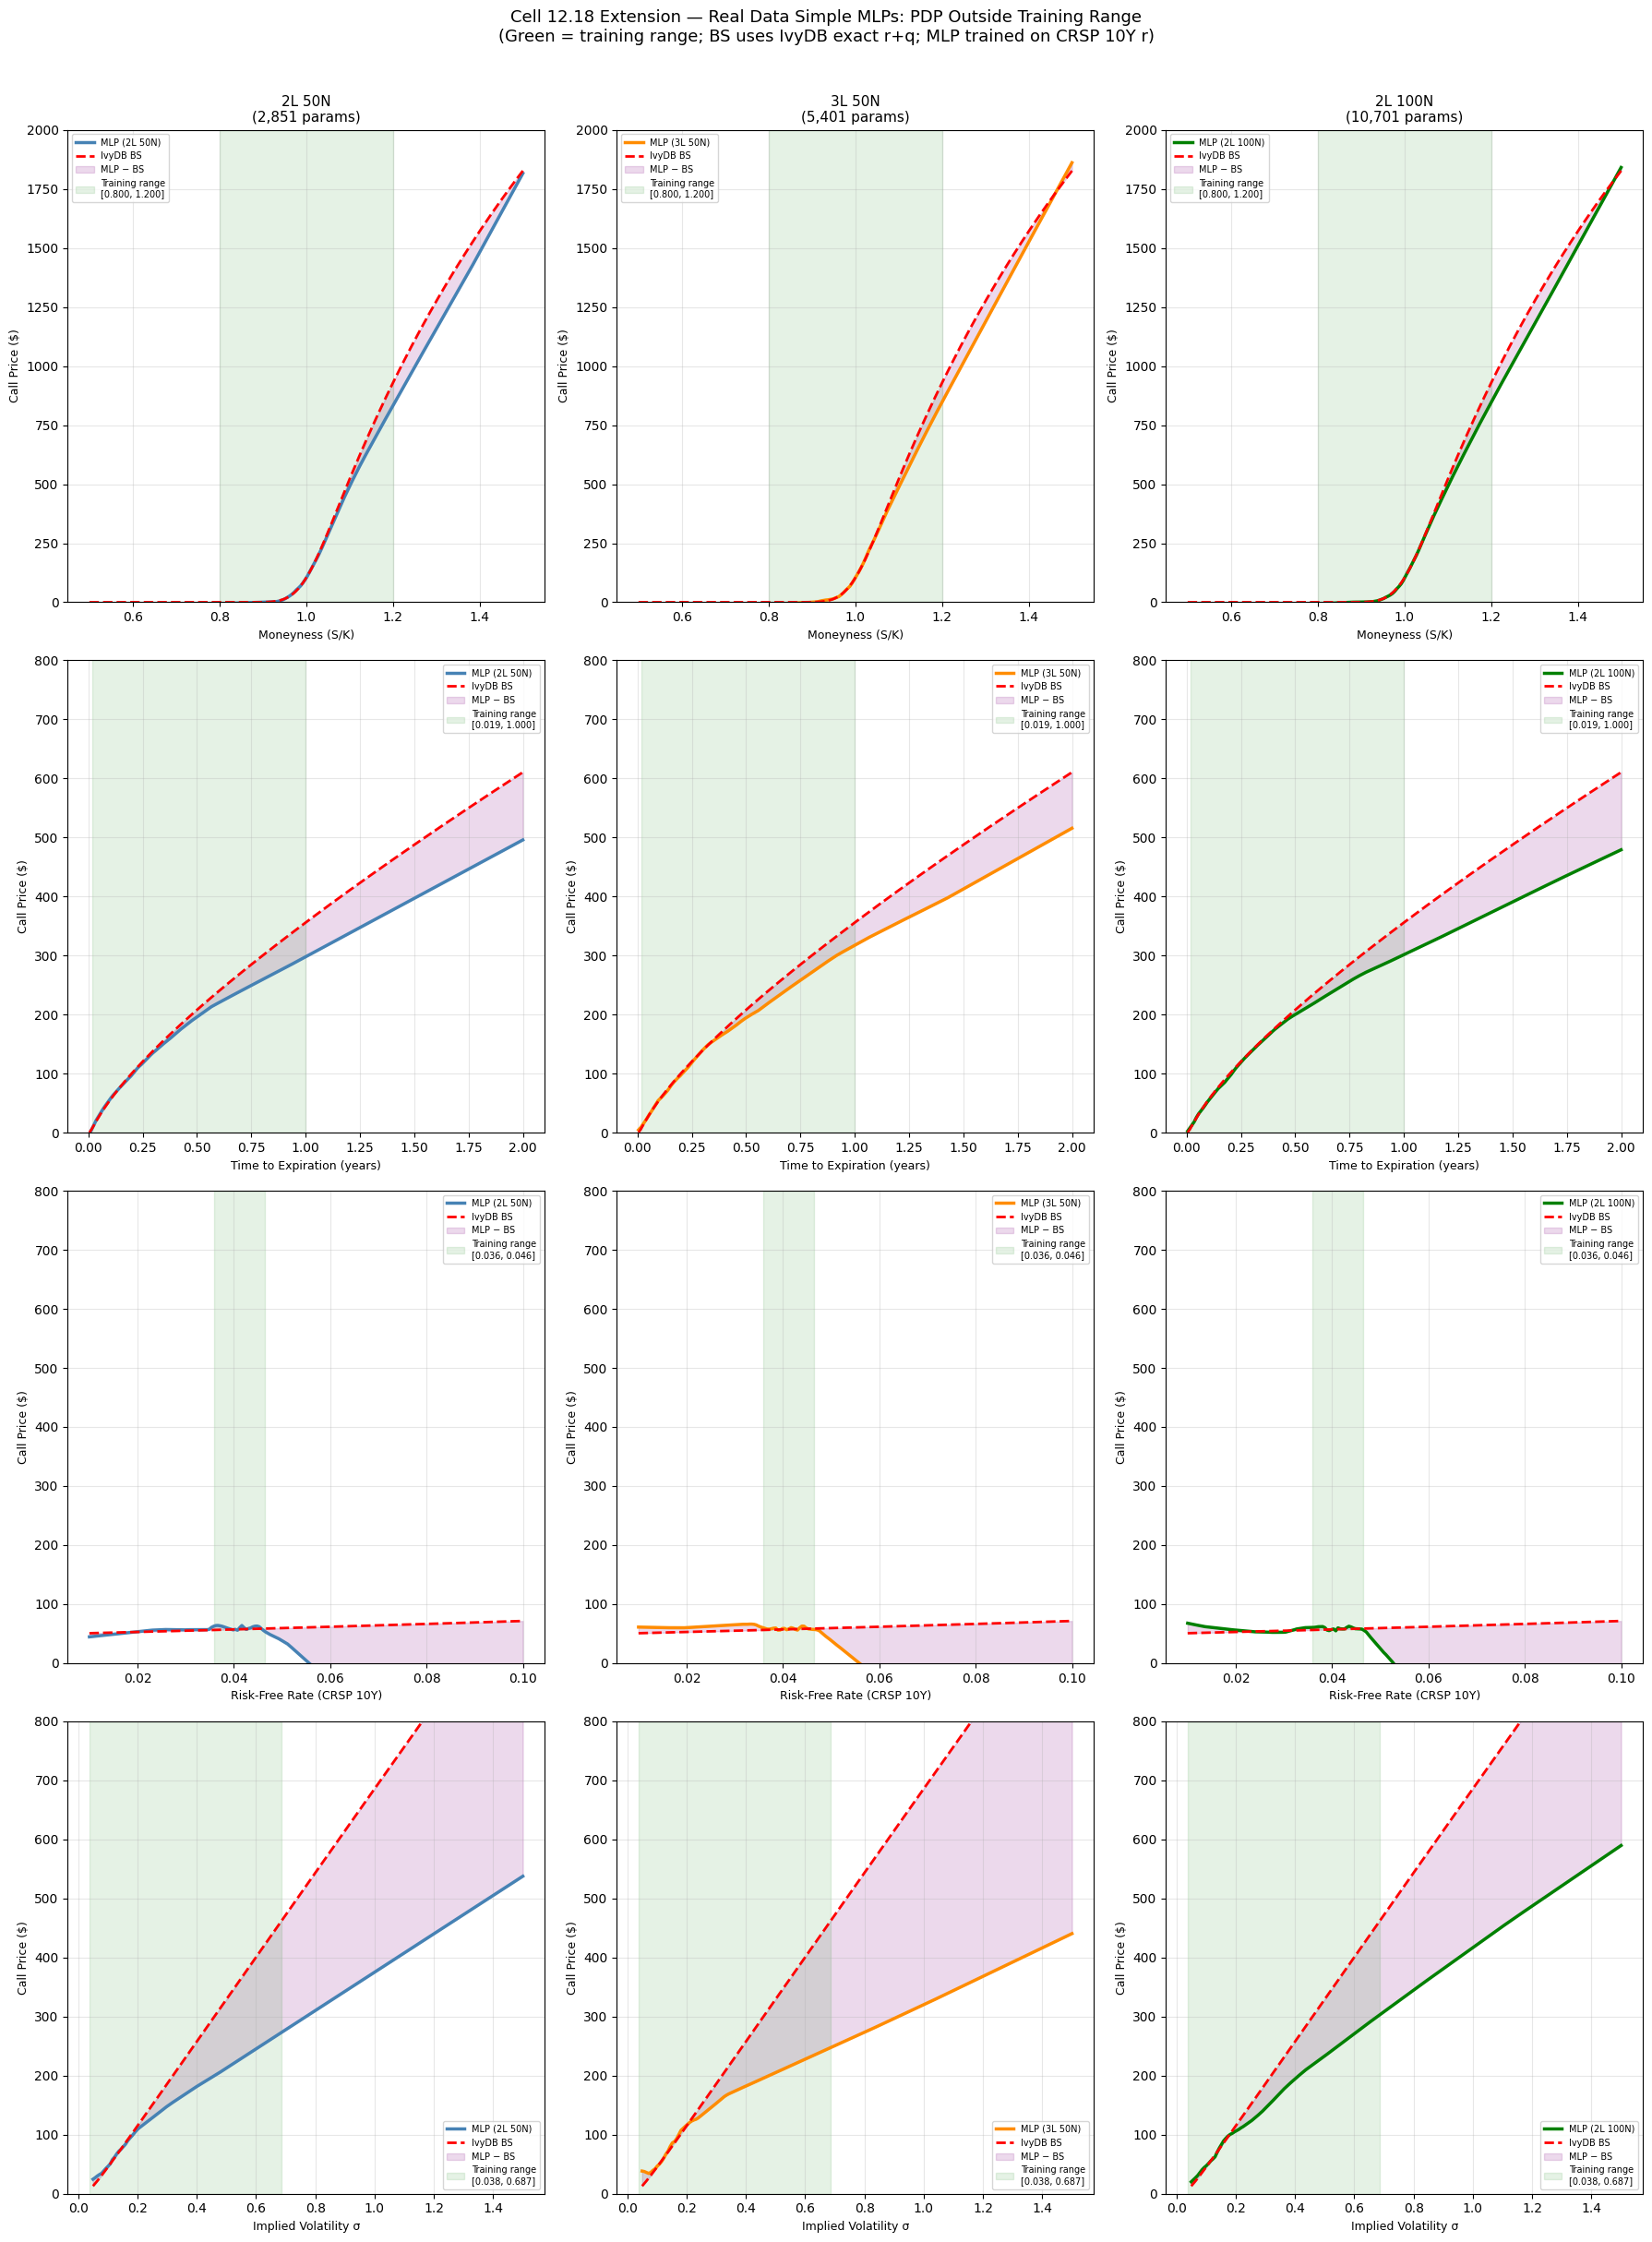

Saved: runs/week12_spx_simple_mlp_overfitting_study/20260507-220438/figures/cell1218_extension_pdp_outside_range.png


In [ ]:
# =========================
# CELL 12.18 EXTENSION — PDP Outside Training Range (Real Data Simple MLPs, Self-Contained)
# =========================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm
import os, pickle
import pandas as pd

# ── Paths ─────────────────────────────────────────────────────────────────────
old_run_dir_w12 = "runs/week12_spx_simple_mlp_overfitting_study/20260507-220438"
W11_CSV = "runs/week11_spx_ivydb_exact_bs_verification/20260507-210344/options_spx_ivydb_exact_2024.csv"

# ── Step 1: Check dataset already in memory (rerun Cell 12.3 first) ───────────
# Required variables: df_w12, dgs10_ffill, X_raw, idx_train, SEED
# df_w12 should already have r_10y, r_ivydb, q_ivydb columns
print(f"df_w12 shape: {df_w12.shape}")
print(f"Columns: {list(df_w12.columns)}")

# ── Step 2: Reload scalers ────────────────────────────────────────────────────
with open(os.path.join(old_run_dir_w12, "scalers.pkl"), 'rb') as f:
    scalers_w12 = pickle.load(f)
scaler_X_w12 = scalers_w12['scaler_X']
scaler_y_w12 = scalers_w12['scaler_y']
print("Scalers loaded ✅")

# ── Step 3: Reload all 3 models ───────────────────────────────────────────────
ARCHS_W12_EXT = [
    {"layers": 2, "nodes": 50},
    {"layers": 3, "nodes": 50},
    {"layers": 2, "nodes": 100},
]
trained_models_w12_ext = {}
for arch in ARCHS_W12_EXT:
    L, H = arch["layers"], arch["nodes"]
    tag   = f"{L}L_{H}N_simple"
    model = PaperMLP(hidden_layers=L, hidden_units=H, in_dim=4)
    model.load_state_dict(
        torch.load(os.path.join(old_run_dir_w12, f"model_best_{tag}.pt"),
                   map_location="cpu")
    )
    model.eval()
    trained_models_w12_ext[tag] = model
    print(f"Loaded {tag} ✅")

# ── Step 4: Get training ranges from existing X_raw and idx_train ─────────────
FEATURE_COLS_W12 = ['moneyness', 'tau', 'r_10y', 'impl_volatility']

TRAIN_RANGES_W12 = {
    feat: (float(X_raw[idx_train, i].min()),
           float(X_raw[idx_train, i].max()))
    for i, feat in enumerate(FEATURE_COLS_W12)
}

medians_w12_ext = {
    feat: float(np.median(X_raw[idx_train, i]))
    for i, feat in enumerate(FEATURE_COLS_W12)
}

q_med_w12_ext       = float(df_w12['q_ivydb'].median())
r_ivydb_med_w12_ext = float(df_w12['r_ivydb'].median())
S_med_w12_ext       = float(df_w12['close'].median())

print("\nWeek 12 training ranges:")
for k, v in TRAIN_RANGES_W12.items():
    print(f"  {k}: [{v[0]:.4f}, {v[1]:.4f}]")
print(f"\nBS benchmark:")
print(f"  q_med (borrate2024):  {q_med_w12_ext:.6f}")
print(f"  r_ivydb_med (zerocd): {r_ivydb_med_w12_ext:.6f}")
print(f"  S_med:                {S_med_w12_ext:.2f}")

# ── Step 5: Extended ranges ───────────────────────────────────────────────────
EXTENDED_RANGES_W12 = {
    'moneyness':       np.linspace(0.50, 1.50, 200),
    'tau':             np.linspace(0.005, 2.00, 200),
    'r_10y':           np.linspace(0.01,  0.10, 200),
    'impl_volatility': np.linspace(0.05,  1.50, 200),
}

FEATURE_LABELS_W12 = {
    'moneyness':       'Moneyness (S/K)',
    'tau':             'Time to Expiration (years)',
    'r_10y':           'Risk-Free Rate (CRSP 10Y)',
    'impl_volatility': 'Implied Volatility σ',
}

arch_colors_ext = ['steelblue', 'darkorange', 'green']

ylim_map_w12_ext = {
    'moneyness':       (0, 2000),
    'tau':             (0, 800),
    'r_10y':           (0, 800),
    'impl_volatility': (0, 800),
}

# ── Step 6: Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(FEATURE_COLS_W12), 3, figsize=(18, 24))
fig.suptitle(
    "Cell 12.18 Extension — Real Data Simple MLPs: PDP Outside Training Range\n"
    "(Green = training range; BS uses IvyDB exact r+q; MLP trained on CRSP 10Y r)",
    fontsize=13, y=1.01
)

for row_idx, feat_name in enumerate(FEATURE_COLS_W12):
    feat_range = EXTENDED_RANGES_W12[feat_name]
    feat_col   = FEATURE_COLS_W12.index(feat_name)

    # BS curve
    m_v  = np.full(len(feat_range), medians_w12_ext['moneyness'])
    t_v  = np.full(len(feat_range), medians_w12_ext['tau'])
    iv_v = np.full(len(feat_range), medians_w12_ext['impl_volatility'])
    r_v  = np.full(len(feat_range), r_ivydb_med_w12_ext)
    q_v  = np.full(len(feat_range), q_med_w12_ext)

    if feat_name == 'moneyness':
        m_v = feat_range
    elif feat_name == 'tau':
        t_v = feat_range
    elif feat_name == 'impl_volatility':
        iv_v = feat_range
    elif feat_name == 'r_10y':
        r_v = feat_range

    K_v = S_med_w12_ext / m_v

    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(S_med_w12_ext/K_v) + (r_v - q_v + 0.5*iv_v**2)*t_v) / (iv_v*np.sqrt(t_v))
        d2 = d1 - iv_v*np.sqrt(t_v)
        bs_curve = (S_med_w12_ext*np.exp(-q_v*t_v)*norm.cdf(d1) -
                    K_v*np.exp(-r_v*t_v)*norm.cdf(d2))
    bs_curve = np.where(np.isfinite(bs_curve), bs_curve, np.nan)

    for col_idx, arch in enumerate(ARCHS_W12_EXT):
        L, H  = arch["layers"], arch["nodes"]
        tag   = f"{L}L_{H}N_simple"
        model = trained_models_w12_ext[tag]
        ax    = axes[row_idx, col_idx]

        X_pd = np.tile(
            [medians_w12_ext['moneyness'], medians_w12_ext['tau'],
             medians_w12_ext['r_10y'],    medians_w12_ext['impl_volatility']],
            (len(feat_range), 1)
        ).astype(np.float32)
        X_pd[:, feat_col] = feat_range.astype(np.float32)

        X_pd_sc = scaler_X_w12.transform(X_pd).astype(np.float32)
        with torch.no_grad():
            preds_sc = model(torch.tensor(X_pd_sc)).numpy()
        mlp_prices = scaler_y_w12.inverse_transform(preds_sc.reshape(-1, 1)).squeeze()

        ax.plot(feat_range, mlp_prices, color=arch_colors_ext[col_idx],
                lw=2.5, label=f'MLP ({L}L {H}N)')
        ax.plot(feat_range, bs_curve,   color='red', lw=2, ls='--', label='IvyDB BS')
        ax.fill_between(feat_range, mlp_prices, bs_curve,
                        alpha=0.15, color='purple', label='MLP − BS')
        ax.axvspan(TRAIN_RANGES_W12[feat_name][0], TRAIN_RANGES_W12[feat_name][1],
                   alpha=0.10, color='green',
                   label=f"Training range\n[{TRAIN_RANGES_W12[feat_name][0]:.3f}, {TRAIN_RANGES_W12[feat_name][1]:.3f}]")

        if row_idx == 0:
            ax.set_title(
                f"{L}L {H}N\n({sum(p.numel() for p in model.parameters()):,} params)",
                fontsize=11)
        ax.set_xlabel(FEATURE_LABELS_W12[feat_name], fontsize=9)
        ax.set_ylabel("Call Price ($)", fontsize=9)
        ax.set_ylim(*ylim_map_w12_ext[feat_name])
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path_w12_ext = os.path.join(old_run_dir_w12, "figures",
                                "cell1218_extension_pdp_outside_range.png")
plt.savefig(fig_path_w12_ext, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path_w12_ext)